## Importación de paquetes
___
___

In [170]:
import os
import numpy as np                  # Importación de la biblioteca numpy para el manejo de arreglos
import pandas as pd                 # Importación de la biblioteca pandas para el manejo de datos contenidos en una base de datos
import matplotlib.pyplot as plt     # Importación de la biblioteca para realizar la visualización de resultados mediante elementos gráficos
import seaborn as sns               # Importación de la biblioteca para realizar la visualización de resultados mediante elementos gráficos
import scipy.stats as sts
np.set_printoptions(
    suppress=True,
    linewidth=100,
    precision=2
)
plt.rcParams['figure.dpi'] = 120

## Funciones Auxiliares
___
___

### Categorización datos crudos

---

Esta función **transforma datos crudos hacia una representación numérica estructurada**, sustituyendo aquellos valores no convertibles por valores faltantes (NaN).

🎯 **Objetivo principal**: Preparar datos originalmente heterogéneos (como cadenas de texto o mezclas de tipos) para su clasificación inicial.

📊 **Resultado**: Conformación de una estructura matricial homogénea en formato `numpy.ndarray`, mediante la cual se pueden aplicar técnicas avanzadas para el reconocimiento y tipificación de variables utilizando algoritmos vectorizados y con robustez en cuanto al contenido presente en la base de datos.

---

🔵 **Parámetros de entrada**

- `datos`: estructura iterable bidimensional (`numpy.ndarray`), donde cada elemento interno representa un registro y puede contener valores numéricos, cadenas de texto u otros tipos de datos.

---

🟠 **Proceso de la función**

- Recorre secuencialmente cada registro contenido en la estructura de entrada.
- Intenta convertir cada elemento individual al tipo de dato flotante (`float`).
- Cuando la conversión es exitosa, almacena el valor numérico correspondiente.
- Si un elemento no puede transformarse, asigna el valor faltante NaN (`numpy.nan`), preservando la estructura y dimensionalidad original del conjunto de datos.
- Consolida los valores procesados en una estructura matricial homogénea y la convierte formalmente en un arreglo bidimensional de `NumPy` (`numpy.ndarray`).

---

🟢 **Salida de la función**

- **Efecto en consola:** impresión de las primeras cinco columnas del arreglo numérico generado (`datos_numericos[:, :5]`), permitiendo realizar una inspección rápida del resultado de la conversión.
- **Retorno:** un objeto de tipo `numpy.ndarray` que contiene los datos convertidos a formato numérico, donde todos los valores que no pudieron interpretarse como números han sido reemplazados por `NaN`.

---
---

In [3]:
def categorizacion_datos_crudos(datos):
    datos_numericos = []
    for i in datos:
        temporal = []
        for j in i:
            try:
                x = float(j)
            except:
                x = np.nan
            finally:
                temporal.append(x)
        datos_numericos.append(temporal)
    datos_numericos = np.array(datos_numericos)
    print(datos_numericos[:,:5])
    return datos_numericos

### Obtención de Porcentaje de Valores Nulos en un Conjunto de Datos

---

Esta función **evalúa la viabilidad de conversión de las variables del conjunto de datos**, cuantificando la proporción de registros que logran o fallan en transformarse hacia una representación numérica.

🎯 **Objetivo principal**: Servir como un clasificador estructural para *identificar* y *separar* automáticamente aquellas variables con potencial de ser tratadas como numéricas de aquellas de naturaleza puramente no numérica (categórica o texto libre).

📊 **Resultado**: Organización de los índices de conversión en estructuras de tipo `pandas.DataFrame`. La función proporciona tanto la matriz de tipificación original como una versión ordenada jerárquicamente según el porcentaje de valores que no pudieron ser convertidos (*NaN*), optimizando la toma de decisiones para la etapa de pipeline o transformación de tipos.

---

🔵 **Parámetros de entrada**

- `datos`: estructura iterable que contiene las variables del conjunto de datos, donde cada elemento representa una columna cuyos valores pueden incluir datos faltantes (`NaN`).

- `etiquetas`: lista o estructura iterable que contiene los nombres asociados a cada una de las variables analizadas.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Recorre cada variable contenida en la estructura de datos.
- Calcula el número de valores faltantes utilizando la función `pd.isna()`.
- Determina el porcentaje de datos nulos respecto al total de observaciones de cada variable.
- Almacena los porcentajes calculados en una lista auxiliar.
- Construye un `DataFrame` que relaciona el nombre de cada variable con su porcentaje de datos faltantes.
- Genera una segunda versión del `DataFrame`, ordenando las variables de forma descendente según su porcentaje de valores nulos, lo que facilita identificar aquellas con mayor nivel de incompletitud.

---

🟢 **Salida de la función**

La función genera dos salidas:

- **Efecto en consola:** imprime las primeras cinco filas del `DataFrame` original, permitiendo una inspección rápida de los porcentajes calculados para las primeras variables.

- **Retorno:** una tupla compuesta por dos objetos `pandas.DataFrame`:
  - El primer `DataFrame` contiene las variables en su orden original junto con el porcentaje de datos faltantes.
  - El segundo `DataFrame` presenta la misma información ordenada de forma descendente según el porcentaje de valores nulos, facilitando la priorización de acciones durante el proceso de limpieza de datos.

---
---

In [4]:
def proporcion_datos_nulos_numpy(datos, etiquetas):
    porcentaje_datos_nulos = []
    for columna in datos:
        porcentaje_datos_nulos.append(
            pd.isna(columna).sum() / len(columna) * 100
        )
    categoria_pandas = pd.DataFrame({
        'Categoria': etiquetas,
        'Porcentaje': porcentaje_datos_nulos
    })
    categoria_pandas_ordenado = categoria_pandas.sort_values(
        by='Porcentaje',
        ascending=False
    )
    print(categoria_pandas.head())
    return (categoria_pandas, categoria_pandas_ordenado)

---
---

Esta función tiene como finalidad **evaluar la completitud de las variables contenidas en un conjunto de datos**, cuantificando el porcentaje de valores faltantes (`NaN`) presente en cada una de ellas. Su objetivo principal es proporcionar una medida de la calidad de la información disponible para cada variable, facilitando la identificación de aquellas que requieren procesos de imputación, transformación o exclusión antes de realizar análisis estadísticos o desarrollar modelos de aprendizaje automático.

La función genera un resumen tabular utilizando estructuras de `pandas`, tanto en el orden original de las variables como ordenado de acuerdo con su nivel de incompletitud.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `datos`: objeto `pandas.DataFrame` que contiene el conjunto de datos sobre el cual se evaluará la completitud de las variables.

- `etiquetas`: lista o estructura iterable que contiene los nombres de las variables cuya proporción de valores faltantes será calculada.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Selecciona del `DataFrame` únicamente las variables especificadas mediante `etiquetas`.
- Identifica los valores faltantes de cada variable utilizando el método `isna()`.
- Calcula la proporción de valores nulos mediante el promedio de los valores booleanos obtenidos, aprovechando las operaciones vectorizadas de `pandas`.
- Convierte las proporciones calculadas a porcentajes.
- Construye un `DataFrame` que relaciona el nombre de cada variable con su porcentaje de datos faltantes.
- Restablece el índice del `DataFrame` para obtener una numeración consecutiva.
- Genera una segunda versión del resumen, ordenando las variables de forma descendente según su porcentaje de valores nulos.

---

🟢 **Salida de la función**

La función genera dos salidas:

- **Efecto en consola:** imprime el `DataFrame` que resume el porcentaje de datos faltantes correspondiente a cada una de las variables analizadas.

- **Retorno:** una tupla compuesta por dos objetos `pandas.DataFrame`:
  - El primer `DataFrame` presenta el porcentaje de valores faltantes respetando el orden original de las variables.
  - El segundo `DataFrame` contiene la misma información ordenada de forma descendente según el porcentaje de datos faltantes, permitiendo identificar rápidamente las variables con menor nivel de completitud.

---
---

In [5]:
def completitud_variables_datos(datos, etiquetas):
    
    categoria_pandas = pd.DataFrame({'Categoria': etiquetas, 'Porcentaje': datos[etiquetas].isna().mean() * 100}).reset_index(drop=True)

    categoria_pandas_ordenado = categoria_pandas.sort_values(by='Porcentaje', ascending=False)

    print(categoria_pandas)

    return (categoria_pandas, categoria_pandas_ordenado)

---
---

Esta función tiene como finalidad **analizar el nivel de completitud de los registros de un conjunto de datos**, determinando la distribución porcentual del número de valores faltantes (`NaN`) presentes en cada observación. Su objetivo principal es caracterizar la calidad de los registros individuales, permitiendo identificar qué proporción de ellos presenta una determinada cantidad de datos ausentes.

La función resume esta información en un `DataFrame`, proporcionando una visión global del grado de incompletitud de los registros que componen el conjunto de datos.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere el siguiente parámetro:

- `datos`: objeto `pandas.DataFrame` que contiene el conjunto de datos sobre el cual se evaluará la distribución de valores faltantes por registro.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Calcula el número de valores faltantes presente en cada registro del `DataFrame`.
- Determina la frecuencia relativa de cada cantidad de valores nulos mediante el cálculo de la distribución porcentual de los registros.
- Construye un `DataFrame` que relaciona el número de valores faltantes con el porcentaje de registros que presentan dicha condición.
- Convierte las frecuencias relativas a porcentajes para facilitar su interpretación.
- Ordena los resultados de forma ascendente según la cantidad de valores nulos presentes en cada registro.

---

🟢 **Salida de la función**

La función genera dos salidas:

- **Efecto en consola:** imprime el `DataFrame` que resume la distribución porcentual de registros según la cantidad de valores faltantes que contienen.

- **Retorno:** un objeto `pandas.DataFrame` con dos columnas:
  - `Cantidad_nulos`: número de valores faltantes presentes en cada registro.
  - `Porcentaje`: porcentaje de registros del conjunto de datos que presentan dicha cantidad de valores nulos.

Este resumen permite evaluar el grado de completitud de los registros y constituye una herramienta útil para decidir si conviene aplicar técnicas de imputación, eliminar observaciones incompletas o adoptar estrategias de tratamiento diferenciadas durante el preprocesamiento de los datos.

---
---

In [6]:
def completitud_registros_datos(datos):

    distribucion_nulos = (datos.isna().sum(axis=1).value_counts(normalize=True).reset_index())

    distribucion_nulos.columns = ['Cantidad_nulos', 'Porcentaje']

    distribucion_nulos['Porcentaje'] *= 100

    distribucion_nulos = distribucion_nulos.sort_values(
        by='Cantidad_nulos',
        ascending=True
    )

    print(distribucion_nulos)

    return distribucion_nulos

### Clasificacion de Variables

---
---

Esta función tiene como finalidad **clasificar las variables de un conjunto de datos según su capacidad de ser representadas mediante valores numéricos**, utilizando como criterio el porcentaje de conversiones exitosas obtenido durante una etapa previa de categorización. Su objetivo principal es separar automáticamente las variables que pueden analizarse mediante técnicas estadísticas cuantitativas de aquellas que requieren un tratamiento categórico o especializado.

La función también permite excluir explícitamente determinadas variables del proceso de clasificación mediante una lista de excepciones definida por el usuario.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `porcentajes`: lista o estructura iterable que contiene el porcentaje de valores convertidos exitosamente a formato numérico para cada variable.

- `etiquetas`: lista o estructura iterable con los nombres de las variables asociadas a cada porcentaje.

- `excepciones` *(opcional)*: lista con los nombres de las variables que deberán clasificarse como no numéricas independientemente de su porcentaje de conversión. Si no se proporciona, se utiliza una lista vacía.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Inicializa dos listas destinadas a almacenar los índices correspondientes a las variables clasificadas como numéricas y no numéricas.
- Recorre simultáneamente los porcentajes de conversión y los nombres de las variables.
- Verifica si cada variable pertenece a la lista de excepciones.
- Evalúa si el porcentaje de conversión es distinto de `100`, criterio utilizado para identificar variables que contienen al menos un valor numérico convertible.
- Clasifica las variables que cumplen el criterio anterior y no pertenecen a las excepciones como variables numéricas.
- Clasifica las variables restantes como variables no numéricas o categóricas.
- Almacena los índices correspondientes en la lista apropiada.

---

🟢 **Salida de la función**

La función genera dos salidas:

- **Efecto en consola:** imprime las listas de índices correspondientes a las variables clasificadas como numéricas y a las clasificadas como no numéricas.

- **Retorno:** una tupla compuesta por dos listas:
  - La primera contiene los índices de las variables clasificadas como numéricas.
  - La segunda contiene los índices de las variables clasificadas como no numéricas o categóricas.

Estas listas de índices pueden emplearse posteriormente para seleccionar subconjuntos de variables y aplicar estrategias de análisis o preprocesamiento específicas para cada tipo de dato.

---
---

In [7]:
def clasificacion_variables(porcentajes, etiquetas, excepciones=None):
    if excepciones is None:
        excepciones = []
    indice_numericos, indice_no_numericos = [], []
    for i in range(len(porcentajes)):
        if (etiquetas[i] not in excepciones) and (porcentajes[i] != 100):
            indice_numericos.append(i)
        else:
            indice_no_numericos.append(i)
    print(f'Lista de índices correspondientes a variables numéricas: {indice_numericos}')
    print(f'Lista de índices correspondientes a variables categóricas: {indice_no_numericos}')
    return (indice_numericos, indice_no_numericos)

### Extracción de Columnas por Categorías

---
---

Esta función tiene como finalidad **extraer los nombres de un subconjunto de variables a partir de sus índices**, permitiendo obtener las etiquetas asociadas a una categoría específica de variables previamente identificada. Su objetivo principal es facilitar la selección y organización de variables durante las etapas de preprocesamiento y análisis de datos.

La función construye una lista con los nombres de las variables correspondientes a los índices suministrados, proporcionando una representación más interpretable que el uso exclusivo de índices numéricos.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `indices`: lista o estructura iterable que contiene los índices de las variables que se desean extraer.

- `etiquetas`: lista o estructura iterable con los nombres de todas las variables presentes en el conjunto de datos.

- `categoria`: cadena de texto utilizada como identificador de la categoría de variables que será mostrada en la consola. Este parámetro cumple una función informativa y no interviene en el proceso de extracción.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Imprime en la consola el nombre de la categoría especificada.
- Inicializa una lista vacía para almacenar los nombres de las variables seleccionadas.
- Recorre los índices suministrados.
- Obtiene el nombre de la variable correspondiente a cada índice dentro de la lista de etiquetas.
- Almacena cada nombre en la lista de salida.
- Imprime en la consola el nombre de cada variable extraída, facilitando la inspección del resultado del proceso.

---

🟢 **Salida de la función**

La función genera dos salidas:

- **Efecto en consola:** imprime el nombre de la categoría analizada, seguido del nombre de cada una de las variables seleccionadas.

- **Retorno:** una lista que contiene los nombres de las variables correspondientes a los índices proporcionados, preservando el orden en que estos fueron suministrados.

Esta lista puede utilizarse posteriormente para seleccionar columnas de un `DataFrame`, realizar análisis específicos sobre un subconjunto de variables o construir nuevos conjuntos de datos a partir de una clasificación previa.

---
---

In [8]:
def extraccion_columnas(indices, etiquetas, categoria):
    print(categoria)
    columnas = []
    for i in indices:
        columnas.append(etiquetas[i])
        print(etiquetas[i])
    return columnas

### Generación de Gráfico de Barra

---
---

Esta función tiene como finalidad **generar un gráfico de barras a partir de un conjunto de datos tabulares**, permitiendo visualizar y comparar los valores asociados a diferentes categorías. Su objetivo principal es proporcionar una representación gráfica clara y personalizable que facilite el análisis exploratorio de variables categóricas o resúmenes estadísticos obtenidos durante el procesamiento de datos.

La función utiliza las bibliotecas `Seaborn` y `Matplotlib`, incorporando parámetros que permiten personalizar las dimensiones de la figura, las etiquetas de los ejes, el título del gráfico y la orientación de las barras.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `datos`: objeto `pandas.DataFrame` que contiene la información a representar gráficamente.

- `columnas`: lista con los nombres de las dos columnas que serán utilizadas para construir el gráfico. Una columna corresponde a las categorías y la otra a los valores asociados.

- `titulo`: cadena de texto que se mostrará como título del gráfico.

- `xlabel`: etiqueta que será asignada al eje horizontal.

- `ylabel`: etiqueta que será asignada al eje vertical.

- `ancho` *(opcional)*: ancho de la figura, expresado en pulgadas. Su valor predeterminado es `7`.

- `alto` *(opcional)*: altura de la figura, expresada en pulgadas. Su valor predeterminado es `5`.

- `orientacion` *(opcional)*: valor booleano que determina la orientación del gráfico.
  - `True`: genera barras verticales.
  - `False`: genera barras horizontales.
  
  Su valor predeterminado es `True`.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Configura el estilo gráfico mediante la biblioteca `Seaborn`, estableciendo un formato uniforme para la visualización.
- Selecciona únicamente las columnas del `DataFrame` necesarias para construir el gráfico.
- Crea una figura de `Matplotlib` con las dimensiones especificadas por el usuario.
- Genera un gráfico de barras utilizando `Seaborn`, adaptando la orientación de las barras según el valor del parámetro `orientacion`.
- Configura el título del gráfico y las etiquetas de ambos ejes.
- Ajusta la rotación de las etiquetas para mejorar su legibilidad cuando existen múltiples categorías.
- Incorpora etiquetas numéricas sobre cada barra para facilitar la interpretación de los valores representados.
- Añade una cuadrícula que mejora la lectura visual del gráfico.
- Elimina los bordes superiores y derechos de la figura para obtener una presentación más limpia.
- Ajusta automáticamente los márgenes de la figura antes de mostrarla en pantalla.

---

🟢 **Salida de la función**

La función genera una única salida visual:

- **Efecto en pantalla:** muestra un gráfico de barras completamente configurado, incluyendo el título, las etiquetas de los ejes, los valores asociados a cada barra y una distribución visual optimizada para facilitar la interpretación de la información.

- **Retorno:** la función no devuelve ningún objeto, ya que su propósito es exclusivamente la generación y visualización del gráfico.

---
---

In [9]:
def generacion_grafico_barra(datos, columnas, titulo, xlabel, ylabel, ancho=7, alto=5, orientacion=True):
    
    sns.set_theme(
        style="ticks",
        context="notebook",
        font_scale=1.0
    )

    # Dimensiones
    FIG_WIDTH = ancho
    FIG_HEIGHT = alto

    # Selección de columnas
    df = datos.loc[:, columnas]

    # Figura
    fig, ax = plt.subplots(
        figsize=(FIG_WIDTH, FIG_HEIGHT),
        dpi=120
    )

    # Gráfico
    if orientacion:
    
        sns.barplot(
            data=df,
            x=columnas[0],
            y=columnas[1],
            color='green',
            legend=False,
            ax=ax
        )

        ax.tick_params(axis='x', rotation=75)
        ax.grid(axis='y', linestyle='-', alpha=0.8)

    else:

        sns.barplot(
            data=df,
            x=columnas[1],
            y=columnas[0],
            color='green',
            legend=False,
            ax=ax
        )

        ax.tick_params(axis='y', rotation=0)
        ax.grid(axis='x', linestyle='-', alpha=0.8)

    # Título
    ax.set_title(
        titulo,
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    # Etiquetas
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Rotación de etiquetas
    ax.tick_params(axis='x', rotation=75)

    # Valores sobre barras
    for container in ax.containers:
        ax.bar_label(
            container,
            fontsize=10,
            padding=3
        )

    # Cuadrícula elegante
    ax.grid(axis='y', linestyle='-', alpha=0.8)

    # Bordes limpios
    sns.despine()

    plt.tight_layout()
    plt.show()

### Análisis Semántico de Variables Categóricas

---
---

Esta función tiene como finalidad **realizar un análisis semántico descriptivo de una variable categórica**, proporcionando información acerca de su composición, cardinalidad y distribución de frecuencias. Su objetivo principal es facilitar la comprensión del significado y comportamiento de las categorías presentes en una variable antes de aplicar procesos de limpieza, codificación o modelado.

Para evitar que los valores faltantes sean excluidos del análisis, la función los sustituye temporalmente por una categoría identificadora, permitiendo que sean considerados como una categoría adicional durante el análisis descriptivo.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `datos`: objeto `pandas.DataFrame` que contiene el conjunto de datos a analizar.

- `variable`: cadena de texto correspondiente al nombre de la variable categórica que será analizada.

- `codigo_nan` *(opcional)*: etiqueta utilizada para representar temporalmente los valores faltantes (`NaN`) durante el análisis. Su valor predeterminado es `"No especificado"`.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Selecciona la variable indicada del `DataFrame`.
- Sustituye temporalmente los valores faltantes por la etiqueta especificada mediante el parámetro `codigo_nan`.
- Imprime el nombre de la variable analizada.
- Calcula el número de categorías distintas presentes en la variable.
- Determina la cantidad de valores faltantes existentes en la variable original.
- Calcula la frecuencia absoluta de cada categoría mediante el método `value_counts()`.
- Obtiene el conjunto de categorías registradas y las ordena alfabéticamente para facilitar su inspección.
- Imprime de manera organizada las frecuencias y el listado completo de categorías identificadas.

---

🟢 **Salida de la función**

La función genera una salida informativa en la consola:

- **Efecto en consola:** presenta un resumen descriptivo de la variable categórica que incluye:
  - El nombre de la variable analizada.
  - El número de categorías distintas.
  - La cantidad de valores faltantes presentes en la variable original.
  - La frecuencia absoluta de cada categoría.
  - El listado ordenado de todas las categorías registradas, incluyendo la etiqueta utilizada para representar los valores faltantes cuando estos existen.

- **Retorno:** la función no devuelve ningún objeto, ya que su propósito consiste en proporcionar un resumen descriptivo que facilite la exploración y comprensión de la variable categórica.

---
---

In [10]:
def analisis_semantico_categoricas(datos, variable, codigo_nan='No especificado'):

    serie = datos[variable].fillna(codigo_nan)

    print(f'Variable: {variable}\n')

    print(f'Número de categorías: {serie.nunique()}')
    print(f'Valores nulos: {datos[variable].isna().sum()}\n')

    print('Frecuencia de las categorías:\n')
    print(serie.value_counts())

    print('\nCategorías registradas:')
    for valor in sorted(serie.unique()):
        print(f' - {valor}')

### Análisis Descriptivo de Variables Numéricas

---
---

Esta función tiene como finalidad **evaluar la calidad de una variable mediante la cuantificación de sus valores faltantes**, proporcionando tanto el número absoluto como la proporción porcentual de datos ausentes. Su objetivo principal es ofrecer un indicador básico de completitud que permita valorar la calidad de la información disponible antes de realizar procesos de análisis, imputación o modelado.

La función resume los resultados tanto en la consola como en una estructura tipo diccionario, facilitando su consulta e integración con otras funciones del flujo de análisis exploratorio de datos.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `serie`: objeto `pandas.Series` correspondiente a la variable cuyo nivel de completitud será evaluado.

- `total_registros`: número total de observaciones presentes en el conjunto de datos. Este valor se utiliza como referencia para calcular la proporción de valores faltantes.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Calcula el número de valores faltantes presentes en la variable mediante el método `isna().sum()`.
- Determina la proporción de datos ausentes respecto al número total de registros.
- Expresa dicha proporción como un porcentaje y la redondea a dos cifras decimales.
- Presenta en la consola un resumen con las métricas de calidad obtenidas.
- Almacena los resultados en una estructura tipo diccionario para su utilización posterior.

---

🟢 **Salida de la función**

La función genera dos salidas:

- **Efecto en consola:** imprime un resumen de la calidad de la variable que incluye:
  - La cantidad de valores ausentes.
  - El porcentaje de valores ausentes respecto al total de registros.

- **Retorno:** un diccionario con las siguientes métricas:

  - `cantidad_ausentes`: número total de valores faltantes presentes en la variable.
  - `proporcion_ausentes`: porcentaje de valores faltantes respecto al total de registros.

Estas métricas constituyen un indicador fundamental de la calidad de los datos y permiten decidir si es necesario aplicar estrategias de imputación, eliminación o tratamiento específico de los valores ausentes durante el preprocesamiento.

---
---

In [11]:
def calidad_datos(serie, total_registros):

    # ----------------------------------------------------
    # 1. Calidad de Datos
    # ----------------------------------------------------
    ausentes = serie.isna().sum()
    porcentaje_ausentes = round(ausentes / total_registros * 100, 2)

    print("🔹 Calidad de datos")
    print(f"  • Valores ausentes: {ausentes}")
    print(f"  • Proporción de valores ausentes: {porcentaje_ausentes} %")

    print()

    return {
        'cantidad_ausentes' : ausentes,
        'proporcion_ausentes' : porcentaje_ausentes
    }

---
---

Esta función tiene como finalidad **evaluar la diversidad de los valores presentes en una variable**, cuantificando el número de valores distintos registrados y su proporción respecto al total de observaciones. Su objetivo principal es caracterizar el grado de variabilidad de la información contenida en la variable, proporcionando un indicador útil para identificar variables con alta cardinalidad, baja variabilidad o posibles identificadores únicos.

La función presenta los resultados tanto en la consola como en una estructura tipo diccionario, facilitando su integración con otras etapas del análisis exploratorio de datos.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `serie`: objeto `pandas.Series` correspondiente a la variable cuya diversidad de valores será evaluada.

- `total_registros`: número total de observaciones presentes en el conjunto de datos. Este valor se utiliza como referencia para calcular la proporción de valores únicos.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Calcula el número de valores distintos presentes en la variable mediante el método `nunique()`.
- Determina la proporción de valores únicos respecto al número total de registros.
- Expresa dicha proporción como un porcentaje y la redondea a dos cifras decimales.
- Presenta en la consola un resumen con las métricas de diversidad obtenidas.
- Almacena los resultados en una estructura tipo diccionario para facilitar su reutilización en procesos posteriores.

---

🟢 **Salida de la función**

La función genera dos salidas:

- **Efecto en consola:** imprime un resumen de la diversidad de la variable que incluye:
  - La cantidad de valores únicos registrados.
  - El porcentaje de valores únicos respecto al total de observaciones.

- **Retorno:** un diccionario con las siguientes métricas:

  - `cantidad_unicos`: número total de valores distintos presentes en la variable.
  - `proporcion_unicos`: porcentaje de valores únicos respecto al total de registros.

Estas métricas permiten evaluar el grado de diversidad de una variable y constituyen un criterio útil para detectar variables de baja cardinalidad, variables con valores prácticamente únicos o posibles identificadores que podrían requerir un tratamiento específico durante el análisis y el modelado.

---
---

In [12]:
def diversidad_datos(serie, total_registros):

    # ----------------------------------------------------
    # 2. Diversidad de Valores
    # ----------------------------------------------------
    unicos = serie.nunique()
    porcentaje_unicos = round(unicos / total_registros * 100, 2)

    print("🔹 Diversidad de valores")
    print(f"  • Valores únicos: {unicos}")
    print(f"  • Proporción de valores únicos: {porcentaje_unicos} %")
    
    print()

    return {
        'cantidad_unicos' : unicos,
        'proporcion_unicos' : porcentaje_unicos
    }

---
---

Esta función tiene como finalidad **calcular las principales medidas de tendencia central de una variable numérica**, proporcionando estimaciones representativas de la ubicación de los datos dentro de su distribución. Su objetivo principal es resumir el comportamiento general de la variable mediante indicadores que permitan identificar su valor central y detectar posibles diferencias asociadas a la presencia de asimetrías o valores atípicos.

La función presenta los resultados tanto en la consola como en una estructura tipo diccionario, facilitando su utilización dentro de un flujo de análisis exploratorio de datos.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere el siguiente parámetro:

- `serie`: objeto `pandas.Series` correspondiente a la variable numérica sobre la cual se calcularán las medidas de tendencia central.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Calcula la media aritmética de la variable mediante el método `mean()`.
- Calcula la mediana utilizando el método `median()`.
- Presenta ambas métricas en la consola con una precisión de cuatro cifras decimales.
- Almacena los resultados obtenidos en una estructura tipo diccionario para su posterior utilización.

---

🟢 **Salida de la función**

La función genera dos salidas:

- **Efecto en consola:** imprime un resumen de las medidas de tendencia central que incluye:
  - La media aritmética de la variable.
  - La mediana de la distribución.

- **Retorno:** un diccionario con las siguientes métricas:

  - `promedio`: valor de la media aritmética de la variable.
  - `mediana`: valor correspondiente al percentil 50 de la distribución.

La comparación entre ambas medidas proporciona información útil sobre la forma de la distribución. Cuando la media y la mediana presentan valores similares, la distribución suele ser aproximadamente simétrica; diferencias importantes entre ambas pueden indicar la presencia de asimetrías o valores atípicos que influyen sobre la media.

---
---

In [13]:
def metricas_tendencia_central(serie):

    # ----------------------------------------------------
    # 3. Medidas de Tendencia Central
    # ----------------------------------------------------
    media = serie.mean()
    mediana = serie.median()

    print("🔹 Tendencia central")
    print(f"  • Media: {media:.4f}")
    print(f"  • Mediana: {mediana:.4f}")

    print()

    return {
        'promedio' : media,
        'mediana' : mediana
    }


---
---

Esta función tiene como finalidad **caracterizar el rango de valores y la presencia de valores especiales en una variable numérica**, proporcionando información sobre los límites de la distribución, así como la frecuencia de observaciones con valores iguales a cero y valores negativos. Su objetivo principal es complementar el análisis exploratorio de datos mediante indicadores que permitan identificar características relevantes de la variable antes de aplicar procesos de modelado o transformación.

La función resume los resultados tanto en la consola como en una estructura tipo diccionario, facilitando su reutilización dentro de un flujo de análisis estadístico.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `serie`: objeto `pandas.Series` correspondiente a la variable numérica que será analizada.

- `total_registros`: número total de observaciones presentes en el conjunto de datos. Este valor se utiliza como referencia para calcular las proporciones de valores iguales a cero y valores negativos.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Determina el valor mínimo y el valor máximo registrados en la variable.
- Calcula la cantidad de observaciones cuyo valor es igual a cero.
- Determina la proporción de valores iguales a cero respecto al total de registros.
- Calcula la cantidad de observaciones con valores negativos.
- Determina la proporción de valores negativos respecto al total de registros.
- Presenta en la consola un resumen de las métricas calculadas, mostrando las proporciones únicamente cuando existen observaciones correspondientes.
- Almacena todas las métricas obtenidas en una estructura tipo diccionario para facilitar su utilización posterior.

---

🟢 **Salida de la función**

La función genera dos salidas:

- **Efecto en consola:** imprime un resumen del rango de valores y de la presencia de valores especiales que incluye:
  - El valor máximo registrado.
  - El valor mínimo registrado.
  - La cantidad y proporción de valores iguales a cero (cuando existen).
  - La cantidad y proporción de valores negativos (cuando existen).

- **Retorno:** un diccionario con las siguientes métricas:

  - `maximo`: valor máximo registrado en la variable.
  - `minimo`: valor mínimo registrado en la variable.
  - `cantidad_ceros`: número de observaciones cuyo valor es igual a cero.
  - `proporcion_ceros`: porcentaje de valores iguales a cero respecto al total de registros.
  - `cantidad_negativos`: número de observaciones con valores menores que cero.
  - `proporcion_negativos`: porcentaje de valores negativos respecto al total de registros.

Estas métricas permiten caracterizar el dominio de valores de la variable e identificar la presencia de observaciones que podrían requerir un tratamiento específico durante el preprocesamiento, como variables con una elevada proporción de ceros, valores negativos inesperados o rangos incompatibles con la naturaleza del fenómeno analizado.

---
---

In [14]:
def calcular_rangos_valores_especiales(serie, total_registros):

    # ----------------------------------------------------
    # 4. Medidas de Valores Extremos
    # ----------------------------------------------------
    minimo = serie.min()
    maximo = serie.max()

    negativos = (serie < 0).sum()
    proporcion_negativos = round(negativos / total_registros * 100, 2)

    ceros = (serie == 0).sum()
    proporcion_ceros = round(ceros / total_registros * 100, 2)
    
    print("🔹 Valores extremos")
    print(f"  • Máximo valor: {maximo:.4f}")
    print(f"  • Mínimo valor: {minimo:.4f}")
    print(f"  • Cantidad ceros: {ceros}")
    if ceros > 0:
        print(f"  • Proporción ceros: {proporcion_ceros} %")
    print(f"  • Cantidad negativos: {negativos}")
    if negativos > 0:
        print(f"  • Proporción negativos: {proporcion_negativos} %")
    print()

    return {
        'maximo' : maximo,
        'minimo' : minimo,
        'cantidad_ceros' : ceros,
        'proporcion_ceros' : proporcion_ceros,
        'cantidad_negativos' : negativos,
        'proporcion_negativos' : proporcion_negativos
    }

---
---

Esta función tiene como finalidad **calcular medidas de posición y detectar valores atípicos en una variable numérica**, utilizando los cuartiles de la distribución y la regla de Tukey basada en el rango intercuartílico (*Interquartile Range*, IQR). Su objetivo principal es caracterizar la distribución central de la variable e identificar observaciones que se encuentran alejadas del comportamiento predominante de los datos.

Además de detectar los valores atípicos, la función calcula el rango intercuartílico y los límites de decisión empleados en la regla de Tukey, proporcionando un conjunto completo de métricas para el análisis de la distribución.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `serie`: objeto `pandas.Series` correspondiente a la variable numérica que será analizada.

- `total_registros`: número total de observaciones presentes en el conjunto de datos. Este valor se utiliza como referencia para calcular la proporción de valores atípicos detectados.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Calcula el primer cuartil (Q1), correspondiente al percentil 25 de la distribución.
- Calcula el tercer cuartil (Q3), correspondiente al percentil 75 de la distribución.
- Determina el rango intercuartílico (IQR) como la diferencia entre Q3 y Q1.
- Calcula los límites inferior y superior de la regla de Tukey, definidos como:
  - Límite inferior: \(Q1 - 1.5 \times IQR\).
  - Límite superior: \(Q3 + 1.5 \times IQR\).
- Identifica las observaciones cuyos valores se encuentran fuera de dichos límites, clasificándolas como valores atípicos (*outliers*).
- Calcula la cantidad y la proporción de valores atípicos respecto al total de registros.
- Presenta un resumen de las principales métricas en la consola.
- Almacena todas las métricas obtenidas en una estructura tipo diccionario para facilitar su reutilización en análisis posteriores.

---

🟢 **Salida de la función**

La función genera dos salidas:

- **Efecto en consola:** imprime un resumen de las medidas de posición y de la detección de valores atípicos que incluye:
  - El primer cuartil (Q1).
  - El tercer cuartil (Q3).
  - La cantidad de valores atípicos detectados.
  - El porcentaje de valores atípicos respecto al total de registros, cuando existe al menos uno.

- **Retorno:** un diccionario con las siguientes métricas:

  - `Q1`: valor correspondiente al primer cuartil de la distribución.
  - `Q3`: valor correspondiente al tercer cuartil de la distribución.
  - `IQR`: rango intercuartílico de la variable.
  - `limite_inferior`: límite inferior de la regla de Tukey utilizado para la detección de valores atípicos.
  - `limite_superior`: límite superior de la regla de Tukey utilizado para la detección de valores atípicos.
  - `cantidad_outliers`: número de observaciones identificadas como valores atípicos.
  - `proporcion_outliers`: porcentaje de valores atípicos respecto al total de registros.

Estas métricas permiten caracterizar la posición y la dispersión central de la variable, además de identificar observaciones potencialmente atípicas que podrían influir significativamente en análisis estadísticos o modelos predictivos. No obstante, los valores detectados mediante la regla de Tukey deben interpretarse dentro del contexto del problema, ya que un valor atípico no necesariamente representa un error en los datos.

---
---

In [15]:
def valores_posicion(serie, total_registros):

    # ----------------------------------------------------
    # 5. Valores de Posicion
    # ----------------------------------------------------
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    
    # Calcular límites para detectar outliers (Regla de Tukey)
    limite_inferior = q1 - (1.5 * iqr)
    limite_superior = q3 + (1.5 * iqr)

    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    cant_outliers = outliers.count()
    porcentaje_outliners = round(cant_outliers/total_registros*100, 2)

    print("🔹 Medidas de Posición")
    print(f"  • Q1 (25%): {q1:.4f}")
    print(f"  • Q3 (75%): {q3:.4f}")
    print(f"  • Cantidad Outliers: {cant_outliers}")
    if cant_outliers > 0:
        print(f"  • Proporción de Outliers: {porcentaje_outliners} %")
    print()

    return {
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'cantidad_outliers' : cant_outliers,
        'proporcion_outliers' : porcentaje_outliners
    }

---
---

Esta función tiene como finalidad **cuantificar la dispersión de una variable numérica mediante medidas estadísticas de variabilidad**, proporcionando indicadores absolutos y relativos que describen el grado de separación de las observaciones respecto a su valor medio. Su objetivo principal es complementar el análisis exploratorio de datos, permitiendo evaluar la homogeneidad de la distribución y facilitar la comparación de la variabilidad entre distintas variables.

La función calcula la desviación estándar y el coeficiente de variación, incorporando además una interpretación cualitativa del nivel de dispersión basada en el valor de este último indicador. Es importante señalar que los umbrales empleados para clasificar la dispersión (**15 %** y **30 %**) constituyen una **heurística de interpretación** ampliamente utilizada en algunos contextos de análisis, pero **no representan un criterio estadístico universal**. En consecuencia, la interpretación del coeficiente de variación debe realizarse considerando el dominio de aplicación y las características propias del fenómeno estudiado.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `serie`: objeto `pandas.Series` correspondiente a la variable numérica cuya dispersión será analizada.

- `media`: valor de la media aritmética de la variable. Este parámetro se utiliza para calcular el coeficiente de variación.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Calcula la desviación estándar de la variable mediante el método `std()`.
- Determina el coeficiente de variación como la razón entre la desviación estándar y la media, expresándolo en porcentaje.
- Presenta ambas métricas en la consola.
- Realiza una interpretación cualitativa del coeficiente de variación de acuerdo con los siguientes criterios:
  - **Dispersión baja:** coeficiente de variación menor o igual al 15 %.
  - **Dispersión moderada:** coeficiente de variación mayor al 15 % y menor o igual al 30 %.
  - **Dispersión alta o considerable:** coeficiente de variación superior al 30 %.
- Almacena las métricas calculadas en una estructura tipo diccionario para facilitar su utilización posterior.

---

🟢 **Salida de la función**

La función genera dos salidas:

- **Efecto en consola:** imprime un resumen de las medidas de dispersión que incluye:
  - La desviación estándar de la variable.
  - El coeficiente de variación expresado en porcentaje.
  - Una interpretación cualitativa del nivel de dispersión de la variable.

- **Retorno:** un diccionario con las siguientes métricas:

  - `desviacion_estandar`: desviación estándar de la variable.
  - `coeficiente_variacion`: coeficiente de variación expresado como porcentaje.

Estas métricas permiten evaluar el grado de variabilidad de una variable numérica. Mientras que la desviación estándar proporciona una medida absoluta de dispersión en las mismas unidades de la variable, el coeficiente de variación constituye una medida relativa que facilita la comparación entre variables con diferentes escalas o unidades de medida.

---
---

In [16]:
def metricas_dispersion(serie, media):

    # ----------------------------------------------------
    # 5. Medidas de Dispersión y Outliers
    # ----------------------------------------------------
    desviacion_estandar = serie.std()

    coeficiente_variacion = round(desviacion_estandar/media*100,2)

    print("🔹 Medidas de Dispersión")
    print(f"  • Desviación estándar: {desviacion_estandar:.4f}")
    print(f"  • Coeficiente de Variación: {coeficiente_variacion} %")

    if coeficiente_variacion > 30:
        print("    Interpretación: Dispersión alta o considerable")
    elif coeficiente_variacion > 15:
        print("    Interpretación: Dispersión moderada")
    else:
        print("    Interpretación: Dispersión baja")
    print()

    return {
        'desviacion_estandar' : desviacion_estandar,
        'coeficiente_variacion' : coeficiente_variacion
    }

---
---

Esta función tiene como finalidad **caracterizar la forma de la distribución de una variable numérica**, mediante el cálculo de los coeficientes de asimetría (*skewness*) y curtosis (*kurtosis*). Su objetivo principal es proporcionar una descripción de la geometría de la distribución, permitiendo identificar posibles sesgos, el grado de concentración de los datos alrededor de la media y el comportamiento de las colas de la distribución.

La función calcula ambos coeficientes e incorpora una interpretación cualitativa de sus valores. Es importante señalar que los umbrales empleados para clasificar la asimetría (**±0.5**) y la curtosis (**±0.25** y **±0.5**) constituyen una **heurística de interpretación** utilizada con frecuencia en análisis exploratorios de datos, pero **no representan criterios estadísticos universales**. La interpretación de estas métricas depende del contexto de aplicación, del tamaño de la muestra y de la naturaleza del fenómeno analizado, por lo que los resultados deben considerarse como una guía descriptiva y no como una clasificación absoluta.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere el siguiente parámetro:

- `serie`: objeto `pandas.Series` correspondiente a la variable numérica cuya forma de distribución será analizada.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Calcula el coeficiente de asimetría (*skewness*) de la distribución mediante el método `skew()`.
- Clasifica la distribución como aproximadamente simétrica, con asimetría positiva o con asimetría negativa, según el valor obtenido.
- Calcula el coeficiente de curtosis mediante el método `kurtosis()`.
- Interpreta el grado de apuntamiento de la distribución, distinguiendo entre distribuciones leptocúrticas, mesocúrticas, platicúrticas y estados intermedios de transición.
- Presenta en la consola las métricas calculadas junto con su interpretación cualitativa.
- Almacena los coeficientes obtenidos en una estructura tipo diccionario para facilitar su reutilización.

---

🟢 **Salida de la función**

La función genera dos salidas:

- **Efecto en consola:** imprime un resumen de la forma de la distribución que incluye:
  - El coeficiente de asimetría (*skewness*) y su interpretación.
  - El coeficiente de curtosis (*kurtosis*) y su interpretación.

- **Retorno:** un diccionario con las siguientes métricas:

  - `skew`: coeficiente de asimetría de la distribución.
  - `curtosis`: coeficiente de curtosis de la distribución.

Estas métricas permiten describir la geometría de la distribución de una variable numérica. La asimetría indica el grado y la dirección del sesgo respecto a una distribución simétrica, mientras que la curtosis proporciona información sobre el nivel de concentración de los datos alrededor de la media y el comportamiento de las colas de la distribución. En conjunto, ambos indicadores constituyen herramientas útiles para comprender la estructura de los datos y apoyar la selección de métodos estadísticos apropiados durante el análisis exploratorio.

> **Nota técnica:** La función `pandas.Series.kurtosis()` calcula el **exceso de curtosis** (*excess kurtosis*) siguiendo la definición propuesta por Fisher. En esta formulación, una distribución normal presenta un coeficiente de curtosis igual a **0**, a diferencia de la definición clásica de Pearson, donde la curtosis de una distribución normal es igual a **3**. En consecuencia, la interpretación implementada en esta función toma como referencia el valor **0** para identificar distribuciones aproximadamente mesocúrticas, mientras que valores positivos indican una mayor concentración de datos alrededor de la media y colas más pesadas (distribuciones leptocúrticas), y valores negativos representan distribuciones más achatadas con colas relativamente ligeras (distribuciones platicúrticas).

---
---

In [17]:
def forma_distribucion(serie):

    skew = serie.skew()
    print("🔹 Forma de la distribución")

    print(f"  • Asimetría (skewness): {skew:.4f}")

    if skew > 0.5:
        print("    Interpretación: Sesgo a la derecha (asimetría positiva)")
    elif skew < -0.5:
        print("    Interpretación: Sesgo a la izquierda (asimetría negativa)")
    else:
        print("    Interpretación: Distribución aproximadamente simétrica")
    print()

    kurtosis = serie.kurtosis()
    print(f"  • Coeficiente curtosis: {kurtosis:.4f}")

    if kurtosis > 0.5:
        print("    Interpretación: Distribución leptocúrtica (curva puntiaguda con colas pesadas)")
    elif kurtosis > 0.25:
        print("    Interpretación: Distribución de transición con tendencia leptocúrtica (ligero apuntamiento)")
    elif kurtosis < -0.5:
        print("    Interpretación: Distribución platicúrtica (curva achatada o plana)")
    elif kurtosis < -0.25:
        print("    Interpretación: Distribución de transición con tendencia platicúrtica (ligero achatamiento)")
    else:
        print("    Interpretación: Distribución aproximadamente mesocúrtica (normal)")
    print()

    return {
        'curtosis' : kurtosis,
        'skew' : skew
    }

---
---

Esta función tiene como finalidad **generar una representación visual de la distribución de una variable numérica**, combinando un diagrama de caja (*boxplot*) y un histograma con estimación de densidad (*Kernel Density Estimation*, KDE). Su objetivo principal es complementar el análisis exploratorio de datos mediante representaciones gráficas que permitan identificar de forma intuitiva la distribución de los datos, la presencia de valores atípicos, la tendencia central y el comportamiento general de la variable.

La función integra ambas visualizaciones en una única figura con dos subgráficos, proporcionando una perspectiva complementaria de la distribución. Mientras que el diagrama de caja resume la posición y dispersión de los datos, el histograma con curva de densidad permite apreciar la forma de la distribución y comparar visualmente la media y la mediana.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `serie`: objeto `pandas.Series` correspondiente a la variable numérica que será representada gráficamente.

- `variable`: cadena de texto con el nombre de la variable, utilizada para etiquetar ambos gráficos.

- `media`: valor de la media aritmética de la variable, empleado como referencia visual en el histograma.

- `mediana`: valor de la mediana de la variable, utilizado como referencia visual en el histograma.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Informa en la consola el inicio del proceso de generación de las visualizaciones.
- Crea una figura compuesta por dos subgráficos organizados horizontalmente.
- Genera un diagrama de caja (*boxplot*) que resume la distribución de la variable, mostrando además la media mediante un marcador diferenciado.
- Configura el título, la etiqueta del eje horizontal y la cuadrícula del diagrama de caja.
- Construye un histograma normalizado acompañado de una curva de densidad (*KDE*), permitiendo visualizar la forma de la distribución de la variable.
- Superpone líneas verticales que representan la media y la mediana, facilitando la evaluación visual de la simetría de la distribución.
- Configura los títulos, etiquetas de los ejes, cuadrícula y leyenda del histograma.
- Ajusta automáticamente la distribución de los elementos gráficos para optimizar la presentación final.
- Muestra la figura en pantalla.

---

🟢 **Salida de la función**

La función genera una única salida visual:

- **Efecto en pantalla:** presenta una figura compuesta por dos gráficos complementarios:
  - Un **diagrama de caja (Boxplot)**, útil para identificar la posición central, la dispersión, el rango intercuartílico y la presencia de valores atípicos.
  - Un **histograma con curva de densidad (KDE)**, que permite analizar la forma de la distribución y comparar visualmente la ubicación de la media y la mediana.

- **Retorno:** la función no devuelve ningún objeto, ya que su propósito consiste exclusivamente en generar y mostrar representaciones gráficas para apoyar el análisis exploratorio de datos.

Estas visualizaciones constituyen herramientas fundamentales durante el análisis exploratorio, ya que permiten validar e interpretar de forma gráfica las métricas estadísticas previamente calculadas, facilitando la identificación de asimetrías, dispersión, multimodalidad, concentración de observaciones y posibles valores atípicos.

---

> **Nota técnica:** La curva de densidad (*Kernel Density Estimation*, KDE) representa una estimación suavizada de la función de densidad de probabilidad de la variable, proporcionando una aproximación continua de la distribución subyacente. A diferencia del histograma, cuya apariencia depende de la elección del número de intervalos (*bins*), la estimación KDE permite apreciar con mayor claridad la forma general de la distribución, aunque debe interpretarse como una aproximación estadística y no como una representación exacta de la distribución poblacional.

---
---

In [18]:
def visualizacion_datos(serie, variable, media, mediana):
# ----------------------------------------------------
    # 8. Visualizaciones Geométricas (Subplots paralelos)
# ----------------------------------------------------
    print("🎨 Generando gráficos informativos...")
    
    # Un solo lienzo con dos subgráficos estructurados lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Gráfico A: Diagrama de Caja (Boxplot)
    sns.boxplot(
        x=serie, 
        color="#a8dadc", 
        showmeans=True, 
        meanprops={"marker":"^", "markerfacecolor":"red", "markeredgecolor":"red"},
        ax=axes[0]
    )
    axes[0].set_title(f'Diagrama de Caja (Boxplot) - {variable}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(variable)
    axes[0].grid(axis='x', linestyle='--', alpha=0.5)
    
    # Gráfico B: Histograma + Curva KDE
    sns.histplot(
        data=serie, 
        kde=True, 
        stat="density", 
        color="#1d3557", 
        alpha=0.6, 
        bins='auto',
        ax=axes[1]
    )
    axes[1].axvline(media, color='#e63946', linestyle='--', linewidth=2, label=f"Media: {media:.2f}")
    axes[1].axvline(mediana, color='#457b9d', linestyle='-', linewidth=2, label=f"Mediana: {mediana:.2f}")
    axes[1].set_title(f'Distribución e Histograma - {variable}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(variable)
    axes[1].set_ylabel('Densidad de Probabilidad')
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

---
---

Esta función tiene como finalidad **realizar una caracterización integral de una variable numérica mediante la aplicación secuencial de métricas descriptivas y representaciones gráficas**, proporcionando un resumen completo de sus principales propiedades estadísticas. Su objetivo principal es automatizar el análisis exploratorio de datos (EDA), integrando en un único procedimiento la evaluación de la calidad de los datos, la diversidad de valores, las medidas de tendencia central, la dispersión, la forma de la distribución, la detección de valores atípicos y la generación de visualizaciones descriptivas.

La función actúa como un procedimiento de alto nivel que coordina la ejecución de diversas funciones especializadas, consolidando todos los resultados obtenidos en una única estructura de datos para facilitar su consulta y reutilización en etapas posteriores del análisis.

---

🔵 **Parámetros de entrada**

Para su correcta ejecución, la función requiere los siguientes parámetros:

- `datos`: objeto `pandas.DataFrame` que contiene el conjunto de datos.

- `variable`: cadena de texto correspondiente al nombre de la variable numérica que será caracterizada.

---

🟠 **Proceso de la función**

Durante su ejecución, la función realiza las siguientes operaciones:

- Selecciona la variable de interés del `DataFrame`.
- Determina el número total de registros en la variable.
- Determina el número total de registros presentes en la variable.
- Imprime un encabezado que identifica el inicio del proceso de caracterización.
- Evalúa la calidad de los datos mediante el cálculo de la cantidad y proporción de valores faltantes.
- Elimina temporalmente los valores ausentes para evitar que afecten el cálculo de las métricas estadísticas y la generación de las visualizaciones.
- Calcula el número y la proporción de valores únicos presentes en la variable.
- Obtiene las principales medidas de tendencia central, incluyendo la media y la mediana.
- Caracteriza el rango de valores y la presencia de valores especiales, tales como valores iguales a cero y valores negativos.
- Calcula las medidas de posición y detecta valores atípicos utilizando la regla de Tukey basada en el rango intercuartílico.
- Determina las principales medidas de dispersión, incluyendo la desviación estándar y el coeficiente de variación.
- Evalúa la forma de la distribución mediante los coeficientes de asimetría y curtosis.
- Genera automáticamente un diagrama de caja y un histograma con curva de densidad para complementar el análisis estadístico.
- Consolida todas las métricas obtenidas en un único diccionario.
- Informa en la consola la finalización satisfactoria del proceso.

---

🟢 **Salida de la función**

La función genera tres tipos de salida:

- **Efecto en consola:** presenta de manera secuencial el resultado de cada etapa del análisis, incluyendo las métricas descriptivas calculadas y mensajes que indican el inicio y la finalización del procedimiento.

- **Efecto gráfico:** genera una figura compuesta por un diagrama de caja (*Boxplot*) y un histograma con curva de densidad (*Kernel Density Estimation*, KDE), proporcionando una representación visual complementaria de la distribución de la variable.

- **Retorno:** un diccionario que integra todas las métricas calculadas durante la caracterización, incluyendo indicadores relacionados con:

  - Calidad de los datos.
  - Diversidad de valores.
  - Medidas de tendencia central.
  - Rango de valores y valores especiales.
  - Medidas de posición.
  - Detección de valores atípicos.
  - Medidas de dispersión.
  - Forma de la distribución.

Esta estructura de salida permite reutilizar las métricas obtenidas en análisis posteriores, generar reportes automatizados o alimentar procesos de selección de variables y modelado estadístico sin necesidad de recalcular los indicadores.

---

> **Nota metodológica:** La función elimina los valores faltantes únicamente para el cálculo de las métricas estadísticas y la generación de las visualizaciones, preservando el número total de registros para calcular los indicadores de calidad de los datos y las proporciones de valores especiales o atípicos. Esta estrategia permite obtener estimaciones estadísticas consistentes sin perder información sobre el nivel de completitud de la variable.

---
---

In [19]:
def caracterizar_variable_numerica(datos, variable):
    """
    Realiza una caracterización estadística y visual exhaustiva 
    de una variable numérica dentro de un DataFrame.
    """

    dict_resultados = {}

    dict_resultados['variable'] = variable

    dict_resultados['cantidad_datos'] = len(datos[variable])

    serie = datos[variable]
    total_registros = len(serie)
    
    print(f"==================================================")
    print(f"Caracterización de variable: {variable}")
    print(f"==================================================")

    # ----------------------------------------------------
    # 1. Calidad de datos
    # ----------------------------------------------------
    dict_resultados.update(calidad_datos(serie=serie, total_registros=total_registros))
    
    # Para los cálculos estadísticos y visuales trabajamos sin NaN
    serie_limpia = serie.dropna()

    # ----------------------------------------------------
    # 2. Diversidad de valores
    # ----------------------------------------------------
    dict_resultados.update(diversidad_datos(serie=serie_limpia, total_registros=total_registros))
    
    # ----------------------------------------------------
    # 3. Tendencia central
    # ----------------------------------------------------
    dict_resultados.update(metricas_tendencia_central(serie=serie_limpia))

    # ----------------------------------------------------
    # 4. Valores Extremos
    # ----------------------------------------------------
    dict_resultados.update(calcular_rangos_valores_especiales(serie=serie_limpia, total_registros=total_registros))
    
    # ----------------------------------------------------
    # 5. Detección Outliers
    # ----------------------------------------------------
    dict_resultados.update(valores_posicion(serie=serie_limpia, total_registros=total_registros))

    # ----------------------------------------------------
    # 6. Medidas de Dispersión
    # ----------------------------------------------------
    dict_resultados.update(metricas_dispersion(serie=serie_limpia, media=dict_resultados['promedio']))
    
    # ----------------------------------------------------
    # 7. Forma de la distribución
    # ----------------------------------------------------
    dict_resultados.update(forma_distribucion(serie=serie_limpia))

    # ----------------------------------------------------
    # 8. Visualizaciones Geométricas (Subplots paralelos)
    # ----------------------------------------------------
    visualizacion_datos(
        serie=serie_limpia,
        variable=variable,
        media=dict_resultados['promedio'],
        mediana=dict_resultados['mediana']
    )

    return dict_resultados

### 📘 Diccionario Estadístico y Significado Práctico de las Métricas de Variables Numéricas

Esta sección describe el significado estadístico y la utilidad práctica de cada una de las métricas calculadas durante la caracterización de una variable numérica. Su propósito es facilitar la interpretación de los resultados obtenidos durante el Análisis Exploratorio de Datos (EDA), permitiendo evaluar la calidad de la información, comprender el comportamiento de la distribución y detectar características que puedan influir en etapas posteriores de preprocesamiento, selección de variables o construcción de modelos predictivos.

Es importante destacar que ninguna métrica debe interpretarse de forma aislada. La caracterización estadística constituye un proceso integral en el que cada indicador complementa a los demás, proporcionando una visión más completa del comportamiento de la variable.

---
---

#### 1. Calidad de los Datos

---
---

#### • Cantidad y proporción de valores ausentes

Cuantifican el número y el porcentaje de observaciones que no contienen información (`NaN`).

**Significado práctico**

Estas métricas permiten evaluar el nivel de completitud de la variable y constituyen el primer indicador de su calidad. Una elevada proporción de valores faltantes puede reducir la representatividad de los análisis y afectar el desempeño de numerosos algoritmos de aprendizaje automático.

No existe un porcentaje universal a partir del cual una variable deba descartarse. La decisión depende del contexto del problema, del mecanismo de generación de los datos faltantes y de la importancia de la variable dentro del modelo. En consecuencia, estas métricas deben utilizarse como un criterio inicial para decidir si resulta conveniente aplicar técnicas de imputación, eliminar observaciones o incluso excluir la variable del análisis.

---

#### 2. Diversidad de los Datos

---
---

#### • Cantidad y proporción de valores únicos

Cuantifican el número de valores distintos presentes en la variable y su proporción respecto al número total de observaciones.

**Significado práctico**

Estas métricas permiten caracterizar la diversidad o cardinalidad de la variable. Una baja proporción de valores únicos puede indicar que la variable posee un dominio reducido y posiblemente deba tratarse como una variable categórica codificada numéricamente. Por el contrario, una elevada diversidad suele ser característica de variables cuantitativas continuas o de identificadores únicos.

Su interpretación debe realizarse conjuntamente con el conocimiento del dominio y la naturaleza de la variable.

---

#### 3. Medidas de Tendencia Central

---
---

#### • Media aritmética

Representa el valor promedio de la variable.

**Significado práctico**

La media resume el comportamiento promedio de los datos y constituye una medida eficiente cuando la distribución es aproximadamente simétrica y no existen valores atípicos importantes. Debido a que utiliza todas las observaciones, resulta sensible a la presencia de valores extremos.

---

#### • Mediana

Corresponde al percentil 50 de la distribución y divide a las observaciones en dos grupos con igual número de registros.

**Significado práctico**

La mediana constituye una medida robusta de tendencia central, ya que apenas se ve afectada por la presencia de valores extremos. La comparación entre la media y la mediana proporciona una primera aproximación al grado de simetría de la distribución.

---

#### 4. Rango de Valores y Valores Especiales

---
---

#### • Valor mínimo y valor máximo

Corresponden a los límites inferior y superior observados en la variable.

**Significado práctico**

Permiten conocer el rango de valores registrados e identificar posibles inconsistencias, errores de captura o valores incompatibles con la naturaleza del fenómeno estudiado.

---

#### • Cantidad y proporción de valores iguales a cero

Cuantifican el número de observaciones cuyo valor es exactamente cero.

**Significado práctico**

Una elevada proporción de ceros puede indicar características particulares del proceso generador de datos, como ausencia del fenómeno medido, eventos poco frecuentes o distribuciones infladas en cero (*zero-inflated distributions*). Dependiendo del contexto, estos valores pueden requerir un tratamiento específico.

---

#### • Cantidad y proporción de valores negativos

Cuantifican el número de observaciones con valores menores que cero.

**Significado práctico**

Su interpretación depende completamente del dominio de aplicación. Mientras que en variables como temperatura o ganancias pueden ser perfectamente válidos, en variables como edades, cantidades físicas o montos absolutos podrían indicar errores de captura o inconsistencias en los datos.

---

#### 5. Medidas de Posición y Detección de Valores Atípicos

---
---

#### • Primer cuartil (Q1)

Corresponde al percentil 25 de la distribución.

#### • Tercer cuartil (Q3)

Corresponde al percentil 75 de la distribución.

#### • Rango intercuartílico (IQR)

Se calcula como:


$IQR = Q_3 - Q_1$

Representa la amplitud del 50 % central de la distribución.

**Significado práctico**

Estas métricas permiten describir la posición relativa de los datos y constituyen la base para numerosos procedimientos robustos de análisis estadístico.

---

#### • Límites de Tukey

Se calculan mediante:

$L_{inf}=Q_1-1.5\times IQR$


$L_{sup}=Q_3+1.5\times IQR$

**Significado práctico**

Definen el intervalo utilizado por la regla de Tukey para identificar observaciones potencialmente atípicas.

---

#### • Cantidad y proporción de valores atípicos (Outliers)

Cuantifican el número de observaciones que se encuentran fuera de los límites definidos por la regla de Tukey.

**Significado práctico**

Los valores identificados constituyen **potenciales valores atípicos**, no necesariamente errores de medición. Su presencia debe analizarse considerando el contexto del problema, ya que pueden representar errores, eventos excepcionales o simplemente observaciones poco frecuentes pero completamente válidas.

___

#### 6. Medidas de Dispersión

---
---

#### • Desviación estándar

Cuantifica la dispersión promedio de las observaciones respecto a la media.

**Significado práctico**

Una desviación estándar elevada indica una mayor variabilidad en los datos, mientras que valores pequeños reflejan una mayor concentración alrededor del promedio.

---

#### • Coeficiente de variación (CV)

Se calcula mediante:


$CV=\frac{\sigma}{\mu}\times100$

donde:

- $\sigma$: desviación estándar.
- $\mu$: media aritmética.

**Significado práctico**

El coeficiente de variación constituye una medida relativa de dispersión que permite comparar variables con diferentes escalas o unidades.

En esta biblioteca se propone la siguiente interpretación orientativa:

- **CV ≤ 15 %:** dispersión baja.
- **15 % < CV ≤ 30 %:** dispersión moderada.
- **CV > 30 %:** dispersión alta.

Estos umbrales deben interpretarse como una **heurística utilizada durante el análisis exploratorio**, ya que no representan un criterio estadístico universal y pueden variar según el área de aplicación.

#### 7. Forma de la Distribución

---
---

#### • Skew

Mide el grado de simetría de la distribución respecto a su centro.

**Significado práctico**

- Valores cercanos a cero indican distribuciones aproximadamente simétricas.
- Valores positivos indican una cola más extensa hacia los valores altos.
- Valores negativos indican una cola más extensa hacia los valores bajos.

Una elevada asimetría puede sugerir la conveniencia de aplicar transformaciones matemáticas (como transformaciones logarítmicas o Box-Cox) antes de utilizar determinados modelos estadísticos.

La clasificación utilizada en esta biblioteca (**±0.5**) constituye una guía descriptiva y no un criterio estadístico absoluto.

---

#### • Curtosis (*Kurtosis*)

Describe el grado de concentración de las observaciones alrededor del centro de la distribución y el comportamiento de sus colas.

**Significado práctico**

La función emplea el **exceso de curtosis** implementado por `pandas`, por lo que:

- valores cercanos a **0** corresponden aproximadamente a distribuciones mesocúrticas;
- valores positivos indican distribuciones leptocúrticas;
- valores negativos indican distribuciones platicúrticas.

Los umbrales empleados para distinguir estas categorías (**±0.25** y **±0.5**) constituyen igualmente una **heurística utilizada durante el análisis exploratorio**, cuya interpretación debe adaptarse al contexto de aplicación.

### Análisis Descriptivo de Variables No Numéricas

In [164]:
def concentracion_dominancia(serie, total_registros, variable):

    conteo_valores = serie.value_counts().reset_index()

    moda = serie.mode().iloc[0]

    mayor_frecuencia = max(conteo_valores['count'])
    proporcion_mayor = round(mayor_frecuencia/total_registros*100,2)
    menor_frecuencia = min(conteo_valores['count'])
    antimodal = conteo_valores.loc[conteo_valores['count'] == menor_frecuencia, variable].iloc[0]
    proporcion_menor = round(menor_frecuencia/total_registros*100,2)

    dominancia_extrema = round(mayor_frecuencia/menor_frecuencia, 2)
    dominancia_global = round(mayor_frecuencia/(total_registros-mayor_frecuencia), 2)

    print("🔹 Medidas de Concentración y Dominancia")
    print(f"  • Moda: {moda}")
    print(f"  • Antimodal: {antimodal}")
    print(f"  • Frecuencia de la Moda: {mayor_frecuencia:.4f}")
    print(f"  • Proporción de la máxima frecuencia: {proporcion_mayor} %")
    print(f"  • Frecuencia del Antimodal: {menor_frecuencia:.4f}")
    print(f"  • Proporción de la mínima frecuencia: {proporcion_menor} %")
    print(f"  • Índice de dominancia extrema: {dominancia_extrema}")
    print(f"  • Índice de dominancia global: {dominancia_global}")
    
    print()

    return {
        'moda' : moda,
        'antimodal' : antimodal,
        'mayor_frecuencia' : mayor_frecuencia,
        'proporcion_mayor_frecuencia' : proporcion_mayor,
        'menor_frecuencia' : menor_frecuencia,
        'proporcion_menor_frecuencia' : proporcion_menor,
        'dominancia_extrema' : dominancia_extrema,
        'dominancia_global' : dominancia_global,
    }


In [ ]:
def diversidad_datos_categoricos(serie, total_registros):

    # ----------------------------------------------------
    # 2. Diversidad de Valores
    # ----------------------------------------------------
    unicos = serie.nunique()
    porcentaje_unicos = round(unicos / total_registros * 100, 2)

    entropia = sts.entropy(serie.value_counts())

    entropia_normalizada = entropia / np.log(serie.nunique())

    numero_efectivo = np.exp(entropia)

    print("🔹 Diversidad de valores")
    print(f"  • Valores únicos: {unicos}")
    print(f"  • Proporción de valores únicos: {porcentaje_unicos} %")
    print(f"  • Entropía de Shannon (normalizada): {entropia_normalizada:.4f}")
    print(f"  • Número efectivo de categorías: {numero_efectivo:.2f}")
    
    print()

    return {
        'cantidad_unicos' : unicos,
        'proporcion_unicos' : porcentaje_unicos,
        'shannon' : entropia,
        'numero_efectivo' : numero_efectivo,      
    }

In [242]:
def balance_categorias(serie):
    
    conteos = serie.value_counts()

    frecuencias = serie.value_counts(normalize=True)

    indice_simpson = round((frecuencias**2).sum(),4)

    teorico_simpson = round(1/(serie.nunique()),4)

    simpson_normalizado = round((indice_simpson-teorico_simpson)/(1-teorico_simpson)*100,4)

    H = sts.entropy(frecuencias, base=np.e)

    k = serie.nunique()

    uniformidad = round(np.exp(H) / k, 4)

    cvf = round(conteos.std()/conteos.mean()*100,2)

    print("🔹 Balance de las categorías")
    print(f"  • Coeficiente de variación de las frecuencias: {cvf} %")
    if cvf > 50:
        print('     - La distribución presenta un desbalance importante y una o pocas categorías concentran la mayor parte de las observaciones')
    elif cvf > 10:
        print('     - Existe cierto desbalance entre categorías, aunque ninguna domina claramente.')
    else:
        print('     - Todas las categorías aparecen con frecuencias similares; la distribución es muy equilibrada.')
    print(f"  • Índice de Simpson: {indice_simpson}")
    print(f"  • Mínimo Teórico del Índice de Simpson: {teorico_simpson}")
    print(f"  • Índice Normalizado de Simpson: {simpson_normalizado} %")
    print(f"  • Coeficiente de uniformidad: {uniformidad}")
    if uniformidad > 0.9:
        print('     - Distribución muy uniforme')
    elif uniformidad > 0.7:
        print('     - Buena uniformidad')
    elif uniformidad > 0.5:
        print('     - Uniformidad moderada')
    elif uniformidad > 0.3:
        print('     - Distribución poco uniforme')
    else:
        print('     - Alta concentración')

    print()

    return {
        'coeficiente_variacion_frecuencia' : cvf,
        'simpson' : indice_simpson,
        'simpson_normalizado' : simpson_normalizado,
        'uniformidad' : uniformidad
    }

In [249]:
def valores_raros(serie, umbral=0.01):

    # Frecuencia relativa de cada categoría
    frecuencia = serie.value_counts(normalize=True)

    # Categorías cuya frecuencia es inferior al umbral
    categorias_raras = frecuencia[frecuencia < umbral]

    cantidad_raras = len(categorias_raras)

    porcentaje_categorias = (
        cantidad_raras / len(frecuencia) * 100
        if len(frecuencia) > 0 else 0
    )

    cobertura = categorias_raras.sum() * 100

    print("🔹 Categorías raras")
    print(f"  • Umbral considerado: {umbral*100:.1f} %")
    print(f"  • Cantidad de categorías raras: {cantidad_raras}")
    print(f"  • Proporción de categorías raras: {porcentaje_categorias:.2f} %")
    print(f"  • Cobertura de registros: {cobertura:.2f} %")

    print()

    return {
        "cantidad_categorias_raras": cantidad_raras,
        "proporcion_categorias_raras": porcentaje_categorias,
        "cobertura_registros_raros": cobertura,
        "categorias_raras": categorias_raras
    }

In [276]:
def extraer_cantidad_elementos(pareto, serie):
     
     return serie[serie["Acumulado"]>pareto].index.start+1

In [283]:
def analisis_pareto(serie):

    frecuencia = serie.value_counts(normalize=True).mul(100).reset_index()

    frecuencia.columns = ["Categoria", "Frecuencia"]

    frecuencia["Acumulado"] = frecuencia["Frecuencia"].cumsum()

    pareto_50 = extraer_cantidad_elementos(pareto=50, serie=frecuencia)
    proporcion_pareto_50 = round(pareto_50/len(frecuencia)*100,2)
    pareto_80 = extraer_cantidad_elementos(pareto=80, serie=frecuencia)
    proporcion_pareto_80 = round(pareto_80/len(frecuencia)*100,2)

    print("🔹 Análisis de Pareto")
    print(f"  • Categorías para cubrir el 50 %: {pareto_50}")
    print(f"  • Proporción para cubrir el 50 %: {proporcion_pareto_50} %")
    print(f"  • Categorías para cubrir el 80 %: {pareto_80}")
    print(f"  • Proporcion para cubrir el 80 %: {proporcion_pareto_80} %")

    return {
        'pareto_50' : proporcion_pareto_50,
        'pareto_80' : proporcion_pareto_80
    }

In [290]:
def caracterizar_variable_no_numerica(datos, variable):
    """
    Realiza una caracterización estadística y visual exhaustiva 
    de una variable no numérica dentro de un DataFrame.
    """

    dict_resultados = {}

    dict_resultados['variable'] = variable

    dict_resultados['cantidad_datos'] = len(datos[variable])

    serie = datos[variable]
    total_registros = len(serie)
    
    print(f"==================================================")
    print(f"Caracterización de variable: {variable}")
    print(f"==================================================")

    # ----------------------------------------------------
    # 1. Calidad de datos
    # ----------------------------------------------------
    dict_resultados.update(calidad_datos(serie=serie, total_registros=total_registros))

    # ----------------------------------------------------
    # 2. Diversidad de valores
    # ----------------------------------------------------
    dict_resultados.update(diversidad_datos_categoricos(serie=serie, total_registros=total_registros))

    serie_corregida = serie.dropna()

    # ----------------------------------------------------
    # 4. Concentración y Dominancia
    # ----------------------------------------------------
    dict_resultados.update(concentracion_dominancia(serie=serie_corregida, total_registros=total_registros, variable=variable))

    # ----------------------------------------------------
    # 5. Medidas de Variacion
    # ----------------------------------------------------
    dict_resultados.update(balance_categorias(serie=serie_corregida))
    
    # ----------------------------------------------------
    # 6. Categorías Raras
    # ----------------------------------------------------
    dict_resultados.update(valores_raros(serie=serie))
    
    # ----------------------------------------------------
    # 7. Forma de la distribución
    # ----------------------------------------------------
    analisis_pareto(serie=serie)

    serie_graficada = serie.fillna('Dato Nulo').value_counts().reset_index()

    # ----------------------------------------------------
    # 8. Visualizaciones Geométricas (Subplots paralelos)
    # ----------------------------------------------------
    generacion_grafico_barra(
        datos=serie_graficada,
        columnas=serie_graficada.columns,
        titulo='Frecuencia de Categorías',
        xlabel='Categoría',
        ylabel='Frecuencia',
        ancho=14
    )

    return dict_resultados

### 📘 Diccionario Estadístico y Significado Práctico de las Métricas de Variables No Numéricas

## Importación de los Datos
___
___

Durante esta etapa se llevan a cabo las siguientes actividades:

- Establecimiento de la ruta en la cual se encuentra ubicado el archivo fuente con la base de datos a procesar.

- Extracción de la información contenida en las bases de datos proporcionadas en formato `numpy.ndarray`.

- Segmentación de la información proveída en etiquetas y datos.

### **Obtención de la Ruta del Notebook**

In [22]:
os.getcwd()

'c:\\Users\\ernesto.molina\\OneDrive - FUNKEN\\Documentos\\FKTrabajo\\Internos\\Curso Data Analyst\\S28 - A Loan Data Example with NumPy'

In [23]:
nombre_archivo_datos = 'loan-data.csv'     # Nombre del archivo que contiene los datos a procesar

### **Extracción de los Datos Proporcionados**

---

La carga de la información se realiza considerando todos los registros como cadenas de texto. 
- Se evita la ocurrencia de errores durante el proceso de lectura y almacenamiento de los datos proporcionados. 

Se emplea el punto y coma (`;`) como delimitador para separar los distintos campos contenidos en el conjunto de datos. 
* La selección de este delimitador se definió a partir de analizar el formato de los datos crudos proporcionados.

---

In [24]:
datos_crudos_pd = pd.read_csv(nombre_archivo_datos, sep=';', encoding='latin1')    # Ejemplo de carga de los datos utilizado la librería pandas. Método alternativa más directo en comparación con numpy.

In [25]:
datos_crudos_np = np.loadtxt(nombre_archivo_datos, delimiter=';', dtype='str')     # Carga de los datos proporcionados en formato de cadena de caracteres para realizar, a posteriori, la clasificación de su formato
datos_crudos_np = datos_crudos_np.transpose()                                      # Conversión de columnas a filas para un mejor procesamiento de los datos para su clasificación y casteo
etiquetas = datos_crudos_np[:,0]                                                   # Extracción de las etiquetas (primera fila de la base de datos)
datos = datos_crudos_np[:,1:]                                                      # Extracción de los datos (filas restantes de la base de datos a partir de la segunda)
print(etiquetas)
print(datos[:,:5])

['id' 'issue_d' 'loan_amnt' 'loan_status' 'funded_amnt' 'term' 'int_rate' 'installment' 'grade'
 'sub_grade' 'verification_status' 'url' 'addr_state' 'total_pymnt']
[['48010226' '57693261' '59432726' '53222800' '57803010']
 ['May-15' '' 'Sep-15' 'Jul-15' 'Aug-15']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 ['Current' 'Current' 'Current' 'Current' 'Current']
 ['35000.0' '30000.0' '15000.0' '9600.0' '8075.0']
 [' 36 months' ' 36 months' ' 36 months' ' 36 months' ' 36 months']
 ['13.33' 'þëè.89' 'íîå.53' 'þëè.89' '19.19']
 ['1184.86' '938.57' '494.86' '300.35' '296.78']
 ['C' 'A' 'B' 'A' '']
 ['C3' 'A5' 'B5' 'A5' 'E3']
 ['Verified' 'Source Verified' 'Verified' 'Not Verified' 'Source Verified']
 ['https://www.lendingclub.com/browse/loanDetail.action?loan_id=48010226'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=57693261'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=59432726'
  'https://www.lendingclub.com/browse/loanDetail.action?loan_id=53222

---


Como resultado del proceso de carga y extracción de información, se generan las siguientes estructuras de datos:

- `etiquetas`: arreglo que contiene los nombres de las variables o características presentes en el conjunto de datos original. Del análisis de los datos crudos proporcionados se identifica que estas etiquetas se encuentran registradas en la primera fila de la base de datos. Su función es describir cada atributo y facilitar la identificación e interpretación de la información almacenada.

- `datos`: estructura que almacena los valores correspondientes a cada uno de los registros del conjunto de datos, manteniendo la asociación entre los datos y las etiquetas que los describen. Esta información está compuesta por todas las filas comprendidas entre la segunda y la última fila de la base de datos proporcionada.

---


## Análisis Exploratorio de los Datos
___
___

### 🤖 **Exploración del Formato de los Datos Extraídos (variables numéricas y variables no numéricos)**

---
---

Una vez cargados los registros, se realiza un proceso automático de formateo de los datos con el objetivo de convertir cada elemento a un valor numérico de tipo punto flotante. 

Cuando un registro no puede convertirse debido a:

- Incompatibilidades en su formato 

- Presencia de valores faltantes

Se le asigna el valor especial `np.nan`, el cual permite identificar y gestionar posteriormente los datos no válidos o ausentes durante el análisis.

---
---

In [26]:
datos_numericos = categorizacion_datos_crudos(datos=datos)

[[48010226.   57693261.   59432726.   53222800.   57803010.  ]
 [        nan         nan         nan         nan         nan]
 [   35000.      30000.      15000.       9600.       8075.  ]
 [        nan         nan         nan         nan         nan]
 [   35000.      30000.      15000.       9600.       8075.  ]
 [        nan         nan         nan         nan         nan]
 [      13.33         nan         nan         nan       19.19]
 [    1184.86      938.57      494.86      300.35      296.78]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [        nan         nan         nan         nan         nan]
 [    9452.96     4679.7      1969.83     1793.68     1178.51]]


---
---

Como resultado de este proceso se obtienen la siguiente variable:

- `datos_numericos`: conjunto de datos cuyos elementos han sido convertidos a valores numéricos de tipo punto flotante. Aquellos registros que no pudieron ser transformados debido a incompatibilidades en su formato se representan mediante el valor especial `np.nan`.

---
---

### 🤖 **Exploración de Métricas relacionadas al Proceso de Normalización de Formato de Datos**

In [27]:
categoria_pandas, ordenado_pandas = proporcion_datos_nulos_numpy(datos=datos_numericos, etiquetas=etiquetas)

     Categoria  Porcentaje
0           id         0.0
1      issue_d       100.0
2    loan_amnt         5.0
3  loan_status       100.0
4  funded_amnt         5.0


### 🧠 **Análisis Gráfico del Proceso de Categorización e Integridad de Datos Numéricos**

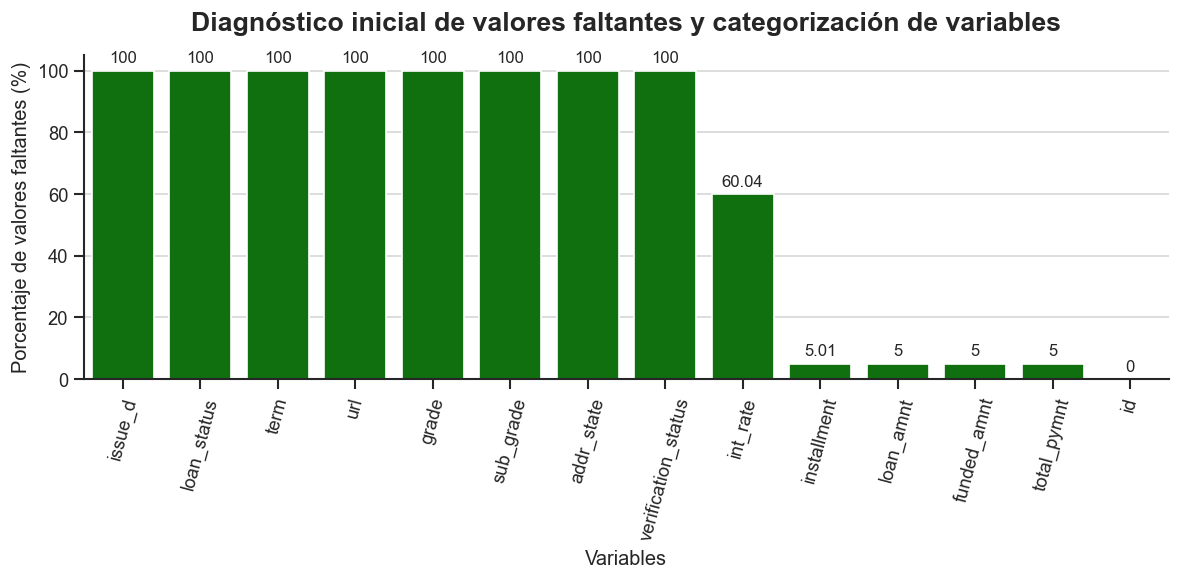

In [28]:
generacion_grafico_barra(
    datos=ordenado_pandas,
    columnas=ordenado_pandas.columns,
    titulo='Diagnóstico inicial de valores faltantes y categorización de variables',
    xlabel='Variables',
    ylabel='Porcentaje de valores faltantes (%)',
    ancho=10
)

---
---

A partir de los resultados obtenidos, se pueden establecer las siguientes conclusiones:

- Las variables `issue_d`, `loan_status`, `term`, `url`, `grade`, `sub_grade`, `addr_state` y `verification_status` no pueden convertirse directamente a un tipo de dato numérico, por lo que se clasifican preliminarmente como variables categóricas. Debido a la naturaleza de estas variables, el procedimiento empleado no permite evaluar, en esta etapa, la calidad o integridad de los datos asociados a sus registros.

- Aunque la variable `id` está compuesta por valores numéricos, su función es identificar de manera única cada registro del conjunto de datos. En consecuencia, se considera una variable categórica de identificación y no una variable numérica de análisis. Por esta razón, el porcentaje de valores no convertibles no constituye un criterio adecuado para evaluar la calidad de la información contenida en esta variable.

- Las variables `int_rate`, `loan_amnt`, `funded_amnt`, `installment` y `total_pymnt` presentan valores numéricos junto con diferentes proporciones de valores faltantes. Dado que la mayoría de sus registros corresponden a datos numéricos y que los valores no convertibles se asocian principalmente a registros ausentes, estas variables se clasifican como variables numéricas. No obstante, la presencia de valores faltantes evidencia diferencias en el nivel de integridad de la información disponible para cada una de ellas.

    En particular, se obtienen las siguientes métricas:

    * La variable `int_rate` presenta un **60.04 %** de valores faltantes, siendo la variable numérica con el mayor grado de pérdida de información.
    * La variable `installment` presenta un **5.01 %** de valores faltantes.
    * Las variables numéricas restantes presentan aproximadamente un **5 %** de valores faltantes, lo que indica un nivel de integridad significativamente superior al observado en `int_rate`.

---
---

In [29]:
lista_excepciones = ['id']

### 🤖 **Clasificación de las Agrupaciones de Datos**

---
---

Se realiza un análisis de las variables que componen el conjunto de datos con el propósito de identificar aquellas cuyos registros pueden convertirse a un tipo de dato numérico. Para ello, se evalúa el porcentaje de valores faltantes y de valores no convertibles obtenido en la etapa anterior, considerando además aquellas variables que, por su naturaleza, constituyen excepciones al criterio de clasificación.

A partir de este procedimiento se establecen los siguientes criterios:

* Si el porcentaje de valores no convertibles es igual al **100 %**, se concluye que ninguno de los registros de la variable puede interpretarse como un valor numérico. En consecuencia, la variable se clasifica preliminarmente como de naturaleza categórica.
* Las variables identificadas como excepciones no se clasifican utilizando el criterio anterior. Aunque sus registros estén representados mediante valores numéricos, su función dentro del conjunto de datos corresponde a categorías, etiquetas o identificadores, por lo que se consideran variables categóricas.

Es importante destacar que la capacidad de una variable para representarse mediante valores numéricos no implica necesariamente que esta sea una variable cuantitativa. En numerosos conjuntos de datos, las categorías, etiquetas o identificadores se codifican mediante números que carecen de significado numérico desde el punto de vista analítico.

Por esta razón, la clasificación definitiva de una variable no debe basarse únicamente en el formato de los datos que contiene, sino también en el propósito que desempeña dentro del conjunto de datos y en la naturaleza de la información que representa.

---
---

In [30]:
indice_numericos, indice_categoricos = clasificacion_variables(porcentajes=list(categoria_pandas['Porcentaje']), etiquetas=etiquetas, excepciones=lista_excepciones)

Lista de índices correspondientes a variables numéricas: [2, 4, 6, 7, 13]
Lista de índices correspondientes a variables categóricas: [0, 1, 3, 5, 8, 9, 10, 11, 12]


#### **Verificación del Proceso de Recategorización**

In [31]:
columnas_no_numericas, columnas_numericas = [], []

In [32]:
columnas_no_numericas = extraccion_columnas(
    categoria='Variables no numéricas',
    etiquetas=etiquetas,
    indices=indice_categoricos
)

Variables no numéricas
id
issue_d
loan_status
term
grade
sub_grade
verification_status
url
addr_state


In [33]:
columnas_numericas = extraccion_columnas(
    categoria='Variables numéricas',
    etiquetas=etiquetas,
    indices=indice_numericos
)

Variables numéricas
loan_amnt
funded_amnt
int_rate
installment
total_pymnt


### 🧠 **Cambio de Nombre de las Etiquetas**

___
___

Este procedimiento se realiza para proveerle una identificación más intuitiva a cada una de las variables contenidas en la base de datos
___
___

In [34]:
dic_etiquetas = {
    'id' : 'identificador',
    'issue_d' : 'fecha_prestamo',
    'loan_status' : 'estado_prestamo',
    'loan_amnt' : 'solicitud_prestamo_EUR',
    'funded_amnt' : 'aceptacion_prestamo_EUR',
    'term' : 'meses_prestamo',
    'grade' : 'grado',
    'sub_grade' : 'sub_grado',
    'verification_status' : 'estado_verificacion',
    'int_rate' : 'razon_intereses',
    'installment' : 'pago_mensual_EUR',
    'total_pymnt' : 'pago_efectuado_EUR',
    'url' : 'enlace',
    'addr_state' : 'estado',
}

In [35]:
etiquetas_previas = etiquetas.copy()
etiquetas = []

In [36]:
for i in etiquetas_previas:
    try:
        etiquetas.append(dic_etiquetas[i])
    except:
        pass

#### **Verificación del Proceso de Renombramiento de Variables**

In [37]:
columnas_no_numericas, columnas_numericas = [], []

In [38]:
columnas_no_numericas = extraccion_columnas(
    categoria='Variables no numéricas',
    etiquetas=etiquetas,
    indices=indice_categoricos
)

Variables no numéricas
identificador
fecha_prestamo
estado_prestamo
meses_prestamo
grado
sub_grado
estado_verificacion
enlace
estado


In [39]:
columnas_numericas = extraccion_columnas(
    categoria='Variables numéricas',
    etiquetas=etiquetas,
    indices=indice_numericos
)

Variables numéricas
solicitud_prestamo_EUR
aceptacion_prestamo_EUR
razon_intereses
pago_mensual_EUR
pago_efectuado_EUR


### 🤖 **Creación del DataFrame con Datos Crudos**

In [40]:
datos_pandas = pd.DataFrame(datos.transpose(), columns=etiquetas)
datos_pandas.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   identificador            10000 non-null  str  
 1   fecha_prestamo           10000 non-null  str  
 2   solicitud_prestamo_EUR   10000 non-null  str  
 3   estado_prestamo          10000 non-null  str  
 4   aceptacion_prestamo_EUR  10000 non-null  str  
 5   meses_prestamo           10000 non-null  str  
 6   razon_intereses          10000 non-null  str  
 7   pago_mensual_EUR         10000 non-null  str  
 8   grado                    10000 non-null  str  
 9   sub_grado                10000 non-null  str  
 10  estado_verificacion      10000 non-null  str  
 11  enlace                   10000 non-null  str  
 12  estado                   10000 non-null  str  
 13  pago_efectuado_EUR       10000 non-null  str  
dtypes: str(14)
memory usage: 1.1 MB


### 🤖 **Casteo de los Datos en el DataFrame**

#### *Variables Numéricas*

In [41]:
datos_pandas[columnas_numericas] = datos_pandas[columnas_numericas].apply(pd.to_numeric, errors = 'coerce')

In [42]:
datos_pandas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   identificador            10000 non-null  str    
 1   fecha_prestamo           10000 non-null  str    
 2   solicitud_prestamo_EUR   9500 non-null   float64
 3   estado_prestamo          10000 non-null  str    
 4   aceptacion_prestamo_EUR  9500 non-null   float64
 5   meses_prestamo           10000 non-null  str    
 6   razon_intereses          3996 non-null   float64
 7   pago_mensual_EUR         9499 non-null   float64
 8   grado                    10000 non-null  str    
 9   sub_grado                10000 non-null  str    
 10  estado_verificacion      10000 non-null  str    
 11  enlace                   10000 non-null  str    
 12  estado                   10000 non-null  str    
 13  pago_efectuado_EUR       9500 non-null   float64
dtypes: float64(5), str(9)
memory usage

#### *Variables No Numéricas*

In [43]:
datos_pandas[columnas_no_numericas] = datos_pandas[columnas_no_numericas].replace('', np.nan)

In [44]:
datos_pandas.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   identificador            10000 non-null  str    
 1   fecha_prestamo           9500 non-null   str    
 2   solicitud_prestamo_EUR   9500 non-null   float64
 3   estado_prestamo          9500 non-null   str    
 4   aceptacion_prestamo_EUR  9500 non-null   float64
 5   meses_prestamo           9500 non-null   str    
 6   razon_intereses          3996 non-null   float64
 7   pago_mensual_EUR         9499 non-null   float64
 8   grado                    9485 non-null   str    
 9   sub_grado                9486 non-null   str    
 10  estado_verificacion      9500 non-null   str    
 11  enlace                   10000 non-null  str    
 12  estado                   9500 non-null   str    
 13  pago_efectuado_EUR       9500 non-null   float64
dtypes: float64(5), str(9)
memory usage

### 🧠 **Exploración Métrica de la Base de Datos**

####  **Métricas de Completitud / Ausencia de Datos**

___
___

Una vez obtenida la estructura de datos resultante de las etapas anteriores, se dispone de un conjunto de datos consistente en cuanto al formato de las variables y a la identificación de los valores presentes y ausentes. A partir de esta estructura es posible calcular diferentes indicadores que permiten evaluar la completitud del conjunto de datos desde distintas perspectivas.

Las métricas consideradas en esta etapa son las siguientes:

* Cantidad total de valores ausentes presentes en el conjunto de datos.

* Cantidad de variables que contienen al menos un valor ausente.

* Cantidad de registros que contienen al menos un valor ausente.

* Distribución de los valores ausentes por variable.

* Distribución de los valores ausentes por registro.

El análisis conjunto de estos indicadores permite evaluar el grado de completitud de la información disponible, identificando tanto las variables como los registros más afectados por la asuencia de datos. Esta caracterización constituye un insumo fundamental para definir las estrategias de limpieza e imputación que se aplicarán en las etapas posteriores del proceso de preprocesamiento de datos.
___
___

#####  *Métricas Generalizadas de la Base de Datos*

In [45]:
cantidad_nulos = datos_pandas.isna().sum(axis=0).sum()
cantidad_total = datos_pandas.count().sum() + cantidad_nulos
print(f'Total de datos faltantes: {cantidad_nulos}')
print(f'Total de valores en la base de datos: {cantidad_total}')
print(f'Proporción de valores faltantes con relación al total: {round(cantidad_nulos/cantidad_total*100, 3)} %')
print(f'Índice global de completitud {round((1-cantidad_nulos/cantidad_total)*100, 3)} %')

Total de datos faltantes: 11534
Total de valores en la base de datos: 140000
Proporción de valores faltantes con relación al total: 8.239 %
Índice global de completitud 91.761 %


In [46]:
registros_valores_nulos = (datos_pandas.isna().sum(axis=1) > 0).sum()
total_registros_nulos = datos_pandas.shape[0]

print(f'Total de registros con valores faltantes: {registros_valores_nulos}')
print(f'Total de registros: {total_registros_nulos}')
print(f'Proporción de registros faltantes con relación al total: {round(registros_valores_nulos/total_registros_nulos*100, 3)} %')
print(f'Índice de completitud de los registros {round((1-registros_valores_nulos/total_registros_nulos)*100, 3)} %')

Total de registros con valores faltantes: 8317
Total de registros: 10000
Proporción de registros faltantes con relación al total: 83.17 %
Índice de completitud de los registros 16.83 %


In [47]:
variables_valores_nulos = (datos_pandas.isna().sum(axis=0) > 0).sum()
total_variables_nulos = datos_pandas.shape[1]

print(f'Total de variables con valores faltantes: {variables_valores_nulos}')
print(f'Total de variables: {total_variables_nulos}')
print(f'Proporción de variables faltantes con relación al total: {round(variables_valores_nulos/total_variables_nulos*100,3)} %')
print(f'Índice de completitud de las variables {round((1-variables_valores_nulos/total_variables_nulos)*100, 3)} %')

Total de variables con valores faltantes: 12
Total de variables: 14
Proporción de variables faltantes con relación al total: 85.714 %
Índice de completitud de las variables 14.286 %


#####  ⭐ *Observaciones*

___
___

A partir de las métricas analíticas de completitud obtenidas del conjunto de datos, se obtienen los siguientes indicadores globales:

* La base de datos contiene un total de 140 000 datos, distribuidos por 1 000 registros y 14 variables. 

* El conjunto de datos contiene un total de 11 534 valores ausentes, lo que representa el 8.24 % del total de 140 000 valores que conforman la base de datos. En consecuencia, el índice global de completitud es del 91.76 %, lo que indica que la mayor parte de la información requerida se encuentra disponible.

* De los 10 000 registros analizados, 8 317 presentan al menos un valor ausente. Esto equivale al 83.17 % del total de registros, mientras que únicamente el 16.83 % de los registros se encuentran completamente definidos, es decir, no contienen valores faltantes.

* En cuanto a las variables, 12 de las 14 presentan al menos un valor ausente, lo que representa el 85.71 % del total de variables. En consecuencia, únicamente 2 variables (14.29 %) poseen información completamente íntegra en todos sus registros.

Estos indicadores muestran que:

* Si bien la proporción global de valores ausentes es relativamente reducida, representando únicamente el 8.24 % del total de datos contenidos en la base de datos, la distribución de dichos valores faltantes se encuentra ampliamente dispersa tanto entre los registros como entre las variables. En particular, el 83.17 % de los registros presenta al menos un valor ausente y el 85.71 % de las variables contiene información incompleta. Estos resultados evidencian que, aunque la cantidad total de valores faltantes no es elevada, su distribución afecta a una gran parte de la estructura del conjunto de datos, lo que justifica la aplicación de técnicas de limpieza e imputación antes de llevar a cabo análisis posteriores.

___
___

#####  *Completitud por variable*

In [48]:
completitud_variables_pandas, completitud_variables_ordenado = completitud_variables_datos(datos=datos_pandas, etiquetas=etiquetas)

                  Categoria  Porcentaje
0             identificador        0.00
1            fecha_prestamo        5.00
2    solicitud_prestamo_EUR        5.00
3           estado_prestamo        5.00
4   aceptacion_prestamo_EUR        5.00
5            meses_prestamo        5.00
6           razon_intereses       60.04
7          pago_mensual_EUR        5.01
8                     grado        5.15
9                 sub_grado        5.14
10      estado_verificacion        5.00
11                   enlace        0.00
12                   estado        5.00
13       pago_efectuado_EUR        5.00


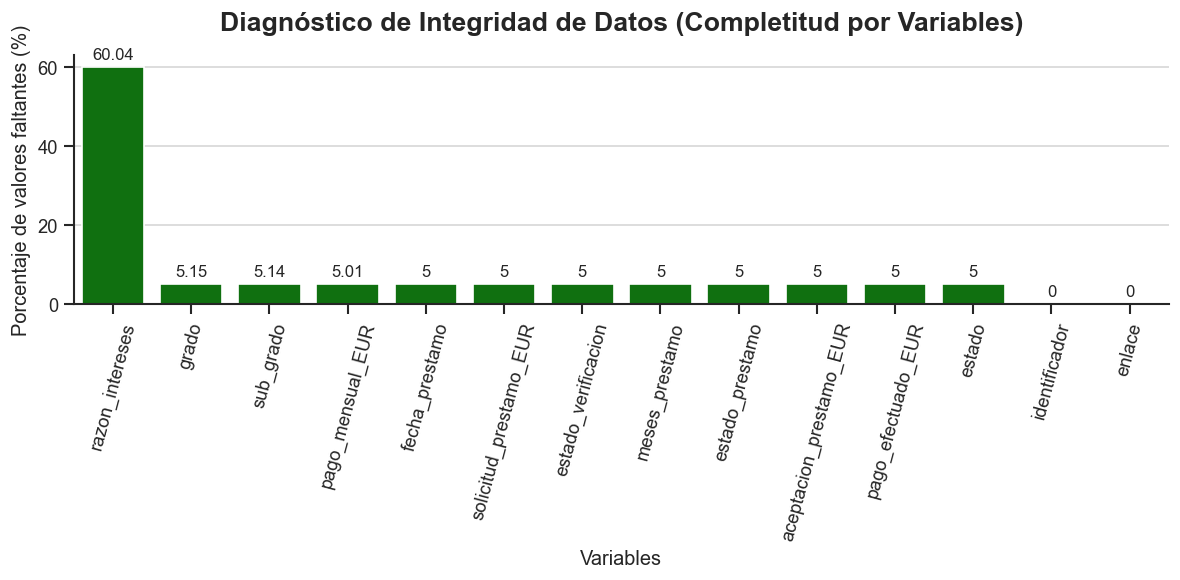

In [49]:
generacion_grafico_barra(
    datos=completitud_variables_ordenado,
    columnas=completitud_variables_ordenado.columns,
    titulo='Diagnóstico de Integridad de Datos (Completitud por Variables)',
    xlabel='Variables',
    ylabel='Porcentaje de valores faltantes (%)',
    ancho=10
)

##### ⭐ *Observaciones*

___
___

A partir de los resultados obtenidos en la gráfica correspondiente a la caracterización de valores ausentes por cada una de las variables de la base de datos, se establecen las siguientes conclusiones:

- La variable `razon_interes` presenta el mayor porcentaje de valores faltantes del conjunto de datos. En consecuencia, si no es posible aplicar una estrategia de imputación adecuada, la información disponible para esta variable resulta limitada para realizar análisis posteriores, ya que el **60.04 %** de sus registros se encuentra ausente.

- Las variables `identificador` y `enlace` presentan un **100 %** de completitud, por lo que no requieren la aplicación de procedimientos de imputación relacionados con la presencia de valores faltantes.

- Las demás variables presentan bajos porcentajes de valores faltantes **(~5 %)**. No obstante, su nivel de integridad puede mejorarse mediante la aplicación de técnicas de imputación, siempre que estas se encuentren debidamente justificadas y fundamentadas en la relación existente entre las variables del conjunto de datos.

---
___

#####  *Completitud por registro*

In [50]:
completitud_registros_pandas = completitud_registros_datos(datos=datos_pandas)

   Cantidad_nulos  Porcentaje
2               0       16.83
0               1       51.11
1               2       31.96
3               3        0.09
4               4        0.01


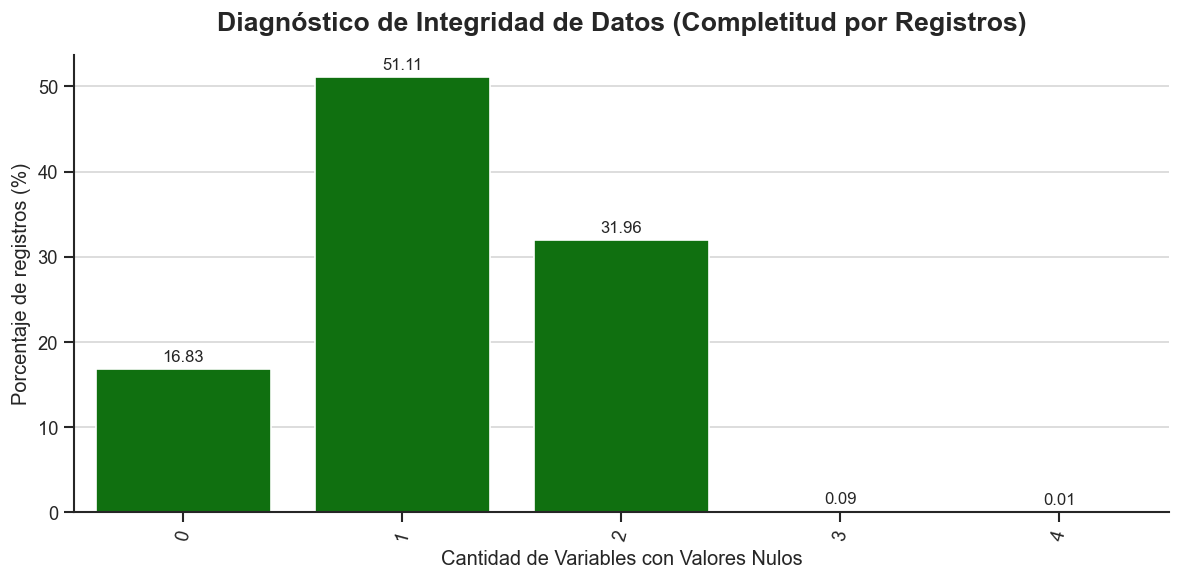

In [51]:
generacion_grafico_barra(
    datos=completitud_registros_pandas,
    columnas=completitud_registros_pandas.columns,
    titulo='Diagnóstico de Integridad de Datos (Completitud por Registros)',
    xlabel='Cantidad de Variables con Valores Nulos',
    ylabel='Porcentaje de registros (%)',
    ancho=10
)

##### ⭐ *Observaciones*


___
___

En los resultados obtenidos se observa que el **51.11 %** de los registros de la base de datos presenta únicamente una variable con un valor faltante. Este resultado pone de manifiesto la importancia de implementar un proceso de imputación, ya que, de no realizarse, una proporción considerable de los registros podría descartarse durante las etapas posteriores de análisis, reduciendo el tamaño efectivo de la muestra y la representatividad de los resultados.

Asimismo, el **31.96 %** de los registros contiene dos variables con valores faltantes. Esta situación evidencia la existencia de un grado apreciable de concurrencia de datos ausentes dentro de un mismo registro, fenómeno que probablemente se encuentra influenciado por la elevada proporción de valores faltantes observada en la variable correspondiente a la tasa de interés. En consecuencia, la ausencia de información en dicha variable incrementa la probabilidad de que un registro acumule más de un dato faltante.

Por otra parte, los registros que presentan tres o más valores faltantes representan únicamente el **0.10 %** del conjunto de datos, por lo que su incidencia resulta prácticamente despreciable. Este comportamiento es consistente con el hecho de que únicamente una variable exhibe una proporción elevada de valores ausentes, mientras que el resto presenta porcentajes de datos faltantes considerablemente menores. En consecuencia, no se observa evidencia de un patrón de ausencia que afecte simultáneamente a un gran número de variables dentro de un mismo registro, aunque serían necesarios análisis adicionales para determinar formalmente el mecanismo de ausencia de los datos (MCAR, MAR o MNAR).

Finalmente, solo el **16.83 %** de los registros conserva la totalidad de sus variables sin valores faltantes, lo que indica que más del **83 %** de la información disponible requiere algún tipo de tratamiento previo antes de ser utilizada en procesos analíticos. Este resultado justifica la implementación de un procedimiento sistemático de limpieza e imputación de datos, siempre que las técnicas empleadas se encuentren debidamente fundamentadas y sean consistentes con la naturaleza de las variables y con el mecanismo de generación de los valores ausentes.
___
___

####  **Métricas de Unicidad / Duplicidad de Datos**

___
___

A continuación, se realiza un análisis de la duplicidad presente en el conjunto de datos, con el objetivo de identificar tanto la existencia de registros redundantes como la presencia de valores duplicados en las variables de identificación de registros que han sido proveídas. Este análisis permite evaluar la unicidad de la información y detectar posibles inconsistencias derivadas de la repetición de datos.

Las métricas consideradas en esta etapa son las siguientes:

* Cantidad total de registros duplicados en el conjunto de datos.

* Cantidad de valores duplicados por cada una de las variables de identificación.

El análisis conjunto de estos indicadores permite identificar la existencia de información redundante y determinar si la presencia de registros o valores repetidos puede afectar la representatividad del conjunto de datos. Los resultados obtenidos constituyen un criterio fundamental para decidir la aplicación de procedimientos de eliminación de duplicados o de consolidación de registros antes de continuar con las etapas posteriores de limpieza y preprocesamiento.

___
___

##### *Registros duplicados*

In [52]:
registros_duplicados = datos_pandas.duplicated().sum()
total_registros = datos_pandas.shape[0]
print(f'Cantidad de registros duplicados: {registros_duplicados}')
print(f'Total de registros: {total_registros}')
print(f'Proporción de registros duplicados: {round(registros_duplicados/total_registros*100, 2)} %')
print(f'Índice de unicidad de los registros: {round((1 - registros_duplicados/total_registros)*100, 2)} %')

Cantidad de registros duplicados: 0
Total de registros: 10000
Proporción de registros duplicados: 0.0 %
Índice de unicidad de los registros: 100.0 %


#####  *Identificadores duplicados*

In [53]:
identificadores_duplicados = datos_pandas[etiquetas[0]].duplicated().sum()
total_registros = datos_pandas['identificador'].shape[0]
print(f'Cantidad de identificadores duplicados: {identificadores_duplicados}')
print(f'Total de registros: {total_registros}')
print(f'Proporción de identificadores duplicados: {round(identificadores_duplicados/total_registros*100, 2)} %')
print(f'Índice de unicidad de los identificadores: {round((1 - identificadores_duplicados/total_registros)*100, 2)} %')

Cantidad de identificadores duplicados: 0
Total de registros: 10000
Proporción de identificadores duplicados: 0.0 %
Índice de unicidad de los identificadores: 100.0 %


##### ⭐ *Observaciones*

___
___

A partir de los indicadores obtenidos se establecen las siguientes conclusiones:

- No se identificaron registros duplicados en la base de datos. Este resultado indica que cada observación representa un préstamo diferente y que no existen registros redundantes que puedan introducir sesgos en los análisis estadísticos.

- La totalidad de los 10 000 registros corresponden a observaciones únicas, por lo que el índice de unicidad de los registros es del **100 %**. En consecuencia, no es necesario aplicar procedimientos de eliminación de registros duplicados durante la etapa de limpieza de datos.

- Asimismo, no se detectaron identificadores duplicados, lo que confirma que la variable identificador cumple adecuadamente su función como clave única del conjunto de datos. Esta propiedad garantiza que cada préstamo puede ser identificado de manera unívoca.

- La ausencia simultánea de registros duplicados y de identificadores repetidos constituye un indicador favorable de la integridad estructural del conjunto de datos, ya que evidencia que no existen problemas asociados a la replicación accidental de información.

Aunque no fue necesario realizar acciones correctivas en esta etapa, la verificación de la unicidad de los registros y de los identificadores representa una buena práctica dentro del proceso de limpieza de datos, puesto que permite descartar de forma temprana posibles inconsistencias que podrían afectar la calidad de los análisis posteriores.

___
___

##### 🛠️ *Cambios efectuados*

Eliminación de registros duplicados

In [54]:
datos_pandas = datos_pandas.drop_duplicates()

Sería importante analizar los casos en los cuales la variable de identificación posea un duplicado posterior al proceso de eliminación realizado

In [55]:
datos_pandas[datos_pandas['identificador'].duplicated()]

,identificador,fecha_prestamo,solicitud_prestamo_EUR,estado_prestamo,aceptacion_prestamo_EUR,meses_prestamo,razon_intereses,pago_mensual_EUR,grado,sub_grado,estado_verificacion,enlace,estado,pago_efectuado_EUR


####  **Métricas de Cardinalidad de Datos**

___
___

Una vez evaluadas la completitud y la unicidad del conjunto de datos, resulta conveniente analizar la cardinalidad de las variables que lo componen. La cardinalidad se refiere al número de valores distintos que puede tomar una variable dentro del conjunto de datos y constituye una característica fundamental para comprender la naturaleza de la información almacenada.

El estudio de la cardinalidad permite:

* Diferenciar variables identificadoras, variables numéricas continuas y variables categóricas.

* Detectar posibles anomalías relacionadas con la presencia de valores inesperados, categorías mal definidas o una variabilidad inferior o superior a la esperada. 

* Proporciona información útil para la selección de estrategias de codificación, agrupación de categorías y reducción de variables durante las etapas posteriores del preprocesamiento de datos.

Las métricas consideradas en esta etapa son las siguientes:

- Cardinalidad absoluta por variable.

- Cardinalidad relativa por variable.

- Clasificación de la cardinalidad de las variables.

- Comparación entre la clasificación de la cardinalidad de los datos y el formato aplicado a cada una de las variables

El análisis conjunto de estos indicadores permite caracterizar el grado de diversidad de la información contenida en cada variable y evaluar si dicha diversidad es consistente con la naturaleza de los datos que representa.

___
___

##### *Cardinalidad Absoluta*

___
___

La cardinalidad absoluta se corresponde a la cantidad de valores únicos presentes en cada una de las variables que componen la base de datos proveída.
___
___

In [56]:
unicos_pandas = pd.DataFrame({
    'Categoría': etiquetas,
    'Cantidad de Valores Unicos': datos_pandas[etiquetas].fillna('N/A').nunique().values
})

unicos_pandas_ordenados = unicos_pandas.sort_values('Cantidad de Valores Unicos', ascending=False)

unicos_pandas.head()

,Categoría,Cantidad de Valores Unicos
0,identificador,10000
1,fecha_prestamo,13
2,solicitud_prestamo_EUR,886
3,estado_prestamo,9
4,aceptacion_prestamo_EUR,890


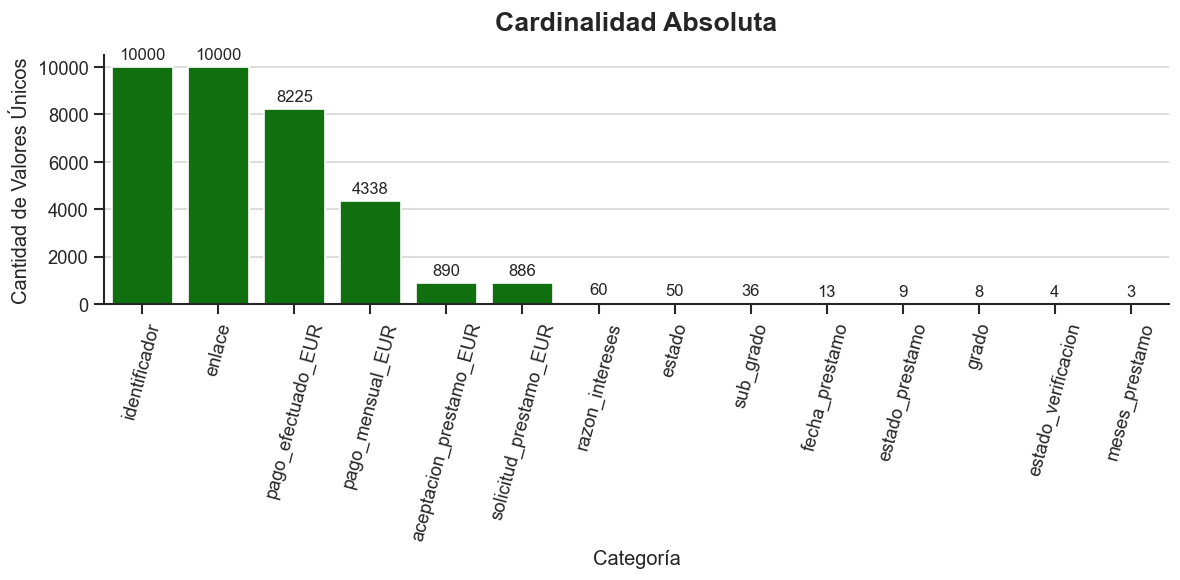

In [57]:
generacion_grafico_barra(
    datos=unicos_pandas_ordenados,
    columnas=unicos_pandas.columns,
    xlabel='Categoría',
    ylabel='Cantidad de Valores Únicos',
    titulo='Cardinalidad Absoluta',
    ancho=10
)

##### ⭐ *Observaciones*

___
___

A partir del análisis de la cardinalidad absoluta de las variables que conforman la base de datos, se obtienen las siguientes conclusiones:

* Las variables `identificador` y `enlace` presentan **10 000** valores únicos, equivalentes al número total de registros del conjunto de datos. Esta característica confirma que ambas variables pueden emplearse como identificadores únicos de cada observación. Sin embargo, debido a que ambas cumplen una función similar, es conveniente evaluar la posible redundancia de la información que contienen.

* Las variables `pago_efectuado_EUR` y `pago_mensual_EUR` presentan una cardinalidad elevada, con **8 225** y **4 338** valores únicos, respectivamente. Este comportamiento es consistente con la naturaleza continua de las variables monetarias, en las cuales es esperable una amplia diversidad de valores debido a las diferencias existentes entre los préstamos otorgados y los pagos realizados.

* Las variables `aceptacion_prestamo_EUR` y `solicitud_prestamo_EUR` presentan una cardinalidad intermedia (**890** y **886** valores únicos, respectivamente), lo que indica que, aunque existe una diversidad considerable de montos, diferentes registros comparten los mismos valores. Este comportamiento es habitual en variables financieras cuyos importes suelen concentrarse alrededor de determinados montos de referencia.

* La variable `razon_intereses` presenta únicamente **60** valores únicos, comportamiento consistente con una tasa de interés que únicamente puede tomar un conjunto limitado de valores. No obstante, este resultado debe analizarse conjuntamente con el estudio de completitud, ya que la elevada proporción de valores ausentes identificada previamente puede haber reducido la diversidad observada.

* La variable `estado` contiene **50** valores únicos, resultado que coincide con el número de estados que conforman los Estados Unidos. Esto sugiere que la cobertura geográfica del conjunto de datos es consistente con el dominio esperado para dicha variable.

* Las variables `sub_grado`, `grado`, `estado_prestamo`, `estado_verificacion`, `fecha_prestamo` y `meses_prestamo` presentan una baja cardinalidad. Este comportamiento es coherente con su naturaleza categórica, ya que representan atributos cuyos valores pertenecen a un conjunto reducido y previamente definido de categorías.

En términos generales, la distribución de la cardinalidad es consistente con la función que desempeña cada variable dentro del conjunto de datos. No se identifican anomalías que indiquen una diversidad excesiva o insuficiente de valores respecto a la naturaleza esperada de la información almacenada.
___
___

##### *Cardinalidad Relativa*

___
___

La cardinalidad relativa se define como la proporción de valores únicos que presenta una variable con relación al número total de registros del conjunto de datos. Esta métrica constituye una medida normalizada de la diversidad de los valores contenidos en cada variable, lo que permite comparar su comportamiento entre diferentes bases de datos sin que el tamaño de la muestra influya en la interpretación de los resultados. En consecuencia, la cardinalidad relativa representa un criterio útil para la clasificación de variables y el análisis de la estructura del conjunto de datos.

___
___

In [58]:
unicos_pandas_proporcion = unicos_pandas.copy()
unicos_pandas_proporcion['Proporcion'] = unicos_pandas_proporcion['Cantidad de Valores Unicos']/datos_pandas.shape[0]*100
unicos_pandas_proporcion = unicos_pandas_proporcion.drop('Cantidad de Valores Unicos', axis=1)
unicos_pandas_proporcion_ordenados = unicos_pandas_proporcion.sort_values('Proporcion', ascending=False)
unicos_pandas_proporcion.head()

,Categoría,Proporcion
0,identificador,100.00
1,fecha_prestamo,0.13
2,solicitud_prestamo_EUR,8.86
3,estado_prestamo,0.09
4,aceptacion_prestamo_EUR,8.90


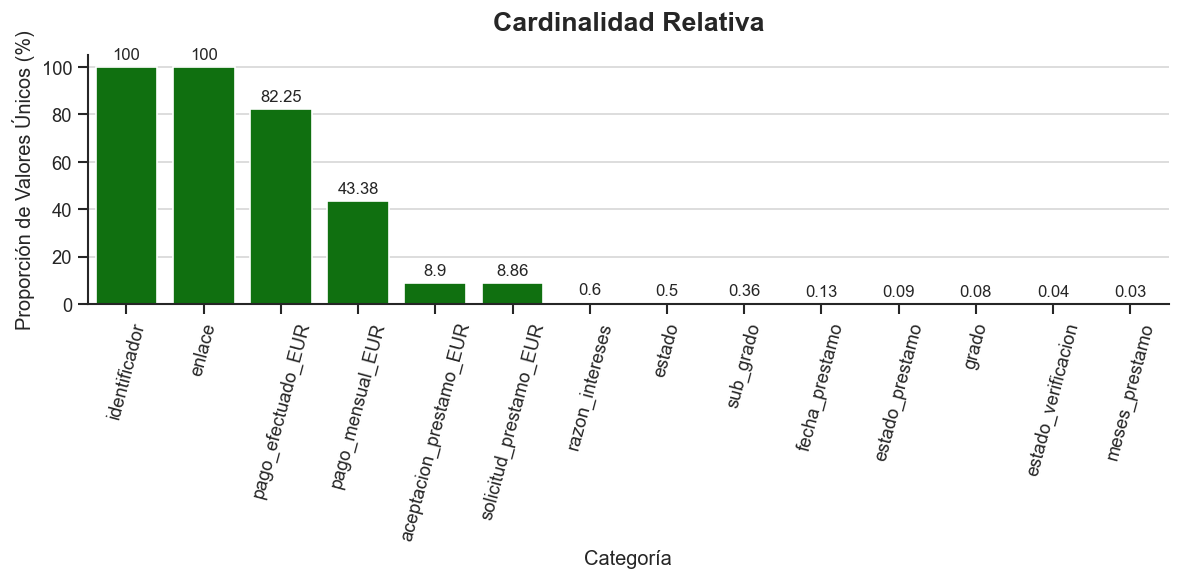

In [59]:
generacion_grafico_barra(
    datos=unicos_pandas_proporcion_ordenados,
    columnas=unicos_pandas_proporcion_ordenados.columns,
    xlabel='Categoría',
    ylabel='Proporción de Valores Únicos (%)',
    titulo='Cardinalidad Relativa',
    ancho=10
)

##### ⭐ *Observaciones*

___
___

Los resultados obtenidos son consistentes con los presentados en el análisis de cardinalidad absoluta, ya que la cardinalidad relativa constituye una versión normalizada de dicho indicador. 

En particular, se verifica que las variables `identificador` y `enlace` presentan una cardinalidad relativa del 100 %, lo que confirma que cada registro posee un valor único para ambas variables. Este comportamiento es característico de variables utilizadas como identificadores y sugiere la posible existencia de redundancia de información entre ellas, aspecto que deberá analizarse en etapas posteriores.

Adicionalmente, la cardinalidad relativa proporciona un criterio objetivo para clasificar las variables según su grado de diversidad, independientemente del tamaño del conjunto de datos. Resulta conveniente comparar esta clasificación con la obtenida durante la etapa inicial del análisis exploratorio, en la cual las variables fueron clasificadas de acuerdo con el formato de los datos que contienen (numéricas o no numéricas).

La comparación entre ambos criterios de clasificación permite detectar posibles inconsistencias o anomalías. Por ejemplo, una variable identificada inicialmente como categórica podría presentar una cardinalidad muy elevada, indicando que en realidad se comporta como un identificador o una variable continua. De forma análoga, una variable clasificada como numérica podría exhibir una cardinalidad reducida, lo que sugeriría que representa un conjunto limitado de categorías codificadas mediante valores numéricos. En consecuencia, el análisis conjunto del tipo de dato y de la cardinalidad proporciona una caracterización más completa de la naturaleza de las variables que integran el conjunto de datos.
___
___

##### *Clasificación de la Cardinalidad*

___
___

Con el propósito de facilitar la interpretación de los resultados obtenidos, las variables se clasifican de acuerdo con su cardinalidad relativa, empleando un conjunto de intervalos definidos específicamente para el presente estudio. Esta clasificación constituye un criterio metodológico orientado a caracterizar el grado de diversidad de los valores contenidos en cada variable y a facilitar la comparación entre ellas, independientemente del tamaño del conjunto de datos.

La clasificación adoptada es la siguiente:

- **Cardinalidad muy alta**: mayor que **80 %**.
- **Cardinalidad alta**: entre **20 %** y **80 %**.
- **Cardinalidad media**: entre **5 %** y **20 %**.
- **Cardinalidad baja**: entre **1 %** y **5 %**.
- **Cardinalidad muy baja**: menor que **1 %**.

Esta clasificación se emplea únicamente con fines descriptivos y de interpretación, permitiendo identificar de manera sistemática variables con un elevado grado de diversidad, variables predominantemente categóricas y posibles variables que desempeñan funciones de identificación dentro del conjunto de datos.

___
___

In [60]:
unicos_pandas_clasificados = unicos_pandas_proporcion.copy()

# Clasificación por defecto
unicos_pandas_clasificados['Clasificacion'] = 'Muy baja'

dict_umbrales = {
    1: 'Baja',
    5: 'Media',
    20: 'Alta',
    80: 'Muy alta'
}

for umbral, clasificacion in dict_umbrales.items():
    unicos_pandas_clasificados.loc[
        unicos_pandas_clasificados['Proporcion'] > umbral,
        'Clasificacion'
    ] = clasificacion

unicos_pandas_clasificados = unicos_pandas_clasificados.drop('Proporcion', axis=1)

unicos_pandas_clasificados[:]

,Categoría,Clasificacion
0,identificador,Muy alta
1,fecha_prestamo,Muy baja
2,solicitud_prestamo_EUR,Media
3,estado_prestamo,Muy baja
4,aceptacion_prestamo_EUR,Media
5,meses_prestamo,Muy baja
6,razon_intereses,Muy baja
7,pago_mensual_EUR,Alta
8,grado,Muy baja
9,sub_grado,Muy baja


In [61]:
distribucion_clasificaciones_pandas = pd.DataFrame(unicos_pandas_clasificados.value_counts('Clasificacion').reset_index())
distribucion_clasificaciones_pandas

,Clasificacion,count
0,Muy baja,8
1,Muy alta,3
2,Media,2
3,Alta,1


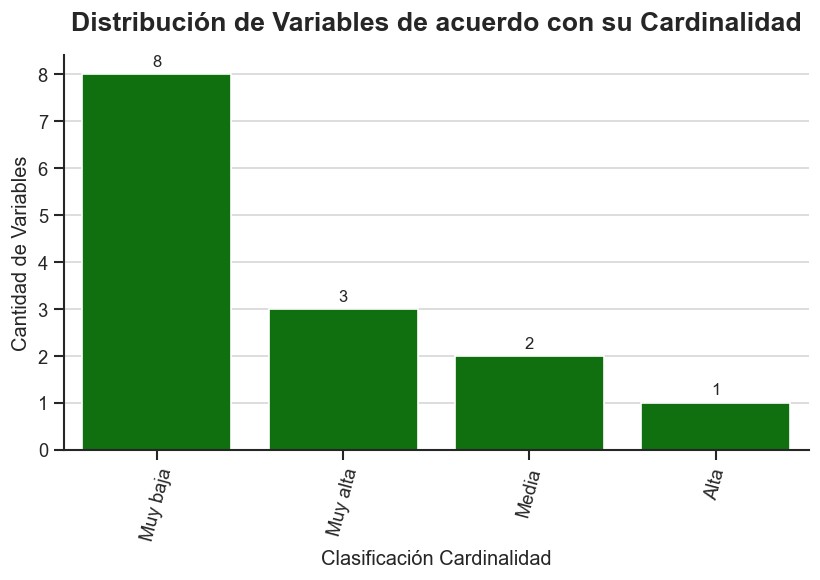

In [62]:
generacion_grafico_barra(
     datos=distribucion_clasificaciones_pandas,
     columnas=distribucion_clasificaciones_pandas.columns,
     titulo='Distribución de Variables de acuerdo con su Cardinalidad',
     xlabel='Clasificación Cardinalidad',
     ylabel='Cantidad de Variables'
)

##### ⭐ *Observaciones*

___
___

A partir de la clasificación de las variables según su cardinalidad relativa, se obtienen las siguientes conclusiones:

* La mayor parte de las variables de la base de datos (8 de las 14 variables analizadas) presentan una cardinalidad muy baja, lo que indica que están compuestas por un número reducido de valores distintos con relación al total de registros. Este comportamiento es característico de variables categóricas o de variables cuyos valores pertenecen a un dominio previamente definido.

* Se identifican tres variables con cardinalidad muy alta, las cuales presentan una elevada diversidad de valores. Este resultado es consistente con variables utilizadas como identificadores o con variables numéricas continuas, cuya naturaleza favorece la existencia de un gran número de valores distintos.

* Únicamente dos variables presentan una cardinalidad media, lo que evidencia una diversidad moderada de valores. Estas variables pueden corresponder a atributos numéricos discretos o a variables cuyos valores se encuentran concentrados en un conjunto limitado de posibilidades.

* Solo una variable fue clasificada con cardinalidad alta, indicando que, aunque existe una elevada diversidad de valores, esta no alcanza el nivel observado en las variables clasificadas como de cardinalidad muy alta.

En términos generales, la distribución de la cardinalidad refleja una estructura equilibrada y coherente con la naturaleza del conjunto de datos, en la que predominan las variables categóricas de baja diversidad y un grupo reducido de variables con elevada cardinalidad asociadas a identificadores y magnitudes numéricas.

La clasificación obtenida constituye un criterio complementario al análisis basado en el tipo de dato de las variables. Mientras que la clasificación inicial permite distinguir entre variables numéricas y no numéricas, el estudio de la cardinalidad proporciona información acerca del grado de diversidad de los valores que contiene cada variable. La combinación de ambos enfoques facilita la identificación de variables identificadoras, variables categóricas y variables numéricas, además de contribuir a la detección de posibles inconsistencias o anomalías en la estructura del conjunto de datos.
___
___

##### *Comparación Cardinalidad vs Formato*

In [63]:
unicos_pandas_comparacion = unicos_pandas_clasificados.copy()

unicos_pandas_comparacion.rename(
    columns={
        'Clasificacion' : 'Clasificacion Cardinalidad'
    }, inplace=True
)

unicos_pandas_comparacion['Clasificacion Formato'] = 'No Numérica'

unicos_pandas_comparacion.loc[unicos_pandas_comparacion['Categoría'].isin(columnas_numericas), 'Clasificacion Formato'] = 'Numérica'

unicos_pandas_comparacion[:]

,Categoría,Clasificacion Cardinalidad,Clasificacion Formato
0,identificador,Muy alta,No Numérica
1,fecha_prestamo,Muy baja,No Numérica
2,solicitud_prestamo_EUR,Media,Numérica
3,estado_prestamo,Muy baja,No Numérica
4,aceptacion_prestamo_EUR,Media,Numérica
5,meses_prestamo,Muy baja,No Numérica
6,razon_intereses,Muy baja,Numérica
7,pago_mensual_EUR,Alta,Numérica
8,grado,Muy baja,No Numérica
9,sub_grado,Muy baja,No Numérica


In [64]:
distribucion_categorica = (
    unicos_pandas_comparacion
    .groupby(
        ['Clasificacion Formato', 'Clasificacion Cardinalidad']
    )
    .size()
    .reset_index(name='Cantidad')
)

distribucion_categorica

,Clasificacion Formato,Clasificacion Cardinalidad,Cantidad
0,No Numérica,Muy alta,2
1,No Numérica,Muy baja,7
2,Numérica,Alta,1
3,Numérica,Media,2
4,Numérica,Muy alta,1
5,Numérica,Muy baja,1


In [65]:
distribucion_no_numerico = distribucion_categorica[distribucion_categorica['Clasificacion Formato']=='No Numérica'].drop('Clasificacion Formato', axis=1)
distribucion_no_numerico

,Clasificacion Cardinalidad,Cantidad
0,Muy alta,2
1,Muy baja,7


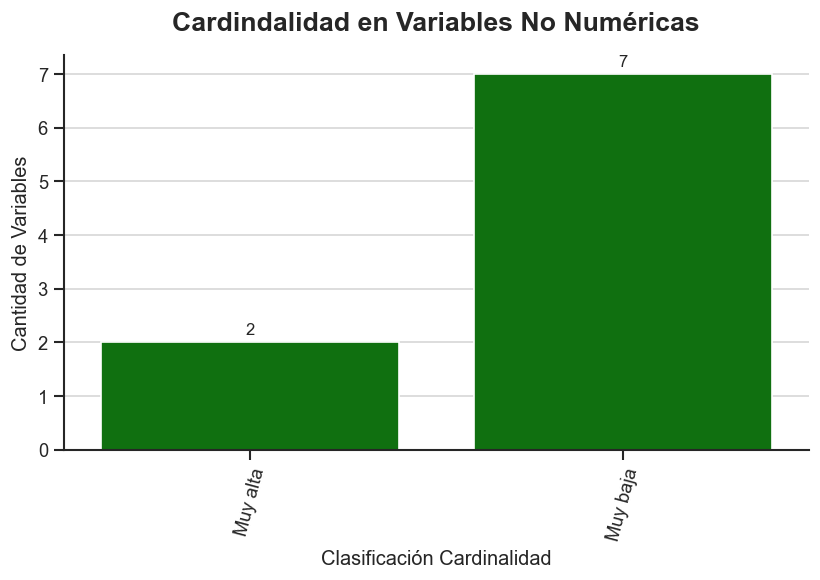

In [66]:
generacion_grafico_barra(
    datos=distribucion_no_numerico,
    columnas=distribucion_no_numerico.columns,
    titulo='Cardindalidad en Variables No Numéricas',
    xlabel='Clasificación Cardinalidad',
    ylabel='Cantidad de Variables'
)

In [67]:
distribucion_numerico = distribucion_categorica[distribucion_categorica['Clasificacion Formato']=='Numérica'].drop('Clasificacion Formato', axis=1)
distribucion_numerico

,Clasificacion Cardinalidad,Cantidad
2,Alta,1
3,Media,2
4,Muy alta,1
5,Muy baja,1


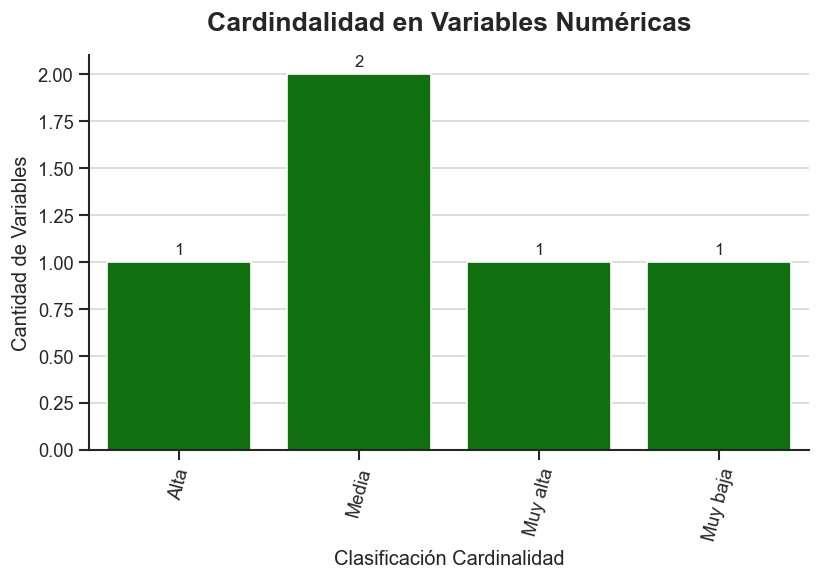

In [68]:
generacion_grafico_barra(
    datos=distribucion_numerico,
    columnas=distribucion_numerico.columns,
    titulo='Cardindalidad en Variables Numéricas',
    xlabel='Clasificación Cardinalidad',
    ylabel='Cantidad de Variables'
)

##### ⭐ *Observaciones*

___
___

A partir de la comparación entre la clasificación de las variables según su formato y su nivel de cardinalidad, se obtienen las siguientes conclusiones:

* La mayoría de las variables no numéricas (7 de 9) presentan una cardinalidad muy baja, lo cual es consistente con su naturaleza categórica. Este comportamiento indica que dichas variables están compuestas por un conjunto reducido de categorías, característica esperada en atributos como estados, grados o clasificaciones.

* Dentro del conjunto de variables no numéricas, únicamente dos variables presentan una cardinalidad muy alta. Este resultado corresponde a las variables `identificador` y `enlace`, las cuales fueron clasificadas inicialmente como no numéricas debido a su formato, pero cuya elevada cardinalidad confirma que desempeñan la función de identificadores únicos de los registros y no la de variables categóricas convencionales.

* Las variables numéricas presentan una distribución de cardinalidad más heterogénea. Se identifican variables con cardinalidad media, alta y muy alta, comportamiento esperado en variables cuantitativas asociadas a montos, pagos y tasas de interés, cuyos valores presentan diferentes niveles de variabilidad.

* Se identifica una variable numérica con cardinalidad muy baja, correspondiente a `razon_intereses`. En principio, este comportamiento podría sugerir que la variable está compuesta por un conjunto reducido de valores posibles, característica propia de variables categóricas codificadas mediante valores numéricos. Sin embargo, esta conclusión no puede establecerse únicamente a partir del análisis de la cardinalidad.

    Es importante considerar que razon_intereses presenta la mayor proporción de valores ausentes dentro del conjunto de datos, lo que puede reducir significativamente el número de valores únicos observados y afectar la estimación de su cardinalidad. Adicionalmente, al tratarse de una tasa de interés, es posible que los valores se encuentren discretizados o redondeados, circunstancia que también disminuiría el número de valores distintos sin modificar la naturaleza cuantitativa de la variable.

    En consecuencia, los resultados obtenidos constituyen un indicio de que esta variable requiere un análisis más detallado. En las etapas posteriores del proceso de preprocesamiento será necesario estudiar su distribución, la frecuencia de sus valores y el mecanismo asociado a la ausencia de datos, con el propósito de determinar si la baja cardinalidad responde a las características propias de la variable o si constituye una anomalía derivada de la calidad de los datos.

En conjunto, la comparación entre ambas clasificaciones confirma que el criterio basado en el formato de los datos y el criterio basado en la cardinalidad son complementarios. Mientras que el primero identifica la representación de los datos, el segundo caracteriza la diversidad de los valores contenidos en cada variable. La utilización conjunta de ambos enfoques permite describir con mayor precisión la naturaleza de las variables y detectar posibles excepciones que requieren un tratamiento específico durante las etapas posteriores de preprocesamiento.
___
___

##### 🛠️ *Cambios efectuados*

___
___

Al evaluar las variables de identificación en la base de datos, se detectó que las columnas identificador y enlace poseen una funcionalidad idéntica y redundante. Para simplificar la estructura del modelo y evitar la duplicidad de dimensiones informativas, se decidió conservar identificador y dar de baja la variable enlace. Esta acción correctiva reduce el peso del dataset sin comprometer la integridad ni la trazabilidad de los registros.

___
___

In [69]:
datos_pandas = datos_pandas.drop(columns=['enlace'])

In [70]:
columnas_no_numericas.remove('enlace')

### 🧠 **Análisis Semántico de Variables Categóricas**

___
___

A continuación, se lleva a cabo un análisis semántico de las variables que integran la base de datos con el objetivo de evaluar la consistencia entre el significado de los datos y la categorización asignada a cada variable. Este procedimiento permite identificar posibles discrepancias o inconsistencias que no hayan sido detectadas durante las etapas previas de análisis y validación de los datos.

___
___

In [71]:
datos_pandas[columnas_no_numericas].head()

,identificador,fecha_prestamo,estado_prestamo,meses_prestamo,grado,sub_grado,estado_verificacion,estado
0,48010226,May-15,Current,36 months,C,C3,Verified,CA
1,57693261,NaN,Current,36 months,A,A5,Source Verified,NY
2,59432726,Sep-15,Current,36 months,B,B5,Verified,PA
3,53222800,Jul-15,Current,36 months,A,A5,Not Verified,OH
4,57803010,Aug-15,Current,36 months,NaN,E3,Source Verified,TX


#### **Variable: Identificador**

___
La variable identificador presenta un formato compatible con valores numéricos. Sin embargo, como se determinó previamente, cada valor corresponde a un identificador único para cada registro de la base de datos. En consecuencia, se considera más apropiado conservar esta variable como un dato categórico representado mediante una cadena de caracteres, ya que sus valores cumplen una función de identificación y no poseen significado cuantitativo.

___
___
**Variable identificadora**
___
*no requiere modificación de momento*
___

#### **Variable: Fecha Préstamo**

In [72]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='fecha_prestamo'
)

Variable: fecha_prestamo

Número de categorías: 13
Valores nulos: 500

Frecuencia de las categorías:

fecha_prestamo
Oct-15             1095
Jul-15             1061
Dec-15              997
Nov-15              847
Aug-15              846
Jan-15              770
Apr-15              757
May-15              741
Jun-15              654
Sep-15              643
Mar-15              559
Feb-15              530
No especificado     500
Name: count, dtype: int64

Categorías registradas:
 - Apr-15
 - Aug-15
 - Dec-15
 - Feb-15
 - Jan-15
 - Jul-15
 - Jun-15
 - Mar-15
 - May-15
 - No especificado
 - Nov-15
 - Oct-15
 - Sep-15


##### *Observaciones*

___  
Variable: `fecha_prestamo`

La variable `fecha_prestamo` presenta **13** categorías, de las cuales:

- **12** corresponden a meses del año **2015**.  
- **1** representa valores ausentes (`No especificado`). 

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Los valores válidos siguen un formato homogéneo de mes-año (`Mes-AA`), lo que indica que la variable posee una **naturaleza temporal** y registra el mes en que fue otorgado cada préstamo.  

Se observa que la información disponible se encuentra completamente concentrada en el año **2015**, por lo que la variable no permite analizar variaciones interanuales, sino únicamente patrones mensuales dentro de dicho período, con una resolución temporal de tipo mensual.  

En consecuencia, resulta recomendable convertir esta variable a un tipo de dato de fecha (`datetime`) para facilitar su manipulación en análisis temporales y modelado posterior. Asimismo, la categoría `No especificado` debe tratarse como un valor ausente durante el preprocesamiento.

___  
___  

**Tipo de variable:** Temporal  

___  

**Recomendaciones:**
- Convertir la variable a tipo de dato `datetime` para habilitar análisis temporal.  
- Tratar la categoría `No especificado` como un valor ausente (`NaN`).  
- Utilizar la variable en análisis de estacionalidad mensual dentro del año 2015.  
___

##### *Modificaciones*

In [73]:
datos_pandas['fecha_prestamo'] = pd.to_datetime(datos_pandas['fecha_prestamo'], errors='coerce')
datos_pandas['fecha_prestamo'].dt.strftime('%b')

C:\Users\ernesto.molina\AppData\Local\Temp\ipykernel_26676\1308668605.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datos_pandas['fecha_prestamo'] = pd.to_datetime(datos_pandas['fecha_prestamo'], errors='coerce')


0       May
1       NaN
2       Sep
3       Jul
4       Aug
       ... 
9995    Mar
9996    Apr
9997    Jun
9998    Apr
9999    Dec
Name: fecha_prestamo, Length: 10000, dtype: str

#### **Variable: Estado Préstamo**

In [74]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='estado_prestamo'
)

Variable: estado_prestamo

Número de categorías: 9
Valores nulos: 500

Frecuencia de las categorías:

estado_prestamo
Current               8538
Fully Paid             505
No especificado        500
Issued                 184
Late (31-120 days)     115
Charged Off             61
In Grace Period         56
Late (16-30 days)       30
Default                 11
Name: count, dtype: int64

Categorías registradas:
 - Charged Off
 - Current
 - Default
 - Fully Paid
 - In Grace Period
 - Issued
 - Late (16-30 days)
 - Late (31-120 days)
 - No especificado


##### *Observaciones*

___  
Variable: `estado_prestamo`

La variable `estado_prestamo` presenta **9** categorías, además de **500 valores ausentes** representados como `No especificado`.

Las categorías registradas describen la **situación actual del préstamo dentro de su ciclo de vida crediticio**, por lo que la variable corresponde a una **variable categórica nominal**, ya que no existe una jerarquía natural entre todos sus estados.

Se identifican categorías asociadas a distintos estados del crédito:

- **Préstamos activos:** `Current`, `Issued`, `In Grace Period`.  
- **Préstamos pagados:** `Fully Paid`.  
- **Estados de morosidad o incumplimiento:** `Late (16-30 days)`, `Late (31-120 days)`, `Charged Off`, `Default`.  

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Se observa un **fuerte predominio de la categoría `Current`**, lo que indica que la mayoría de los préstamos se encuentran activos. Asimismo, las categorías relacionadas con incumplimiento presentan frecuencias significativamente menores, lo que sugiere un posible **desbalance entre clases** relevante para análisis predictivos.

La categoría `No especificado` no corresponde a un estado válido del préstamo y debe tratarse como un valor ausente durante el preprocesamiento.

___  
___  

**Tipo de variable:** Categórica nominal  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Considerar el desbalance de clases en análisis predictivos.  
- Evaluar agrupación de estados de morosidad para simplificar análisis (opcional según objetivo).  
___

#### **Variable: Meses Préstamo**

In [75]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='meses_prestamo'
)

Variable: meses_prestamo

Número de categorías: 3
Valores nulos: 500

Frecuencia de las categorías:

meses_prestamo
 36 months         6281
 60 months         3219
No especificado     500
Name: count, dtype: int64

Categorías registradas:
 -  36 months
 -  60 months
 - No especificado


##### *Observaciones*

___  
Variable: `meses_prestamo`

La variable `meses_prestamo` presenta **3** categorías, además de **500 valores ausentes** representados como `No especificado`.

Los valores válidos corresponden al **plazo de amortización del préstamo**, expresado en meses, por lo que la variable posee una naturaleza de tipo **cuantitativa discreta representada como categoría**. En este caso, los valores observados indican que la institución financiera ofrece únicamente dos plazos de financiamiento: **36 y 60 meses**.

Se identifica la categoría `No especificado`, la cual no representa un plazo válido y debe ser tratada como un valor ausente durante el preprocesamiento.

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Dado que la variable únicamente toma dos valores numéricos posibles, también puede interpretarse como una variable **categórica ordinal**, debido a la existencia de una relación natural de orden entre los plazos (36 < 60), dependiendo del tipo de análisis a realizar.

___  
___  

**Tipo de variable:** Cuantitativa discreta / Categórica ordinal  

___  

**Recomendaciones:**
- Convertir la variable a formato numérico eliminando el sufijo `months`.  
- Tratar `No especificado` como valor ausente (`NaN`).  
- Evaluar su uso como variable ordinal o numérica según el modelo analítico.  
___

##### *Modificaciones*

In [76]:
datos_pandas['meses_prestamo'] = pd.to_numeric(datos_pandas['meses_prestamo'].str.strip().str.split((' ')).str[0], errors='coerce')
columnas_no_numericas.remove('meses_prestamo')
columnas_numericas.append('meses_prestamo')

In [77]:
datos_pandas[columnas_no_numericas].head()

,identificador,fecha_prestamo,estado_prestamo,grado,sub_grado,estado_verificacion,estado
0,48010226,1-05-15,Current,C,C3,Verified,CA
1,57693261,NaT,Current,A,A5,Source Verified,NY
2,59432726,1-09-15,Current,B,B5,Verified,PA
3,53222800,1-07-15,Current,A,A5,Not Verified,OH
4,57803010,1-08-15,Current,NaN,E3,Source Verified,TX


In [78]:
datos_pandas[columnas_numericas].head()

,solicitud_prestamo_EUR,aceptacion_prestamo_EUR,razon_intereses,pago_mensual_EUR,pago_efectuado_EUR,meses_prestamo
0,35000.0,35000.0,13.33,1184.86,9452.96,36.0
1,30000.0,30000.0,NaN,938.57,4679.70,36.0
2,15000.0,15000.0,NaN,494.86,1969.83,36.0
3,9600.0,9600.0,NaN,300.35,1793.68,36.0
4,8075.0,8075.0,19.19,296.78,1178.51,36.0


#### **Variable: Grado**

In [79]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='grado'
)

Variable: grado

Número de categorías: 8
Valores nulos: 515

Frecuencia de las categorías:

grado
C                  2766
B                  2606
A                  1632
D                  1389
E                   816
No especificado     515
F                   236
G                    40
Name: count, dtype: int64

Categorías registradas:
 - A
 - B
 - C
 - D
 - E
 - F
 - G
 - No especificado


##### *Observaciones*

___  
Variable: `grado`

La variable `grado` presenta **8** categorías, además de **515 valores ausentes** representados como `No especificado`.

Las categorías corresponden a una **clasificación de riesgo crediticio**, por lo que la variable se interpreta como una **variable categórica ordinal**, en la cual existe una jerarquía natural entre los niveles de riesgo.

Las categorías siguen un orden de menor a mayor riesgo:

- `A` representa el menor nivel de riesgo crediticio.  
- `G` representa el mayor nivel de riesgo crediticio.

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Se observa que la mayor concentración de registros se encuentra en los grados intermedios (`A`, `B`, `C` y `D`), mientras que las categorías de mayor riesgo (`F` y `G`) presentan frecuencias considerablemente menores. Esto sugiere un **desbalance en la distribución de las clases**, aspecto relevante en el caso de análisis predictivos o modelos de scoring.

La categoría `No especificado` no corresponde a un grado válido dentro de la escala ordinal y debe interpretarse como un valor ausente durante el preprocesamiento.

En consecuencia, la variable es consistente desde el punto de vista semántico y refleja adecuadamente una estructura ordinal de riesgo crediticio.

___  
___  

**Tipo de variable:** Categórica ordinal  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Mantener la estructura ordinal (`A < B < C < D < E < F < G`) en cualquier codificación.  
- Considerar el desbalance de clases en análisis posteriores.  

#### **Variable: Sub-Grado**

In [80]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='sub_grado'
)

Variable: sub_grado

Número de categorías: 36
Valores nulos: 514

Frecuencia de las categorías:

sub_grado
C1                 629
C3                 586
C2                 567
C4                 564
B4                 553
B3                 530
B2                 517
No especificado    514
B1                 509
A5                 502
B5                 494
C5                 423
D1                 391
A4                 323
A1                 285
A2                 278
D2                 267
D4                 255
D3                 250
A3                 239
E1                 235
D5                 223
E3                 171
E2                 162
E4                 139
E5                 114
F1                  94
F2                  52
F4                  43
F3                  34
G1                  19
F5                  16
G2                  10
G4                   7
G3                   3
G5                   2
Name: count, dtype: int64

Categorías registradas:
 - A1
 - A2
 -

##### *Observaciones*

___  
Variable: `sub_grado`

La variable `sub_grado` presenta **36** categorías, además de **514 valores ausentes** representados como `No especificado`.

Las categorías corresponden a una **desagregación del nivel de riesgo crediticio**, por lo que la variable se interpreta como una **variable categórica ordinal jerárquica**, derivada de la variable `grado`. Su estructura combina una letra (`A`–`G`) que indica el nivel general de riesgo, y un número (`1`–`5`) que representa una subclasificación dentro de cada grado.

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Se observa que las categorías válidas siguen un patrón consistente:

- `A1` a `A5` representan el menor nivel de riesgo dentro del grado A.  
- `B1` a `B5`, `C1` a `C5`, etc., incrementan progresivamente el nivel de riesgo.  
- `G1` a `G5` representan los niveles de mayor riesgo crediticio.

La categoría `No especificado` no pertenece a la estructura jerárquica definida y debe interpretarse como un valor ausente durante el preprocesamiento.

La distribución muestra una mayor concentración en los subgrados intermedios (`B` y `C`), mientras que los niveles extremos (`F` y `G`) presentan frecuencias más bajas. Esto sugiere un **desbalance progresivo a lo largo de la escala de riesgo**, especialmente en los niveles más altos.

En consecuencia, la variable presenta una estructura semánticamente consistente, con una jerarquía clara que permite análisis tanto a nivel global (`grado`) como detallado (`sub_grado`).

___  
___  

**Tipo de variable:** Categórica ordinal jerárquica  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Mantener la estructura jerárquica (`A < B < C < D < E < F < G`) en cualquier codificación.  
- Considerar la posibilidad de descomponer la variable en dos componentes: `grado` y `subnivel numérico`.  
- Evaluar el desbalance en niveles extremos para análisis predictivos.  
___

#### **Variable: Estado Verificacion**

In [81]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='estado_verificacion'
)

Variable: estado_verificacion

Número de categorías: 4
Valores nulos: 500

Frecuencia de las categorías:

estado_verificacion
Source Verified    4116
Verified           2711
Not Verified       2673
No especificado     500
Name: count, dtype: int64

Categorías registradas:
 - No especificado
 - Not Verified
 - Source Verified
 - Verified


##### *Observaciones*

___  
Variable: `estado_verificacion`

La variable `estado_verificacion` presenta **4 categorías**, además de **500 valores ausentes** representados como `No especificado`.

Las categorías describen el **nivel de validación de la información financiera proporcionada por el solicitante durante el proceso de otorgamiento del préstamo**, por lo que la variable corresponde a una **variable categórica nominal**.

Se identifican tres estados principales de verificación:

- `Verified`: indica que la información ha sido completamente verificada.  
- `Source Verified`: indica que la información ha sido verificada parcialmente o mediante fuentes específicas.  
- `Not Verified`: indica que la información no ha sido verificada.  

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

La categoría `Source Verified` es la más frecuente, seguida de `Verified` y `Not Verified`, lo que sugiere que en una proporción importante de casos se realiza algún nivel de validación de la información, aunque no siempre de forma completa.

La categoría `No especificado` no corresponde a un estado válido de verificación y debe interpretarse como un valor ausente durante el preprocesamiento.

En conjunto, la variable es consistente desde el punto de vista semántico y aporta información relevante sobre la confiabilidad de los datos proporcionados por los solicitantes.

___  
___  

**Tipo de variable:** Categórica nominal  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Mantener las categorías como nominales, ya que no existe una jerarquía estricta entre `Verified` y `Source Verified`.  
- Analizar su relación con variables de riesgo crediticio como `grado` y `estado_prestamo`.  
___

#### **Variable: Estado**

In [82]:
analisis_semantico_categoricas(
    datos=datos_pandas,
    variable='estado'
)

Variable: estado

Número de categorías: 50
Valores nulos: 500

Frecuencia de las categorías:

estado
CA                 1336
NY                  777
TX                  758
FL                  690
No especificado     500
IL                  389
NJ                  341
GA                  321
PA                  320
OH                  312
MI                  267
NC                  261
VA                  242
MD                  222
AZ                  220
WA                  216
MA                  210
CO                  201
MO                  160
MN                  156
IN                  152
WI                  148
TN                  143
CT                  143
NV                  130
AL                  119
LA                  116
OR                  108
SC                  107
KY                   84
KS                   84
OK                   83
UT                   74
AR                   74
MS                   61
NH                   58
NM                   57
WV         

##### *Observaciones*

___  
Variable: `estado`

La variable `estado` presenta **50 categorías**, además de **500 valores ausentes** representados como `No especificado`.

Las categorías corresponden a **abreviaturas oficiales de los estados y territorios de Estados Unidos**, por lo que la variable se interpreta como una **variable categórica nominal de tipo geográfico**, ya que sus valores identifican ubicaciones sin implicar jerarquía u orden natural.

No se observa redundancia en las etiquetas utilizadas como valores dentro de la variable, ya que cada categoría representa un nivel o estado distinto dentro del dominio de la variable.

Se observa una distribución heterogénea de frecuencias, con mayor concentración en estados como `CA`, `NY`, `TX` y `FL`, lo cual sugiere que una proporción significativa de los solicitantes proviene de estos estados. En contraste, estados con menor población o menor actividad financiera presentan frecuencias reducidas.

La categoría `No especificado` no representa una ubicación geográfica válida y debe interpretarse como un valor ausente durante el preprocesamiento. Dicho esto, se puede deducir que falta por integrar la clasificación correspondiente a uno de los estados, pues actualmente hay indicados de manera explícita 49 estados.

En consecuencia, la variable es coherente desde el punto de vista semántico y puede ser utilizada para análisis geográficos o segmentación regional en estudios posteriores.

___  
___  

**Tipo de variable:** Categórica nominal (geográfica)  

___  

**Recomendaciones:**
- Tratar `No especificado` como valor ausente (`NaN`).  
- Considerar agrupaciones regionales (por ejemplo, regiones geográficas) para análisis agregados.  
- Evaluar posibles sesgos geográficos en la distribución de los datos.  
___

## Generación del Primer CheckPoint en Formato CSV
___
___

In [81]:
datos_pandas.to_csv('checkpoint_01.csv')

## Análisis Detallado de los Datos Crudos
___
___

### Análisis Individual de Variables Numéricas

In [83]:
resumen_variables = []
datos_pandas[columnas_numericas].head()

,solicitud_prestamo_EUR,aceptacion_prestamo_EUR,razon_intereses,pago_mensual_EUR,pago_efectuado_EUR,meses_prestamo
0,35000.0,35000.0,13.33,1184.86,9452.96,36.0
1,30000.0,30000.0,NaN,938.57,4679.70,36.0
2,15000.0,15000.0,NaN,494.86,1969.83,36.0
3,9600.0,9600.0,NaN,300.35,1793.68,36.0
4,8075.0,8075.0,19.19,296.78,1178.51,36.0


#### **Variable: Solicitud Préstamo EUR**

Caracterización de variable: solicitud_prestamo_EUR
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 885
  • Proporción de valores únicos: 8.85 %

🔹 Tendencia central
  • Media: 15273.4632
  • Mediana: 14000.0000

🔹 Valores extremos
  • Máximo valor: 35000.0000
  • Mínimo valor: 1000.0000
  • Cantidad ceros: 0
  • Cantidad negativos: 0

🔹 Medidas de Posición
  • Q1 (25%): 8743.7500
  • Q3 (75%): 20000.0000
  • Cantidad Outliers: 0

🔹 Medidas de Dispersión
  • Desviación estándar: 8527.2347
  • Coeficiente de Variación: 55.83 %
    Interpretación: Dispersión alta o considerable

🔹 Forma de la distribución
  • Asimetría (skewness): 0.6290
    Interpretación: Sesgo a la derecha (asimetría positiva)

  • Coeficiente curtosis: -0.3606
    Interpretación: Distribución de transición con tendencia platicúrtica (ligero achatamiento)

🎨 Generando gráficos informativos...


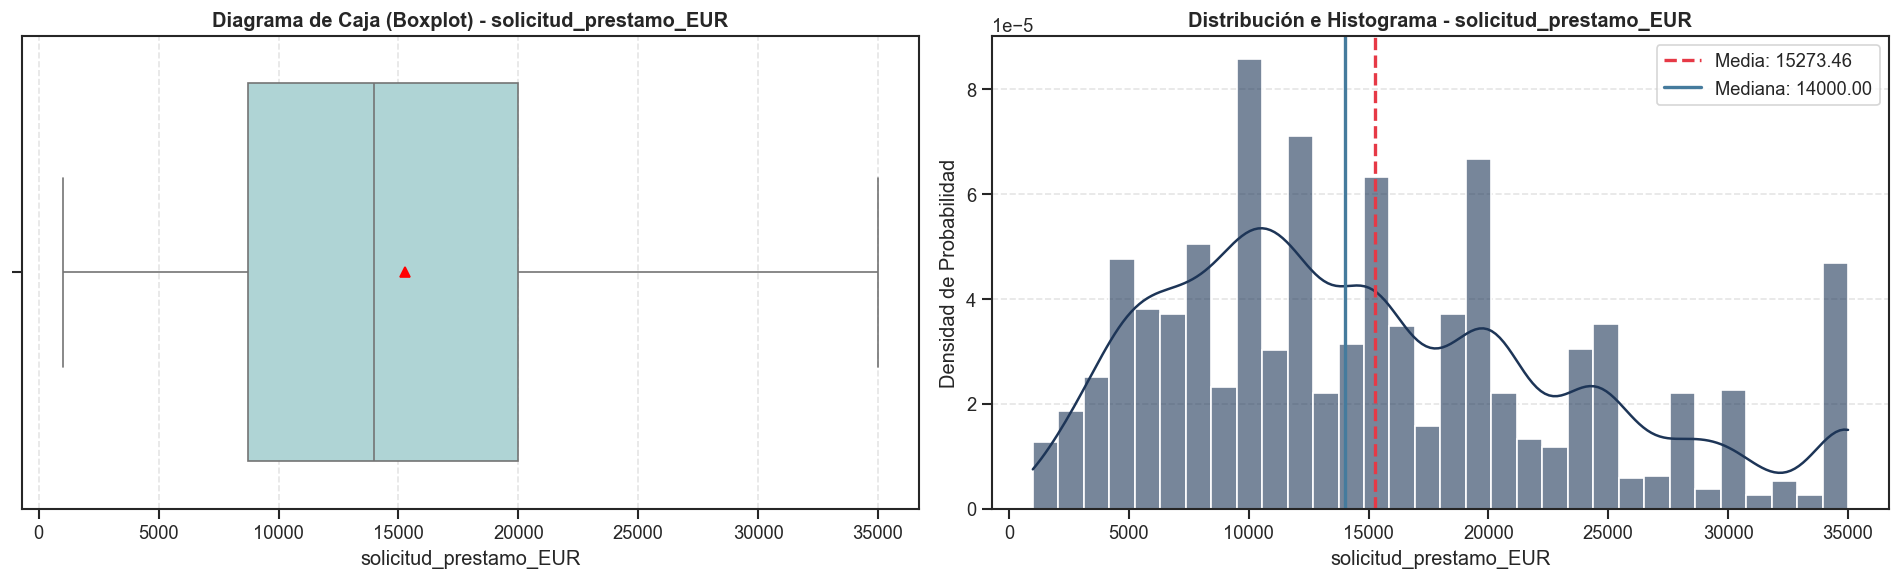

In [84]:
resumen = caracterizar_variable_numerica(
    datos=datos_pandas,
    variable=columnas_numericas[0]
)
resumen_variables.append(resumen)

---
---

##### 📌 Conclusiones de la variable: `solicitud_prestamo_EUR`

A partir de la caracterización estadística realizada, es posible derivar una serie de conclusiones relevantes sobre el comportamiento, la calidad y la estructura de la variable analizada.

---

🔹 1. Calidad de los datos

La variable presenta un **5% de valores ausentes**, lo cual indica un nivel de incompletitud relativamente bajo. 

- Este porcentaje sugiere que la información disponible es mayoritariamente confiable, aunque no despreciable desde el punto de vista analítico.

Dado este nivel de faltantes, es viable aplicar estrategias de imputación sin comprometer de forma significativa la representatividad de la variable. 

* Métodos simples como la mediana podrían ser suficientes en una primera aproximación. 

* La elección final del método de imputación dependerá del contexto de los datos y el estudio a desarrollar.

---

🔹 2. Estructura y diversidad de la variable

Se observa un total de **885 valores únicos**, lo que representa aproximadamente un **8.85% de cardinalidad relativa**. 

- Este resultado indica que la variable posee una **diversidad moderada**, compatible con su naturaleza cuantitativa.

No obstante, la baja proporción de valores únicos sugiere que la variable podría presentar cierto grado de agrupamiento en rangos específicos de valores de préstamo. 

* Consistente con estructuras típicas de productos financieros estandarizados.

---

🔹 3. Tendencia central y sesgo de la distribución

La media (15 273.46 EUR) es ligeramente superior a la mediana (14 000 EUR)

- Presencia de una **asimetría positiva** en la distribución.

Este comportamiento sugiere que existen algunos valores relativamente altos que están desplazando la media hacia la derecha, aunque sin generar una distorsión extrema del centro de la distribución. 

* En este caso, la mediana constituye una medida más robusta del valor típico de la variable.

---

🔹 4. Rango y valores extremos

La variable se encuentra acotada entre **1 000 EUR y 35 000 EUR**, sin presencia de valores negativos ni ceros. 

- Coherente con la naturaleza del fenómeno analizado (solicitudes de préstamo).

La ausencia de valores nulos estructurales en este sentido refuerza la consistencia del dominio de la variable y su interpretación financiera.

---

🔹 5. Dispersión y heterogeneidad

El **coeficiente de variación de 55.83%** indica una **dispersión alta o considerable**, lo cual evidencia una variabilidad importante entre los montos solicitados.

Este resultado implica que la variable no puede ser adecuadamente representada únicamente por su media, ya que existe una heterogeneidad significativa en los valores observados. 

* Sugiere la existencia de distintos perfiles de solicitantes con comportamientos financieros diferenciados.

---

🔹 6. Forma de la distribución

La distribución presenta una **asimetría positiva moderada (0.6290)**, lo que confirma la presencia de una cola hacia valores altos. 

- Comportamiento es típico en variables financieras, donde un subconjunto de usuarios solicita montos considerablemente mayores al promedio.

Por otro lado, la **curtosis negativa (-0.3606)** indica una distribución ligeramente platicúrtica, es decir, más achatada que una distribución normal, con menor concentración central y una dispersión más uniforme de los valores.

---

📊 7. Interpretación global

En conjunto, la variable `solicitud_prestamo_EUR` puede describirse como una variable:

- **Relativamente bien estructurada y completa**, con un nivel bajo de datos faltantes.
- **Altamente heterogénea**, con dispersión considerable.
- **Levemente asimétrica hacia valores altos**, lo que es consistente con la presencia de préstamos de mayor cuantía en una minoría de casos.
- **Sin valores anómalos extremos evidentes según la regla de Tukey**, lo que sugiere una distribución contenida dentro de rangos operativos razonables.

---

📌 Conclusión final

Desde una perspectiva analítica, esta variable es **altamente informativa para modelos predictivos**, pero requiere especial atención en la gestión de su alta variabilidad. 

La heterogeneidad observada sugiere que podría beneficiarse de transformaciones (por ejemplo, logarítmicas) o de segmentación previa, dependiendo del objetivo del análisis.

En general, se trata de una variable **consistente**, con **comportamiento típico** de variables financieras de demanda, donde predominan **distribuciones sesgadas y dispersas**, pero **sin anomalías estructurales críticas**.

---
---

#### **Variable: Aceptación Préstamo EUR**

Caracterización de variable: aceptacion_prestamo_EUR
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 889
  • Proporción de valores únicos: 8.89 %

🔹 Tendencia central
  • Media: 15311.0421
  • Mediana: 14000.0000

🔹 Valores extremos
  • Máximo valor: 35000.0000
  • Mínimo valor: 1000.0000
  • Cantidad ceros: 0
  • Cantidad negativos: 0

🔹 Medidas de Posición
  • Q1 (25%): 8800.0000
  • Q3 (75%): 20000.0000
  • Cantidad Outliers: 0

🔹 Medidas de Dispersión
  • Desviación estándar: 8531.9895
  • Coeficiente de Variación: 55.72 %
    Interpretación: Dispersión alta o considerable

🔹 Forma de la distribución
  • Asimetría (skewness): 0.6280
    Interpretación: Sesgo a la derecha (asimetría positiva)

  • Coeficiente curtosis: -0.3598
    Interpretación: Distribución de transición con tendencia platicúrtica (ligero achatamiento)

🎨 Generando gráficos informativos...


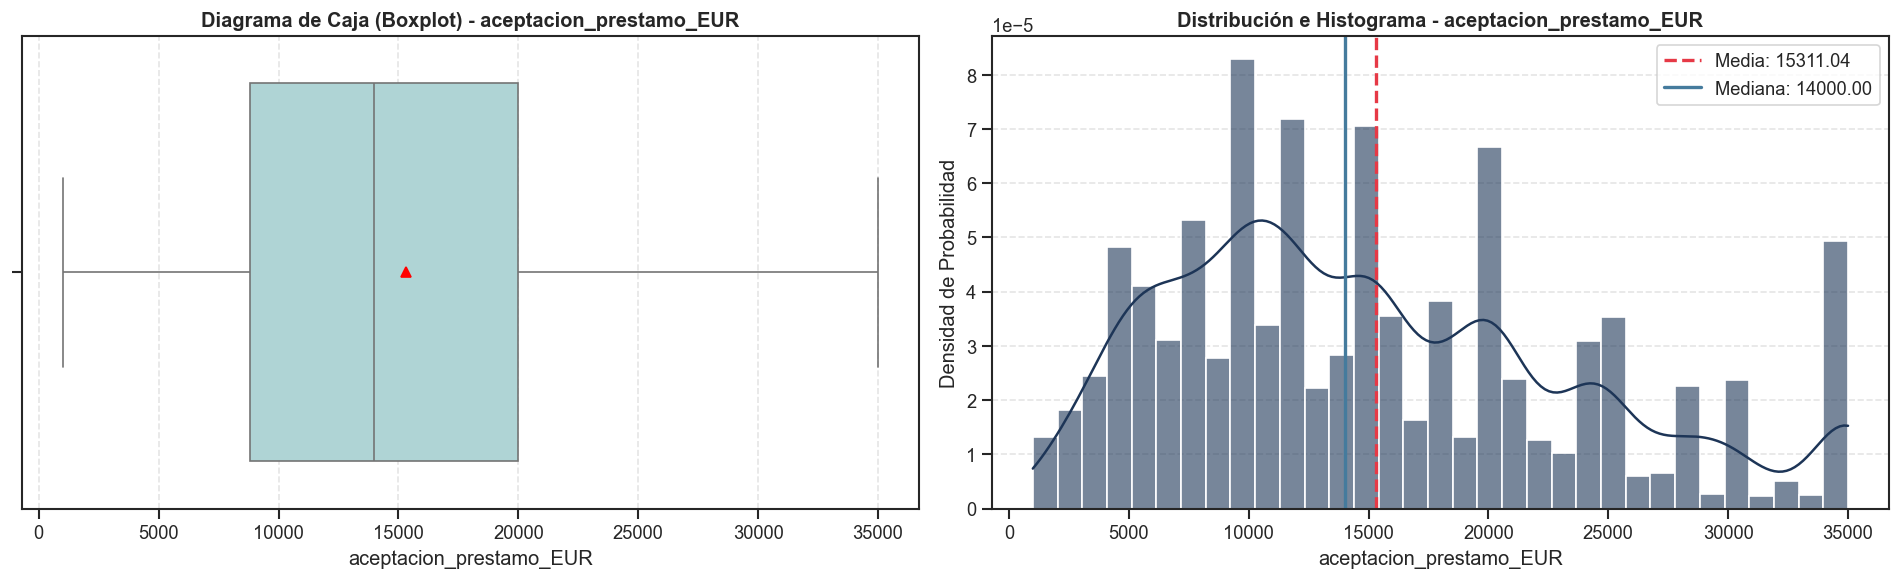

In [85]:
resumen = caracterizar_variable_numerica(
    datos=datos_pandas,
    variable=columnas_numericas[1]
)
resumen_variables.append(resumen)

---
---

##### 📌 Conclusiones de la variable: `solicitud_prestamo_EUR`

A partir de la caracterización estadística realizada, es posible derivar una serie de conclusiones relevantes sobre el comportamiento, la calidad y la estructura de la variable analizada.

---

🔹 1. Calidad de los datos

La variable presenta un **5% de valores ausentes**, lo cual indica un nivel de incompletitud relativamente bajo. 

- Este porcentaje sugiere que la información disponible es mayoritariamente confiable, aunque no despreciable desde el punto de vista analítico.

Dado este nivel de faltantes, es viable aplicar estrategias de imputación sin comprometer de forma significativa la representatividad de la variable. 

* Métodos simples como la mediana podrían ser suficientes en una primera aproximación. 

* La elección final del método de imputación dependerá del contexto de los datos y el estudio a desarrollar.

---

🔹 2. Estructura y diversidad de la variable

Se observa un total de **885 valores únicos**, lo que representa aproximadamente un **8.85% de cardinalidad relativa**. 

- Este resultado indica que la variable posee una **diversidad moderada**, compatible con su naturaleza cuantitativa.

No obstante, la baja proporción de valores únicos sugiere que la variable podría presentar cierto grado de agrupamiento en rangos específicos de valores de préstamo. 

* Consistente con estructuras típicas de productos financieros estandarizados.

---

🔹 3. Tendencia central y sesgo de la distribución

La media (15 273.46 EUR) es ligeramente superior a la mediana (14 000 EUR)

- Presencia de una **asimetría positiva** en la distribución.

Este comportamiento sugiere que existen algunos valores relativamente altos que están desplazando la media hacia la derecha, aunque sin generar una distorsión extrema del centro de la distribución. 

* En este caso, la mediana constituye una medida más robusta del valor típico de la variable.

---

🔹 4. Rango y valores extremos

La variable se encuentra acotada entre **1 000 EUR y 35 000 EUR**, sin presencia de valores negativos ni ceros. 

- Coherente con la naturaleza del fenómeno analizado (solicitudes de préstamo).

La ausencia de valores nulos estructurales en este sentido refuerza la consistencia del dominio de la variable y su interpretación financiera.

---

🔹 5. Dispersión y heterogeneidad

El **coeficiente de variación de 55.83%** indica una **dispersión alta o considerable**, lo cual evidencia una variabilidad importante entre los montos solicitados.

Este resultado implica que la variable no puede ser adecuadamente representada únicamente por su media, ya que existe una heterogeneidad significativa en los valores observados. 

* Sugiere la existencia de distintos perfiles de solicitantes con comportamientos financieros diferenciados.

---

🔹 6. Forma de la distribución

La distribución presenta una **asimetría positiva moderada (0.6290)**, lo que confirma la presencia de una cola hacia valores altos. 

- Comportamiento es típico en variables financieras, donde un subconjunto de usuarios solicita montos considerablemente mayores al promedio.

Por otro lado, la **curtosis negativa (-0.3606)** indica una distribución ligeramente platicúrtica, es decir, más achatada que una distribución normal, con menor concentración central y una dispersión más uniforme de los valores.

---

📊 7. Interpretación global

En conjunto, la variable `solicitud_prestamo_EUR` puede describirse como una variable:

- **Relativamente bien estructurada y completa**, con un nivel bajo de datos faltantes.
- **Altamente heterogénea**, con dispersión considerable.
- **Levemente asimétrica hacia valores altos**, lo que es consistente con la presencia de préstamos de mayor cuantía en una minoría de casos.
- **Sin valores anómalos extremos evidentes según la regla de Tukey**, lo que sugiere una distribución contenida dentro de rangos operativos razonables.

---

📌 Conclusión final

Desde una perspectiva analítica, esta variable es **altamente informativa para modelos predictivos**, pero requiere especial atención en la gestión de su alta variabilidad. 

La heterogeneidad observada sugiere que podría beneficiarse de transformaciones (por ejemplo, logarítmicas) o de segmentación previa, dependiendo del objetivo del análisis.

En general, se trata de una variable **consistente**, con **comportamiento típico** de variables financieras de demanda, donde predominan **distribuciones sesgadas y dispersas**, pero **sin anomalías estructurales críticas**.

---
---

#### **Variable: Razón Intereses**

Caracterización de variable: razon_intereses
🔹 Calidad de datos
  • Valores ausentes: 6004
  • Proporción de valores ausentes: 60.04 %

🔹 Diversidad de valores
  • Valores únicos: 59
  • Proporción de valores únicos: 0.59 %

🔹 Tendencia central
  • Media: 16.6173
  • Mediana: 16.2400

🔹 Valores extremos
  • Máximo valor: 28.9900
  • Mínimo valor: 6.0000
  • Cantidad ceros: 0
  • Cantidad negativos: 0

🔹 Medidas de Posición
  • Q1 (25%): 13.9900
  • Q3 (75%): 18.2500
  • Cantidad Outliers: 92
  • Proporción de Outliers: 0.92 %

🔹 Medidas de Dispersión
  • Desviación estándar: 2.9572
  • Coeficiente de Variación: 17.8 %
    Interpretación: Dispersión moderada

🔹 Forma de la distribución
  • Asimetría (skewness): 1.0691
    Interpretación: Sesgo a la derecha (asimetría positiva)

  • Coeficiente curtosis: 1.1088
    Interpretación: Distribución leptocúrtica (curva puntiaguda con colas pesadas)

🎨 Generando gráficos informativos...


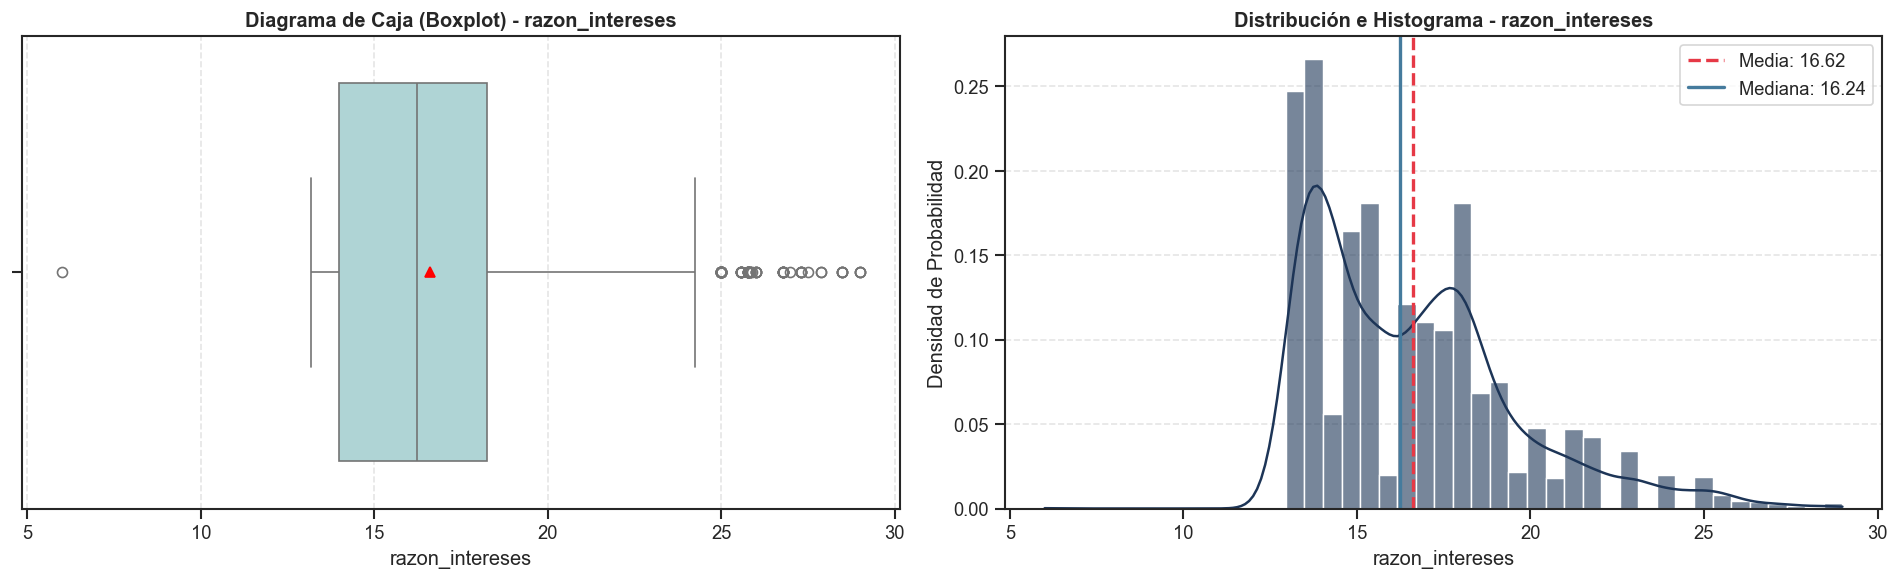

In [86]:
resumen = caracterizar_variable_numerica(
    datos=datos_pandas,
    variable=columnas_numericas[2]
)
resumen_variables.append(resumen)

---
---

##### 📌 Reporte Descriptivo: variable `razon_intereses`

El análisis estadístico y visual describe el comportamiento de las tasas o razones de interés aplicadas en el conjunto de datos. 

A grandes rasgos, la variable se caracteriza por presentar una **pérdida crítica de información (más de la mitad de los datos ausentes)**, una **dispersión moderada y homogénea**, un **sesgo marcado hacia valores altos** y la **presencia formal de anomalías estadísticamente significativas (*outliers*)** en ambos extremos de la distribución.

---

##### 1. Calidad y Diversidad de los Datos
* **Valores Faltantes:** Se detectaron **6,004 valores nulos**, lo que representa un alarmante **60.04%** del total de la muestra. 
  * *Significado práctico:* La variable se encuentra en un estado crítico. Una ausencia de datos tan severa invalida por completo cualquier intento de imputación simple (como usar la media o la mediana), ya que destruiría la distribución real. Se requiere una auditoría profunda para entender si el dato falta por un error de registro o si responde a una ausencia condicionada (ej. registros de clientes sin historial crediticio previo).
* **Diversidad:** Cuenta con **59 valores únicos** (**0.59%** de representatividad), lo que indica que a pesar de ser una escala continua, los intereses tienden a agruparse en tasas nominales o puntos porcentuales fijos y estandarizados por la institución.

---

##### 2. Tendencia Central y Forma (Sesgo)
* **Media aritmética:** 16.62 %
* **Mediana (Q2):** 16.24 %
* **Asimetría (Skewness):** 1.0691 $\rightarrow$ **Sesgo marcado a la derecha (asimetría positiva)**

**Interpretación analítica:** El coeficiente de asimetría supera la frontera crítica de 1.0, diagnosticando un sesgo fuerte y pronunciado. Aunque la mitad de las tasas se concentran por debajo del 16.24% (mediana), existe una "cola" muy extendida hacia la derecha conformada por tasas de interés considerablemente altas que arrastran de forma agresiva a la media aritmética hacia arriba.

---

##### 3. Medidas de Posición y Dispersión
* **Rango Operativo:** Desde un mínimo de **6.00 %** hasta un máximo de **28.99 %**.
* **Rango Intercuartílico (IQR):** **4.26 %**, el cual delimita la franja del 50% central del mercado:
  * **Percentil 25 (Q1):** 13.99 % $\rightarrow$ El 25% de los registros goza de tasas preferenciales o bajas, menores o iguales a este valor.
  * **Percentil 75 (Q3):** 18.25 % $\rightarrow$ El 75% de la población cuenta con tasas por debajo de esta cifra; el 25% restante asume las tasas más caras del portafolio.
* **Variabilidad Absoluta:** La varianza de $8.74$ equivale a una desviación estándar de **2.96 %**, confirmando que la mayoría de los intereses oscilan de forma estrecha alrededor de la media.
* **Variabilidad Relativa:** El **Coeficiente de Variación (CV)** se ubica en **17.80%** $\rightarrow$ **Dispersión moderada**. A diferencia de los montos de los préstamos, el comportamiento de las tasas es notablemente más estable, homogéneo y controlado internamente.

---

##### 4. Diagnóstico de Anomalías (Outliers)
Aplicando la Regla de Tukey con un factor de multiplicación de 1.5 sobre el IQR, se establecieron las siguientes fronteras estadísticas de normalidad:
* **Límite Inferior Teórico:** 7.60 %
* **Límite Superior Teórico:** 24.64 %

**Resultado del diagnóstico:** Se detectaron **92 valores atípicos (*outliers*)**, correspondientes al **0.92%** de la muestra total. 
  * *Interpretación analítica:* Dado que el valor mínimo registrado (**6.00%**) está por debajo del límite inferior (7.60%), existen clientes con tasas de interés excepcionalmente bajas (beneficios especiales o perfiles de riesgo mínimo). Del mismo modo, como el valor máximo (**28.99%**) supera la frontera superior (24.64%), se identifica un grupo que está pagando penalizaciones o tasas de usura fuera de la norma estadística. El gráfico de caja (*boxplot*) reflejará estos 92 registros como puntos aislados fuera de ambos bigotes.

---

##### 🔍 Conclusión Técnica para el EDA
Esta variable presenta un doble desafío para la ingeniería de características (*feature engineering*):
1. **Tratamiento de Nulos:** Con un 60.04% de NaN, la variable no puede usarse directamente en modelos de Machine Learning. Se sugiere evaluar la creación de una variable indicadora binaria (`tiene_razon_interes`: 0 o 1) o recurrir a una imputación avanzada basada en modelos predictivos (como *Random Forest Regressor*) correlacionando la tasa con el nivel de riesgo (`grade` / `sub_grade`).
2. **Mitigación de Outliers:** Al existir anomalías en ambos extremos y un skew superior a 1.0, los modelos lineales sufrirán grandes distorsiones. Si se decide rescatar la variable, será estrictamente necesario aplicar una **transformación matemática fuerte** (como el logaritmo natural) o un recorte de valores extremos mediante winsorización antes del entrenamiento.

---
---

#### **Variable: Pago Mensual**

Caracterización de variable: pago_mensual_EUR
🔹 Calidad de datos
  • Valores ausentes: 501
  • Proporción de valores ausentes: 5.01 %

🔹 Diversidad de valores
  • Valores únicos: 4337
  • Proporción de valores únicos: 43.37 %

🔹 Tendencia central
  • Media: 440.9222
  • Mediana: 385.3400

🔹 Valores extremos
  • Máximo valor: 1372.9700
  • Mínimo valor: 31.4200
  • Cantidad ceros: 0
  • Cantidad negativos: 0

🔹 Medidas de Posición
  • Q1 (25%): 267.2300
  • Q3 (75%): 576.0300
  • Cantidad Outliers: 260
  • Proporción de Outliers: 2.6 %

🔹 Medidas de Dispersión
  • Desviación estándar: 241.3556
  • Coeficiente de Variación: 54.74 %
    Interpretación: Dispersión alta o considerable

🔹 Forma de la distribución
  • Asimetría (skewness): 0.9391
    Interpretación: Sesgo a la derecha (asimetría positiva)

  • Coeficiente curtosis: 0.6728
    Interpretación: Distribución leptocúrtica (curva puntiaguda con colas pesadas)

🎨 Generando gráficos informativos...


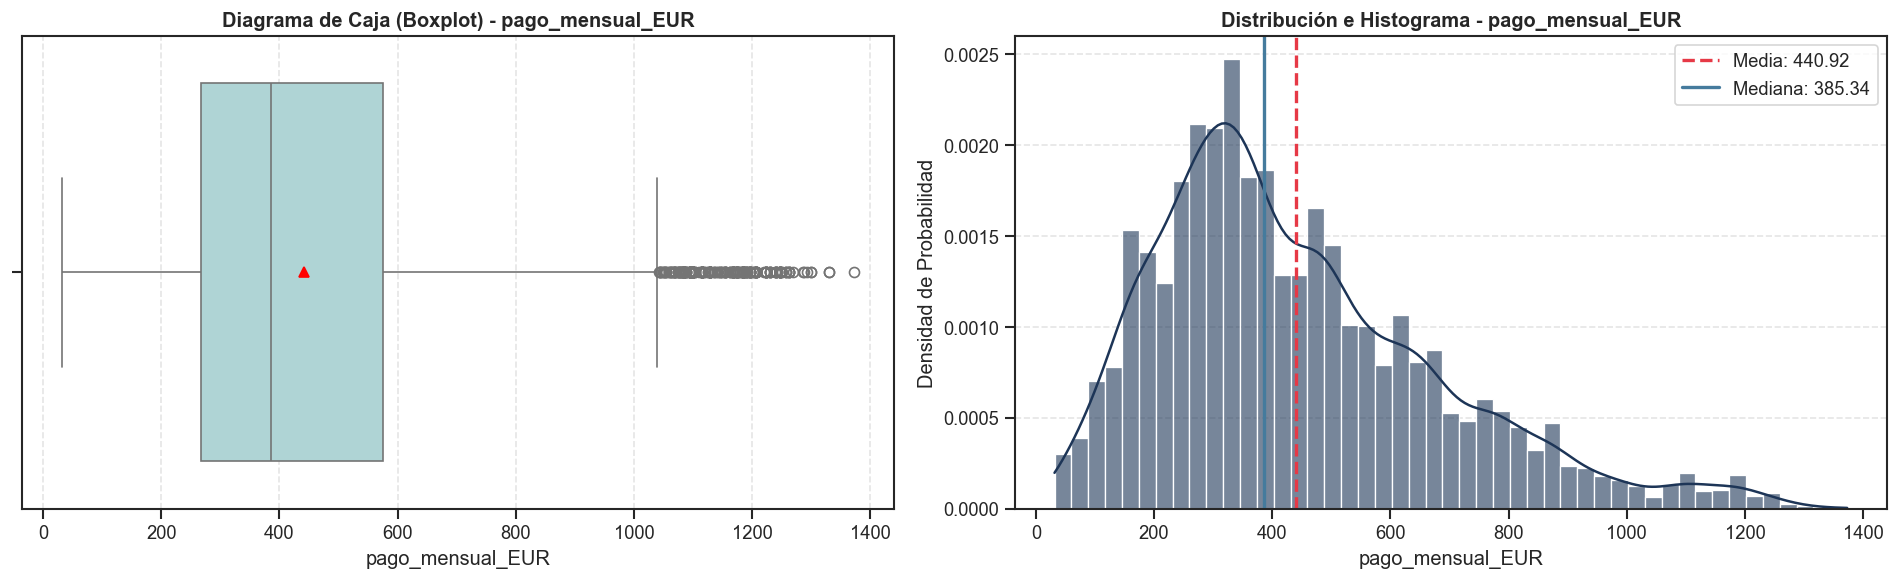

In [87]:
resumen = caracterizar_variable_numerica(
    datos=datos_pandas,
    variable=columnas_numericas[3]
)
resumen_variables.append(resumen)

---
---

##### 📌 Reporte Descriptivo: variable `pago_mensual_EUR`

El análisis estadístico y visual describe el comportamiento de las cuotas de pago mensual fijadas en euros para los préstamos del portafolio.

A grandes rasgos, la variable se caracteriza por una **dispersión alta y heterogénea**, un **sesgo positivo hacia cuotas elevadas**, una **fuerte concentración en torno a la zona media-baja (estructura leptocúrtica)** y la **presencia formal de valores atípicos (*outliers*)** concentrados exclusivamente en el extremo superior.

---

##### 1. Calidad y Diversidad de los Datos
* **Valores Faltantes:** Se detectaron **501 valores nulos**, lo que representa el **5.01%** del total de la muestra. Es un volumen bajo que sugiere una pérdida menor de información; se recomienda una imputación robusta por mediana antes de alimentar modelos predictivos.
* **Diversidad:** Cuenta con **4,337 valores únicos** (**43.37%** de representatividad), un indicador sumamente alto que confirma una granularidad fina y el comportamiento clásico de una variable cuantitativa continua altamente dinámica.

---

##### 2. Tendencia Central y Forma (Sesgo y Curtosis)
* **Media aritmética:** 440.92 EUR
* **Mediana (Q2):** 385.34 EUR
* **Asimetría (Skewness):** 0.9391 $\rightarrow$ **Sesgo a la derecha (asimetría positiva)**
* **Curtosis:** 0.9391 $\rightarrow$ **Distribución Leptocúrtica (curva puntiaguda con colas pesadas)**

**Interpretación analítica:** La media se encuentra notablemente desplazada por encima de la mediana, confirmando un sesgo positivo marcado. El histograma y la curva **KDE** reflejarán una acumulación masiva de registros en cuotas bajas y moderadas (cuyo punto máximo o "pico" destaca con fuerza debido a la estructura leptocúrtica), combinada con una "cola pesada" que se extiende hacia la derecha. Esto demuestra que la gran mayoría de los clientes pagan cuotas mensuales inferiores a los 400 EUR, pero un grupo selecto asume compromisos mensuales muy elevados que empujan el promedio general al alza.

---

##### 3. Medidas de Posición y Dispersión
* **Rango Operativo:** Desde una cuota mínima de **31.42 EUR** hasta un máximo de **1,372.97 EUR**.
* **Rango Intercuartílico (IQR):** **308.80 EUR**, el cual delimita la concentración del 50% central de los datos:
  * **Percentil 25 (Q1):** 267.23 EUR $\rightarrow$ El 25% de la población paga cuotas muy bajas, inferiores o iguales a esta cifra.
  * **Percentil 75 (Q3):** 576.03 EUR $\rightarrow$ El 75% de la población paga mensualidades por debajo de esta cifra.
* **Variabilidad Absoluta:** La varianza de $58,252.51$ equivale a una desviación estándar de **241.36 EUR**, reflejando que los pagos mensuales se apartan significativamente de la media.
* **Variabilidad Relativa:** El **Coeficiente de Variación (CV)** se sitúa en **54.74%** $\rightarrow$ **Dispersión alta o considerable**. Al igual que los montos solicitados, las cuotas mensuales presentan una estructura heterogénea que confirma perfiles financieros muy diversos dentro del mismo portafolio.

---

##### 4. Diagnóstico de Anomalías (Outliers)
Aplicando la Regla de Tukey con un factor de multiplicación de 1.5 sobre el IQR, se establecieron las siguientes fronteras estadísticas de control:
* **Límite Inferior Teórico:** -195.97 EUR (fijado operativamente en 31.42 EUR dado que no existen pagos negativos).
* **Límite Superior Teórico:** 1,039.23 EUR

**Resultado del diagnóstico:** Se detectaron **260 valores atípicos (*outliers*)**, que representan el **2.6%** de la muestra total.
  * *Interpretación analítica:* Dado que el valor máximo registrado (**1,372.97 EUR**) supera el umbral del límite superior (1,039.23 EUR), se identifica un segmento de clientes con obligaciones mensuales excepcionalmente agresivas. El gráfico de caja (*boxplot*) mostrará una densidad importante de puntos suspendidos en el extremo derecho, representando un nicho de alto valor (y potencialmente mayor riesgo de impago) que rompe con la pauta estadística general del portafolio.

---

##### 🔍 Conclusión Técnica para el EDA
Esta variable refleja de manera directa el impacto de los montos de préstamos grandes analizados previamente. Para el tratamiento de datos y preparación de modelos de Machine Learning, se derivan dos acciones clave:
1. **Mitigación del Sesgo y Anomalías:** Al presentar un skew cercano a 1.0 y un 2.6% de outliers superiores, los algoritmos basados en optimización por gradiente o distancias (como regresiones, SVM o redes neuronales) sufrirán distorsiones en sus fronteras de decisión. Es altamente recomendable aplicar una **transformación logarítmica (`np.log1p`)** para suavizar la cola pesada y estabilizar la curtosis.
2. **Imputación Coherente:** El 5.01% de registros nulos debe ser corregido mediante la **mediana** para proteger la distribución de la influencia de las cuotas extremas superiores.

---
---

#### **Variable: Pago Efectuado**

Caracterización de variable: pago_efectuado_EUR
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 8224
  • Proporción de valores únicos: 82.24 %

🔹 Tendencia central
  • Media: 3143.8509
  • Mediana: 1973.7050

🔹 Valores extremos
  • Máximo valor: 41913.6200
  • Mínimo valor: 0.0000
  • Cantidad ceros: 384
  • Proporción ceros: 3.84 %
  • Cantidad negativos: 0

🔹 Medidas de Posición
  • Q1 (25%): 889.5925
  • Q3 (75%): 3765.2500
  • Cantidad Outliers: 645
  • Proporción de Outliers: 6.45 %

🔹 Medidas de Dispersión
  • Desviación estándar: 4222.3518
  • Coeficiente de Variación: 134.31 %
    Interpretación: Dispersión alta o considerable

🔹 Forma de la distribución
  • Asimetría (skewness): 4.1208
    Interpretación: Sesgo a la derecha (asimetría positiva)

  • Coeficiente curtosis: 23.0955
    Interpretación: Distribución leptocúrtica (curva puntiaguda con colas pesadas)

🎨 Generando gráficos informativos

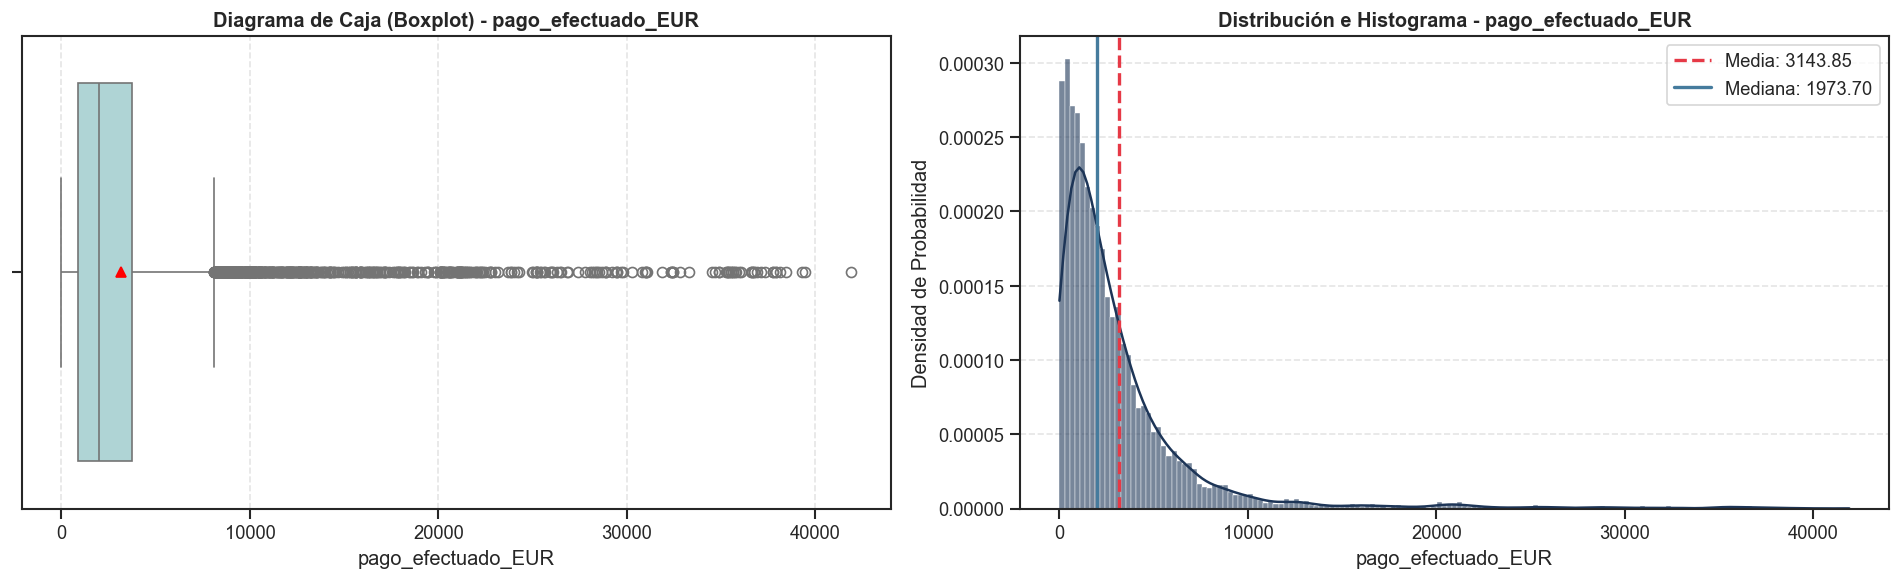

In [88]:
resumen = caracterizar_variable_numerica(
    datos=datos_pandas,
    variable=columnas_numericas[4]
)
resumen_variables.append(resumen)

---
---

##### 📌 Reporte Descriptivo: variable `pago_efectuado_EUR`

El análisis estadístico y visual describe el comportamiento de los montos totales ya pagados o efectuados en euros por los clientes del portafolio.

A grandes rasgos, la variable presenta una **dispersión masiva y críticamente heterogénea**, un **sesgo positivo severo y extremo**, una **concentración masiva en valores bajos con colas hiper-pesadas (leptocúrtica)** y una **presencia masiva de valores atípicos (*outliers*)** concentrados exclusivamente en la franja superior de la distribución.

---

##### 1. Calidad y Diversidad de los Datos
* **Valores Faltantes:** Se detectaron **500 valores nulos**, lo que representa el **5.0%** del total de la muestra. Es un volumen bajo y controlado; se recomienda una imputación por mediana para evitar que la severa deformación de la variable afecte el llenado de nulos.
* **Diversidad:** Cuenta con **8,224 valores únicos** (**82.24%** de representatividad), reflejando una granularidad e individualidad casi total en los registros, comportamiento clásico de montos acumulados dinámicamente a lo largo del tiempo.

---

##### 2. Tendencia Central y Forma (Sesgo y Curtosis)
* **Media aritmética:** 3,143.85 EUR
* **Mediana (Q2):** 1,973.71 EUR
* **Asimetría (Skewness):** 4.1208 $\rightarrow$ **Sesgo severo a la derecha (asimetría positiva extrema)**
* **Curtosis:** 4.1208 $\rightarrow$ **Distribución fuertemente Leptocúrtica (pico extremo con colas hiper-pesadas)**

**Interpretación analítica:** El coeficiente de asimetría rompe los umbrales estándar al superar el valor de 4.0. Físicamente, esto significa que la media está masivamente "arrastrada" hacia arriba por un grupo de registros con pagos acumulados gigantescos. La mediana de apenas 1,973.71 EUR nos dice que la mitad de la población ha efectuado pagos muy pequeños, pero la cola de la derecha se extiende de manera descomunal hasta superar los 41,000 EUR. Su naturaleza leptocúrtica extrema confirma que casi toda la población está confinada en la base inferior del gráfico, pero los pocos que escapan tienen valores exponencialmente altos.

---

##### 3. Medidas de Posición y Dispersión
* **Rango Operativo:** Desde un mínimo de **0.00 EUR** (usuarios que no han efectuado ningún pago) hasta un máximo histórico de **41,913.62 EUR**.
* **Rango Intercuartílico (IQR):** **2,875.66 EUR**, el cual delimita la concentración del 50% central de los datos:
  * **Percentil 25 (Q1):** 889.59 EUR $\rightarrow$ El 25% de la población ha efectuado pagos mínimos o muy iniciales por debajo de esta cifra.
  * **Percentil 75 (Q3):** 3,765.25 EUR $\rightarrow$ El 75% de la población mantiene pagos acumulados por debajo de este umbral.
* **Variabilidad Absoluta:** La varianza se dispara hasta los $17,828,254.33$, lo que equivale a una desviación estándar de **4,222.35 EUR**. Notablemente, ¡la desviación estándar es mucho mayor que la propia media!
* **Variabilidad Relativa:** El **Coeficiente de Variación (CV)** alcanza un alarmante **134.31%** $\rightarrow$ **Dispersión masiva y extrema**. Un $CV$ superior al 100% es el diagnóstico definitivo de una variable hiper-heterogénea, donde los datos varían de forma caótica entre sí y el concepto de "pago promedio" carece por completo de sentido operativo.

---

##### 4. Diagnóstico de Anomalías (Outliers)
Aplicando la Regla de Tukey con un factor de multiplicación de 1.5 sobre el IQR, se establecieron las siguientes fronteras estadísticas de control:
* **Límite Inferior Teórico:** -3,423.89 EUR (fijado operativamente en 0.00 EUR).
* **Límite Superior Teórico:** 8,078.74 EUR

**Resultado del diagnóstico:** Se detectaron **645 valores atípicos (*outliers*)**, que representan un masivo **6.45%** de la muestra total.
  * *Interpretación analítica:* Cualquier cliente que haya efectuado pagos superiores a los **8,078.74 EUR** rompe el patrón normal del portafolio. Dado que el máximo llega a más de 41k, estamos ante un volumen muy grande de anomalías superiores (645 registros). El diagrama de caja (*boxplot*) mostrará una línea de outliers densa, masiva y extremadamente larga que desfigurará la escala visual de la caja.

---

##### 🔍 Conclusión Técnica para el EDA
Esta variable se encuentra en un estado de deformación estadística crítico y **no puede ser utilizada de forma cruda** en casi ningún algoritmo de Machine Learning (especialmente en modelos lineales, de distancia o redes neuronales), ya que los 645 outliers y el skew de 4.12 monopolizarán las funciones de pérdida e invalidarán el aprendizaje.

**Acciones de Ingeniería de Características (Feature Engineering) Obligatorias:**
1. **Transformación Logarítmica Drástica:** Es estrictamente necesario aplicar una transformación de tipo `np.log1p(datos['pago_efectuado_EUR'])`. Esto comprimirá la escala de los valores extremos en el extremo derecho, reducirá el skew de >4 a rangos tolerables (<1) y transformará los outliers en registros manejables para la distribución.
2. **Segmentación:** Considerar la creación de una bandera binaria o categórica para aislar al segmento "High-Value" (> 8,078.74 EUR), ya que operativamente representan un comportamiento comercial completamente diferente al resto del portafolio.
3. **Imputación:** El 5% de nulos debe ser reemplazado única y exclusivamente por la **mediana**, ya que la media está severamente distorsionada por el sesgo.

---
---

#### **Variable: Meses Préstamo**

Caracterización de variable: meses_prestamo
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 2
  • Proporción de valores únicos: 0.02 %

🔹 Tendencia central
  • Media: 44.1322
  • Mediana: 36.0000

🔹 Valores extremos
  • Máximo valor: 60.0000
  • Mínimo valor: 36.0000
  • Cantidad ceros: 0
  • Cantidad negativos: 0

🔹 Medidas de Posición
  • Q1 (25%): 36.0000
  • Q3 (75%): 60.0000
  • Cantidad Outliers: 0

🔹 Medidas de Dispersión
  • Desviación estándar: 11.3602
  • Coeficiente de Variación: 25.74 %
    Interpretación: Dispersión moderada

🔹 Forma de la distribución
  • Asimetría (skewness): 0.6811
    Interpretación: Sesgo a la derecha (asimetría positiva)

  • Coeficiente curtosis: -1.5365
    Interpretación: Distribución platicúrtica (curva achatada o plana)

🎨 Generando gráficos informativos...


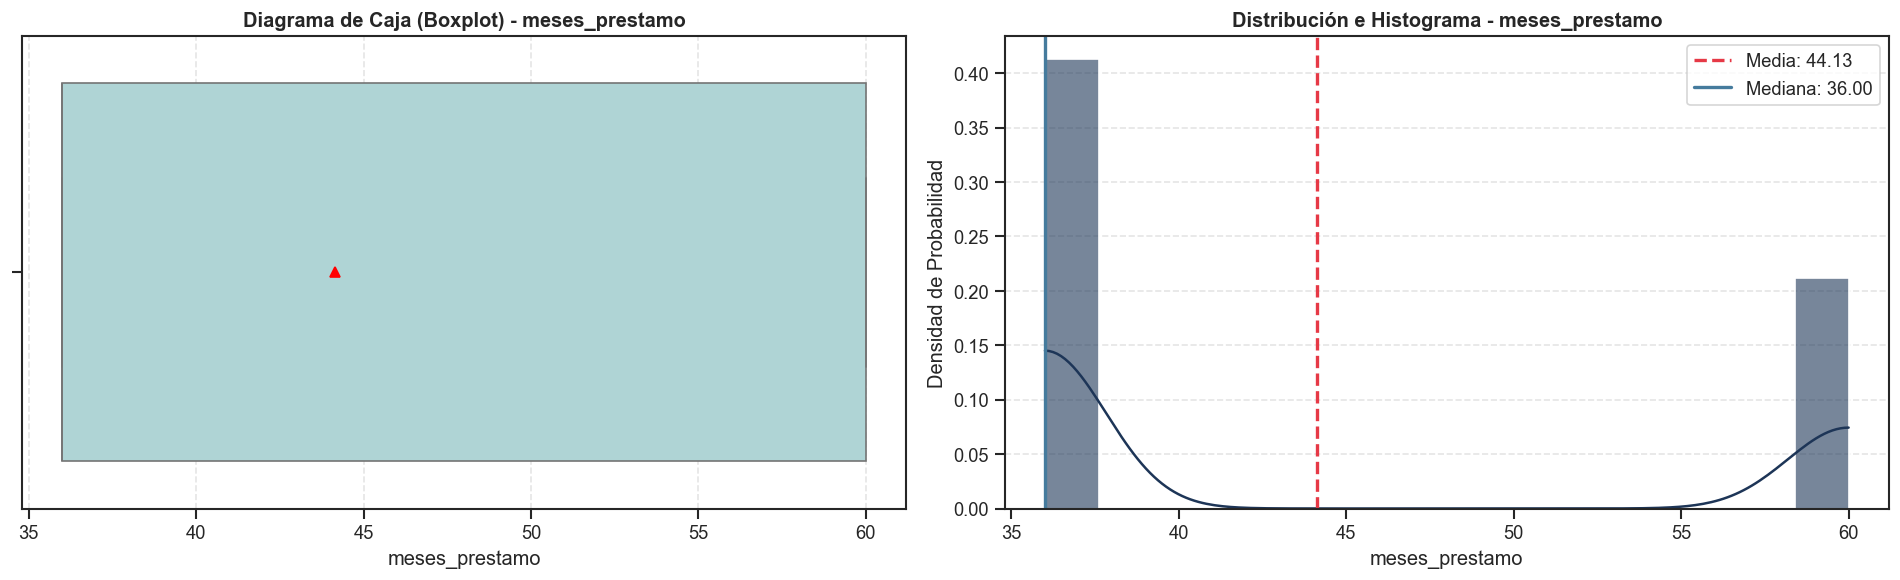

In [89]:
resumen = caracterizar_variable_numerica(
    datos=datos_pandas,
    variable=columnas_numericas[5]
)
resumen_variables.append(resumen)

---
---

##### 📌 Reporte Descriptivo: variable `meses_prestamo`

El análisis estadístico y visual describe el comportamiento de los plazos o duración de los créditos otorgados, expresados en meses.

A grandes rasgos, la variable se comporta como una **estructura discreta binaria de dos horizontes temporales**, presentando una **dispersión moderada**, un **sesgo hacia el plazo menor (36 meses)** y una **ausencia absoluta de valores atípicos (*outliers*)**.

---

##### 1. Calidad y Diversidad de los Datos
* **Valores Faltantes:** Se detectaron **500 valores nulos**, lo que representa el **5.0%** del total de la muestra. Es un volumen bajo y controlado; se recomienda una imputación por la moda o la mediana antes de alimentar modelos predictivos.
* **Diversidad:** Cuenta con únicamente **2 valores únicos** (**0.02%** de representatividad). 
  * *Significado práctico:* Este indicador es clave. Confirma que la variable no es continua, sino que el portafolio opera bajo dos únicos esquemas de financiamiento fijos (típicamente plazos estandarizados de 36 y 60 meses).

---

##### 2. Tendencia Central y Forma (Sesgo y Curtosis)
* **Media aritmética:** 44.13 meses
* **Mediana (Q2):** 36.00 meses
* **Asimetría (Skewness):** 0.6811 $\rightarrow$ **Sesgo a la derecha (asimetría positiva)**
* **Curtosis:** 0.6811 $\rightarrow$ **Distribución Platicúrtica (interpretada analíticamente como bimodal)**

**Interpretación analítica:** Dado que la variable solo toma los valores de 36 y 60, la media aritmética (44.13 meses) no representa un plazo real que un cliente pueda elegir, sino el centro de gravedad ponderado. Al estar la media más cerca de 36 que de 60, y coincidir la mediana exactamente en 36.00, se confirma el sesgo positivo. Esto nos dice matemáticamente que **el volumen de créditos a corto/mediano plazo (36 meses) es significativamente mayor** que el de largo plazo (60 meses). El histograma visualiza esto mediante dos barras aisladas donde la barra de los 36 meses es notablemente más alta.

---

##### 3. Medidas de Posición y Dispersión
* **Rango Operativo:** Delimitado estrictamente entre un mínimo de **36.00 meses** y un máximo de **60.00 meses**.
* **Rango Intercuartílico (IQR):** **24.00 meses**, la distancia exacta entre ambos extremos operativos:
  * **Percentil 25 (Q1):** 36.00 meses $\rightarrow$ Al menos el 25% (y de hecho, la mayoría de la población) se concentra en el límite inferior.
  * **Percentil 75 (Q3):** 60.00 meses $\rightarrow$ El tercer cuartil alcanza la frontera del plazo largo.
* **Variabilidad Absoluta:** La varianza de $129.05$ equivale a una desviación estándar de **11.36 meses**, cuantificando la oscilación promedio entre las dos únicas opciones disponibles.
* **Variabilidad Relativa:** El **Coeficiente de Variación (CV)** se ubica en **25.74%** $\rightarrow$ **Dispersión moderada**. La dispersión está acotada y controlada debido a la ausencia de un espectro continuo de valores o de plazos intermedios (como 12, 24 o 48 meses).

---

##### 4. Diagnóstico de Anomalías (Outliers)
Aplicando la Regla de Tukey con un factor de multiplicación de 1.5 sobre el IQR, se establecieron las siguientes fronteras teóricas de control:
* **Límite Inferior Teórico:** 0.00 meses
* **Límite Superior Teórico:** 96.00 meses

**Resultado del diagnóstico:** La **Cantidad de Outliers detectados es 0**. Dado que las dos únicas opciones existentes (36 y 60 meses) se encuentran perfectamente contenidas dentro de las fronteras teóricas de la regla de Tukey, no existe ningún registro anómalo. El gráfico de caja (*boxplot*) reflejará una estructura particular: una caja ensanchada que toca ambos extremos operativos, sin puntos suspendidos más allá de los límites.

---

##### 🔍 Conclusión Técnica para el EDA
El diagnóstico analítico de `meses_prestamo` altera la estrategia de preparación de datos en comparación con el resto de las variables numéricas:
1. **Naturaleza de la Variable:** A pesar de estar codificada numéricamente, su baja cardinalidad (2 valores únicos) sugiere que para ciertos modelos (como árboles de decisión o ensamblados) puede tratarse directamente como una **variable categórica binaria u ordinal**. 
2. **Imputación:** El 5.0% de registros nulos debe ser reemplazado por la **mediana (36.00)** o la moda, lo cual garantiza que el valor imputado sea una opción de plazo real y válida para el negocio.
3. **Modelado:** Al no poseer outliers ni un comportamiento continuo real, esta variable no requiere de transformaciones matemáticas de escala (como logaritmos o estandarizaciones), quedando lista para actuar como una excelente característica de segmentación temporal.

---
---

#### **Resumen Variables Numéricas**

In [90]:
resumen_numerico_pandas = pd.DataFrame(resumen_variables)
resumen_numerico_pandas.set_index("variable", inplace=True)

resumen_numerico_pandas.to_csv('metricas_variables_numericas.csv')
resumen_numerico_pandas.head()

,cantidad_datos,cantidad_ausentes,proporcion_ausentes,cantidad_unicos,proporcion_unicos,promedio,mediana,maximo,minimo,cantidad_ceros,...,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers,proporcion_outliers,desviacion_estandar,coeficiente_variacion,curtosis,skew
variable,,,,,,,,,,,,,,,,,,,,,
solicitud_prestamo_EUR,10000,500,5.00,885,8.85,15273.463158,14000.000,35000.00,1000.00,0,...,20000.00,11256.2500,-8140.62500,36884.37500,0,0.00,8527.234720,55.83,-0.360647,0.628988
aceptacion_prestamo_EUR,10000,500,5.00,889,8.89,15311.042105,14000.000,35000.00,1000.00,0,...,20000.00,11200.0000,-8000.00000,36800.00000,0,0.00,8531.989496,55.72,-0.359761,0.627985
razon_intereses,10000,6004,60.04,59,0.59,16.617295,16.240,28.99,6.00,0,...,18.25,4.2600,7.60000,24.64000,92,0.92,2.957174,17.80,1.108830,1.069081
pago_mensual_EUR,10000,501,5.01,4337,43.37,440.922179,385.340,1372.97,31.42,0,...,576.03,308.8000,-195.97000,1039.23000,260,2.60,241.355569,54.74,0.672841,0.939075
pago_efectuado_EUR,10000,500,5.00,8224,82.24,3143.850941,1973.705,41913.62,0.00,384,...,3765.25,2875.6575,-3423.89375,8078.73625,645,6.45,4222.351754,134.31,23.095543,4.120772


___
___



### Análisis Individual de Variables Categóricas

In [91]:
resumen_categorias = []
datos_pandas[columnas_no_numericas].head()

,identificador,fecha_prestamo,estado_prestamo,grado,sub_grado,estado_verificacion,estado
0,48010226,1-05-15,Current,C,C3,Verified,CA
1,57693261,NaT,Current,A,A5,Source Verified,NY
2,59432726,1-09-15,Current,B,B5,Verified,PA
3,53222800,1-07-15,Current,A,A5,Not Verified,OH
4,57803010,1-08-15,Current,NaN,E3,Source Verified,TX


#### **Variable: Fecha Préstamo**

In [92]:
datos_pandas_modificado = pd.DataFrame()
datos_pandas_modificado[columnas_no_numericas[1]] = datos_pandas[columnas_no_numericas[1]].dt.strftime('%b')
datos_pandas_modificado.head()

,fecha_prestamo
0,May
1,NaN
2,Sep
3,Jul
4,Aug


Caracterización de variable: fecha_prestamo
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 12
  • Proporción de valores únicos: 0.12 %
  • Entropía de Shannon (normalizada): 0.9899
  • Número efectivo de categorías: 11.70

🔹 Medidas de Concentración y Dominancia
  • Moda: Oct
  • Antimodal: Feb
  • Frecuencia de la Moda: 1095.0000
  • Proporción de la máxima frecuencia: 10.95 %
  • Frecuencia del Antimodal: 530.0000
  • Proporción de la mínima frecuencia: 5.3 %
  • Índice de dominancia extrema: 2.07
  • Índice de dominancia global: 0.12

🔹 Balance de las categorías
  • Coeficiente de variación de las frecuencias: 23.5 %
     - Existe cierto desbalance entre categorías, aunque ninguna domina claramente.
  • Índice de Simpson: 0.0876
  • Mínimo Teórico del Índice de Simpson: 0.0833
  • Índice Normalizado de Simpson: 0.4691 %
  • Coeficiente de uniformidad: 0.9752
     - Distribución muy uniforme

🔹 Categ

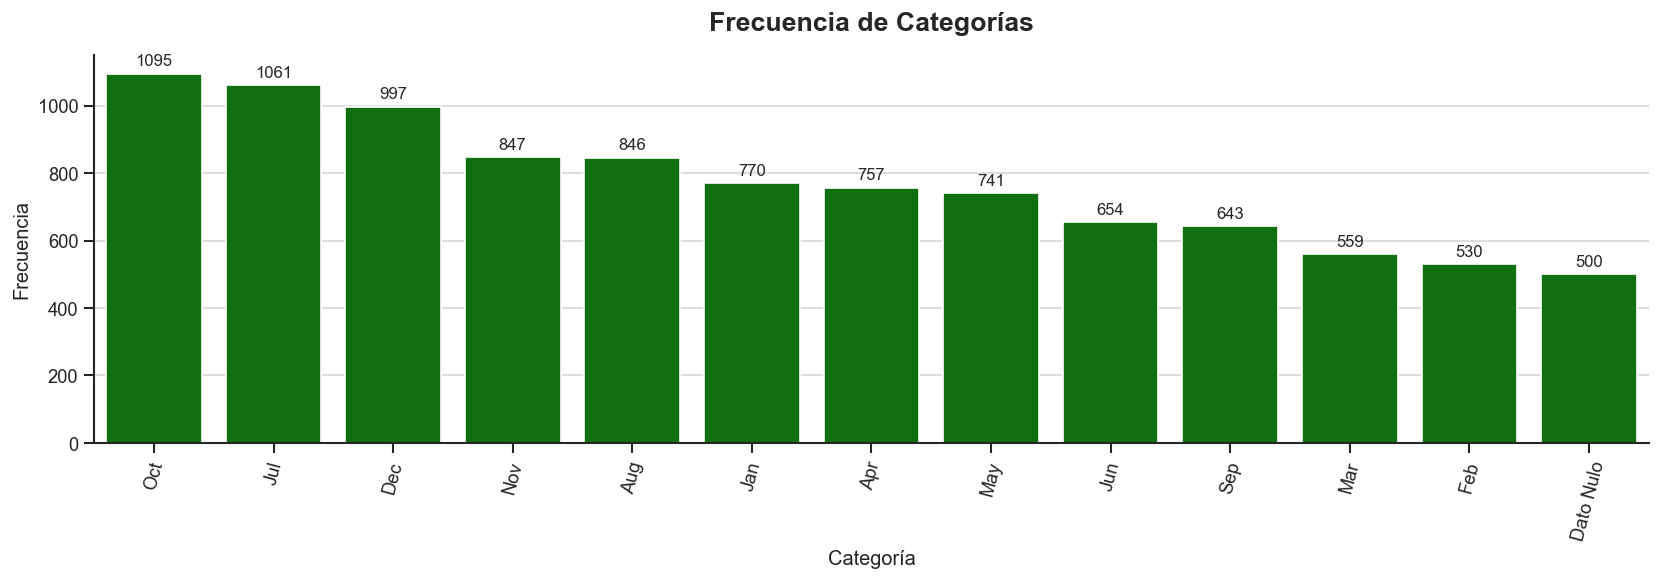

In [291]:
resumen = caracterizar_variable_no_numerica(
    datos=datos_pandas_modificado,
    variable=columnas_no_numericas[1]
)
resumen_categorias.append(resumen)

#### **Variable: Estado Préstamo**

Caracterización de variable: estado_prestamo
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 8
  • Proporción de valores únicos: 0.08 %
  • Entropía de Shannon (normalizada): 0.2262
  • Número efectivo de categorías: 1.60

🔹 Medidas de Concentración y Dominancia
  • Moda: Current
  • Antimodal: Default
  • Frecuencia de la Moda: 8538.0000
  • Proporción de la máxima frecuencia: 85.38 %
  • Frecuencia del Antimodal: 11.0000
  • Proporción de la mínima frecuencia: 0.11 %
  • Índice de dominancia extrema: 776.18
  • Índice de dominancia global: 5.84

🔹 Balance de las categorías
  • Coeficiente de variación de las frecuencias: 250.47 %
     - La distribución presenta un desbalance importante y una o pocas categorías concentran la mayor parte de las observaciones
  • Índice de Simpson: 0.8112
  • Mínimo Teórico del Índice de Simpson: 0.125
  • Índice Normalizado de Simpson: 78.4229 %
  • Coeficiente de unifo

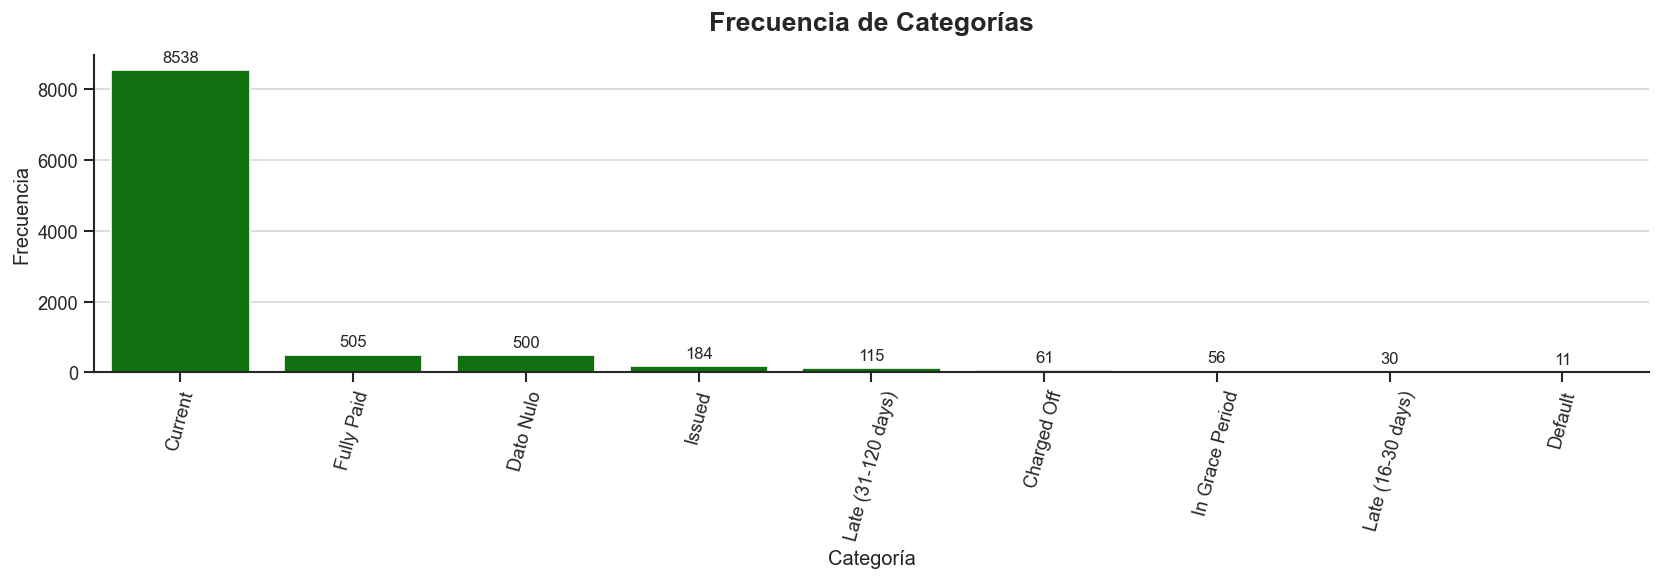

In [292]:
resumen = caracterizar_variable_no_numerica(
    datos=datos_pandas,
    variable=columnas_no_numericas[2]
)
resumen_categorias.append(resumen)

#### **Variable: Grado**

Caracterización de variable: grado
🔹 Calidad de datos
  • Valores ausentes: 515
  • Proporción de valores ausentes: 5.15 %

🔹 Diversidad de valores
  • Valores únicos: 7
  • Proporción de valores únicos: 0.07 %
  • Entropía de Shannon (normalizada): 0.8348
  • Número efectivo de categorías: 5.08

🔹 Medidas de Concentración y Dominancia
  • Moda: C
  • Antimodal: G
  • Frecuencia de la Moda: 2766.0000
  • Proporción de la máxima frecuencia: 27.66 %
  • Frecuencia del Antimodal: 40.0000
  • Proporción de la mínima frecuencia: 0.4 %
  • Índice de dominancia extrema: 69.15
  • Índice de dominancia global: 0.38

🔹 Balance de las categorías
  • Coeficiente de variación de las frecuencias: 79.18 %
     - La distribución presenta un desbalance importante y una o pocas categorías concentran la mayor parte de las observaciones
  • Índice de Simpson: 0.2196
  • Mínimo Teórico del Índice de Simpson: 0.1429
  • Índice Normalizado de Simpson: 8.9488 %
  • Coeficiente de uniformidad: 0.7251
     - Bu

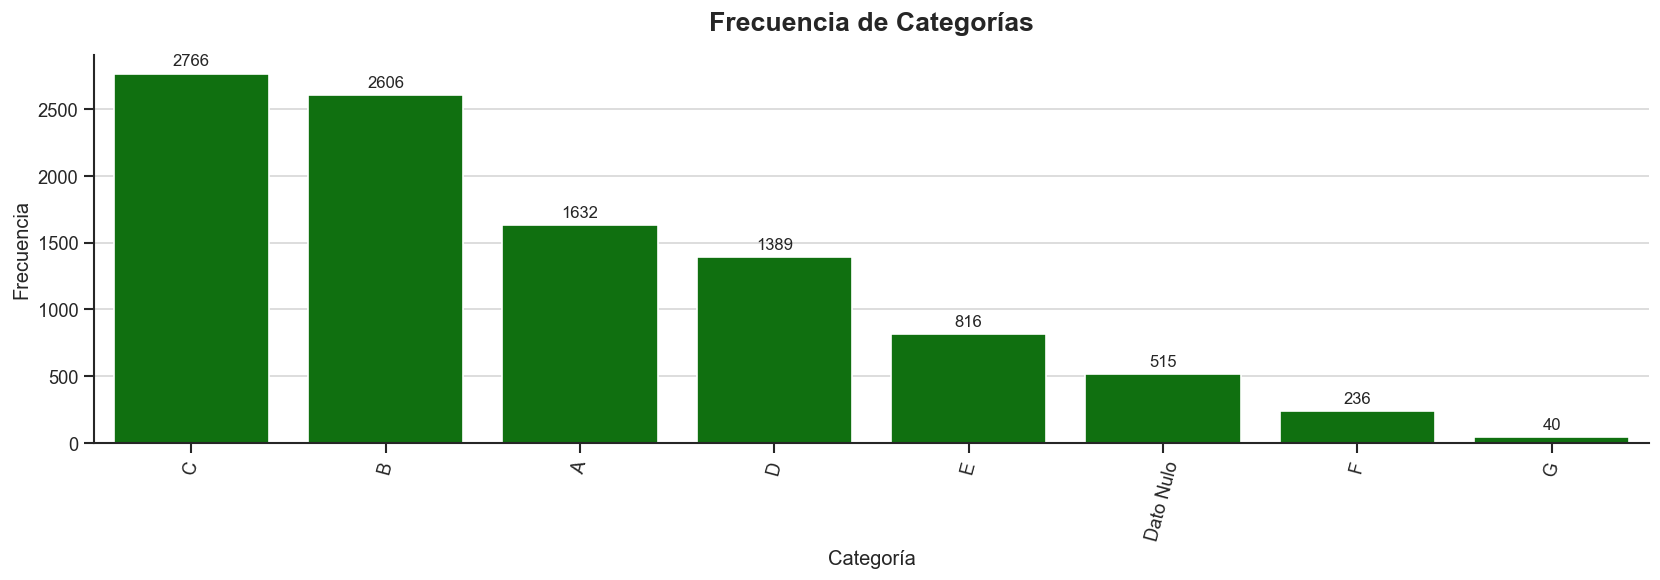

In [293]:
resumen = caracterizar_variable_no_numerica(
    datos=datos_pandas,
    variable=columnas_no_numericas[3]
)
resumen_categorias.append(resumen)

#### **Variable: Sub-Grado**

Caracterización de variable: sub_grado
🔹 Calidad de datos
  • Valores ausentes: 514
  • Proporción de valores ausentes: 5.14 %

🔹 Diversidad de valores
  • Valores únicos: 35
  • Proporción de valores únicos: 0.35 %
  • Entropía de Shannon (normalizada): 0.9045
  • Número efectivo de categorías: 24.93

🔹 Medidas de Concentración y Dominancia
  • Moda: C1
  • Antimodal: G5
  • Frecuencia de la Moda: 629.0000
  • Proporción de la máxima frecuencia: 6.29 %
  • Frecuencia del Antimodal: 2.0000
  • Proporción de la mínima frecuencia: 0.02 %
  • Índice de dominancia extrema: 314.5
  • Índice de dominancia global: 0.07

🔹 Balance de las categorías
  • Coeficiente de variación de las frecuencias: 76.86 %
     - La distribución presenta un desbalance importante y una o pocas categorías concentran la mayor parte de las observaciones
  • Índice de Simpson: 0.045
  • Mínimo Teórico del Índice de Simpson: 0.0286
  • Índice Normalizado de Simpson: 1.6883 %
  • Coeficiente de uniformidad: 0.7122
    

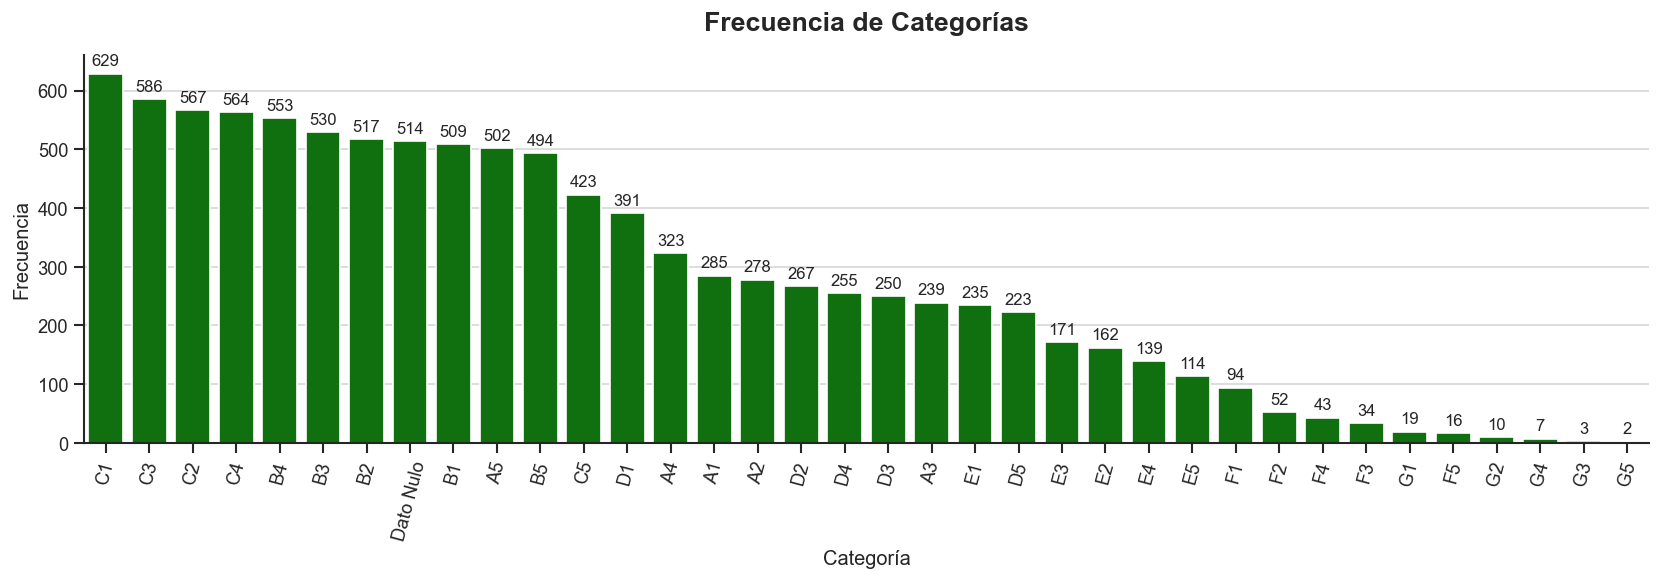

In [294]:
resumen = caracterizar_variable_no_numerica(
    datos=datos_pandas,
    variable=columnas_no_numericas[4]
)
resumen_categorias.append(resumen)

#### **Variable: Estado Verificación**

Caracterización de variable: estado_verificacion
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 3
  • Proporción de valores únicos: 0.03 %
  • Entropía de Shannon (normalizada): 0.9804
  • Número efectivo de categorías: 2.94

🔹 Medidas de Concentración y Dominancia
  • Moda: Source Verified
  • Antimodal: Not Verified
  • Frecuencia de la Moda: 4116.0000
  • Proporción de la máxima frecuencia: 41.16 %
  • Frecuencia del Antimodal: 2673.0000
  • Proporción de la mínima frecuencia: 26.73 %
  • Índice de dominancia extrema: 1.54
  • Índice de dominancia global: 0.7

🔹 Balance de las categorías
  • Coeficiente de variación de las frecuencias: 25.97 %
     - Existe cierto desbalance entre categorías, aunque ninguna domina claramente.
  • Índice de Simpson: 0.3483
  • Mínimo Teórico del Índice de Simpson: 0.3333
  • Índice Normalizado de Simpson: 2.2499 %
  • Coeficiente de uniformidad: 0.9786
     - Distrib

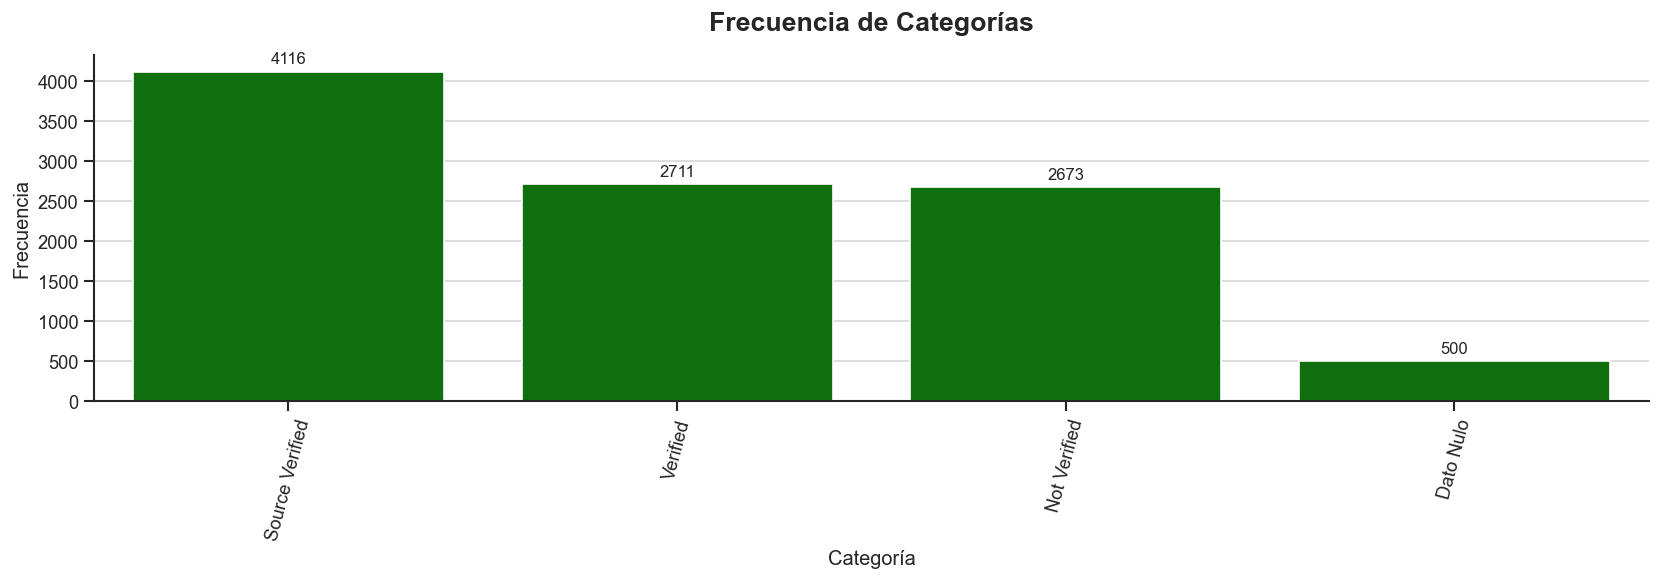

In [295]:
resumen = caracterizar_variable_no_numerica(
    datos=datos_pandas,
    variable=columnas_no_numericas[5]
)
resumen_categorias.append(resumen)

#### **Variable: Estado**

Caracterización de variable: estado
🔹 Calidad de datos
  • Valores ausentes: 500
  • Proporción de valores ausentes: 5.0 %

🔹 Diversidad de valores
  • Valores únicos: 49
  • Proporción de valores únicos: 0.49 %
  • Entropía de Shannon (normalizada): 0.8631
  • Número efectivo de categorías: 28.77

🔹 Medidas de Concentración y Dominancia
  • Moda: CA
  • Antimodal: ME
  • Frecuencia de la Moda: 1336.0000
  • Proporción de la máxima frecuencia: 13.36 %
  • Frecuencia del Antimodal: 10.0000
  • Proporción de la mínima frecuencia: 0.1 %
  • Índice de dominancia extrema: 133.6
  • Índice de dominancia global: 0.15

🔹 Balance de las categorías
  • Coeficiente de variación de las frecuencias: 125.72 %
     - La distribución presenta un desbalance importante y una o pocas categorías concentran la mayor parte de las observaciones
  • Índice de Simpson: 0.052
  • Mínimo Teórico del Índice de Simpson: 0.0204
  • Índice Normalizado de Simpson: 3.2258 %
  • Coeficiente de uniformidad: 0.5871
     

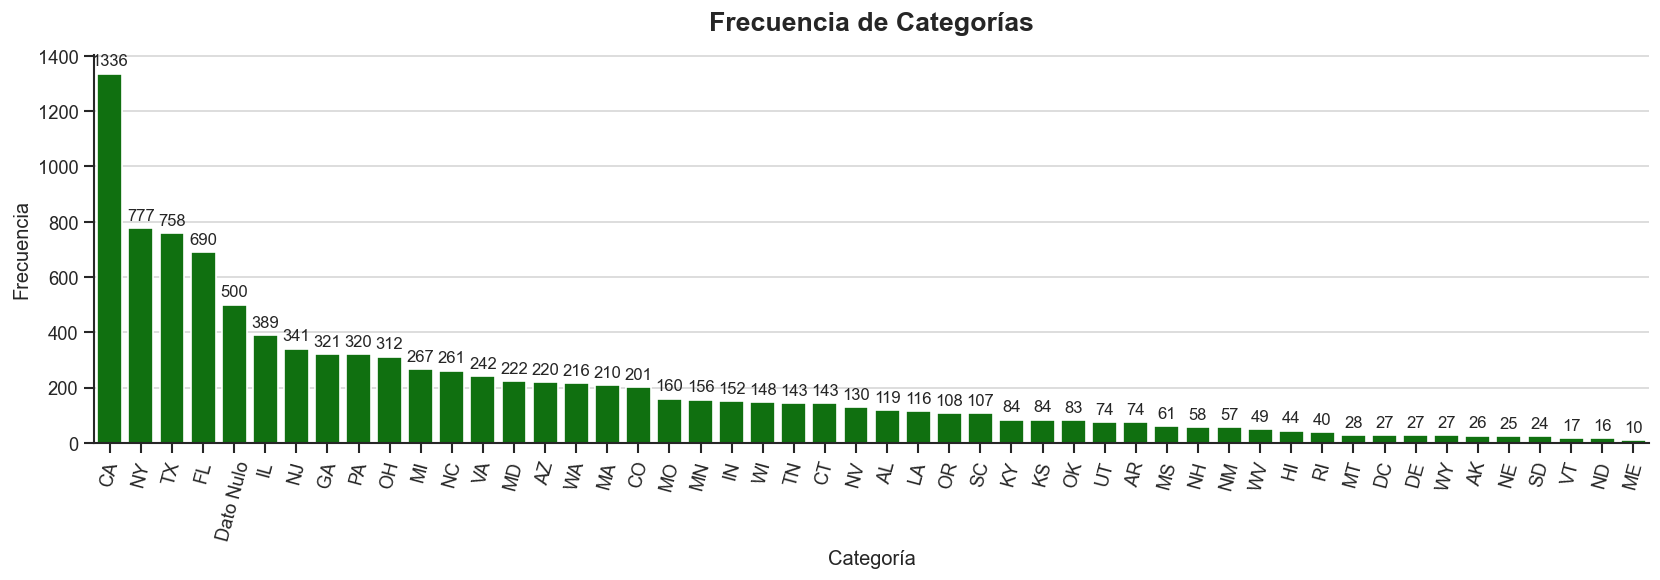

In [296]:
resumen = caracterizar_variable_no_numerica(
    datos=datos_pandas,
    variable=columnas_no_numericas[6]
)
resumen_categorias.append(resumen)

#### **Resumen de Variables Categóricas**

In [ ]:
resumen_categorias_pandas = pd.DataFrame(resumen_variables)
resumen_categorias_pandas.set_index("variable", inplace=True)

resumen_categorias_pandas.to_csv('metricas_variables_numericas.csv')
resumen_categorias_pandas.head()

## Proceso de Imputación
___
___

### Análisis Multivariable

####  **Métricas de Validez de Datos**

### **Observaciones por Variables**

Existen diversas relaciones que pueden establecerse entre los valores contenidos en las variables que conforman la base de datos proporcionada:

* Se analiza la posible correlación entre las variables `loan_amnt` y `funded_amnt`, con el objetivo de evaluar la viabilidad de un proceso de imputación de valores ausentes en ambas columnas, en caso de existir una relación estadísticamente significativa entre ellas.

* Se identifica una relación directa entre la codificación de las variables `sub_grade` y `grade`, lo que permite considerar la posibilidad de realizar procesos de imputación cruzada en aquellos casos en los que se presenten valores faltantes en alguna de estas variables, aprovechando su correspondencia estructural.